데이터 적재 시작...
  - 처리 중: Case 1, 4hr 균열 시점 (Time = 47860.0)
  - 처리 중: Case 1, 균열 완료 시점 (Time = 57382.5)
  - 건너뛰기: Case 2, 4hr 균열 시점 (Time = 47860)
  - 처리 중: Case 2, 균열 완료 시점 (Time = 75382.5)
  - 처리 중: Case 3, 4hr 균열 시점 (Time = 47860.0)
  - 처리 중: Case 3, 균열 완료 시점 (Time = 57382.5)
  - 처리 중: Case 4, 4hr 균열 시점 (Time = 47860.0)
  - 처리 중: Case 4, 균열 완료 시점 (Time = 57382.5)
  - 건너뛰기: Case 5, 4hr 균열 시점 (Time = 47860)
  - 처리 중: Case 5, 균열 완료 시점 (Time = 75382.5)
  - 처리 중: Case 6, 4hr 균열 시점 (Time = 47860.0)
  - 처리 중: Case 6, 균열 완료 시점 (Time = 57382.5)
  - 건너뛰기: Case 7, 4hr 균열 시점 (Time = 47860)
  - 처리 중: Case 7, 균열 완료 시점 (Time = 75382.5)
  - 처리 중: Case 8, 4hr 균열 시점 (Time = 47860.0)
  - 처리 중: Case 8, 균열 완료 시점 (Time = 57382.5)
  - 처리 중: Case 9, 4hr 균열 시점 (Time = 47860.0)
  - 처리 중: Case 9, 균열 완료 시점 (Time = 57382.5)
  - 건너뛰기: Case 10, 4hr 균열 시점 (Time = 47860)
  - 처리 중: Case 10, 균열 완료 시점 (Time = 75382.5)
데이터 적재 완료.

[그래프 생성] Case 1, 4hr 균열 시점


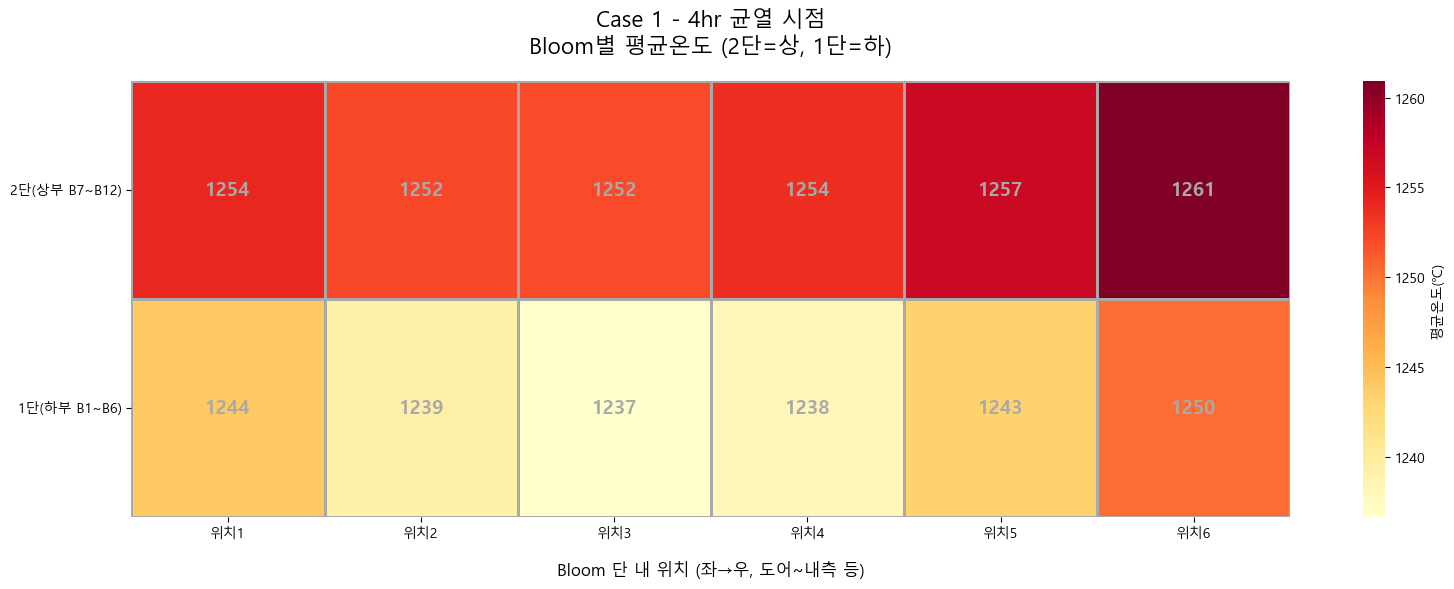

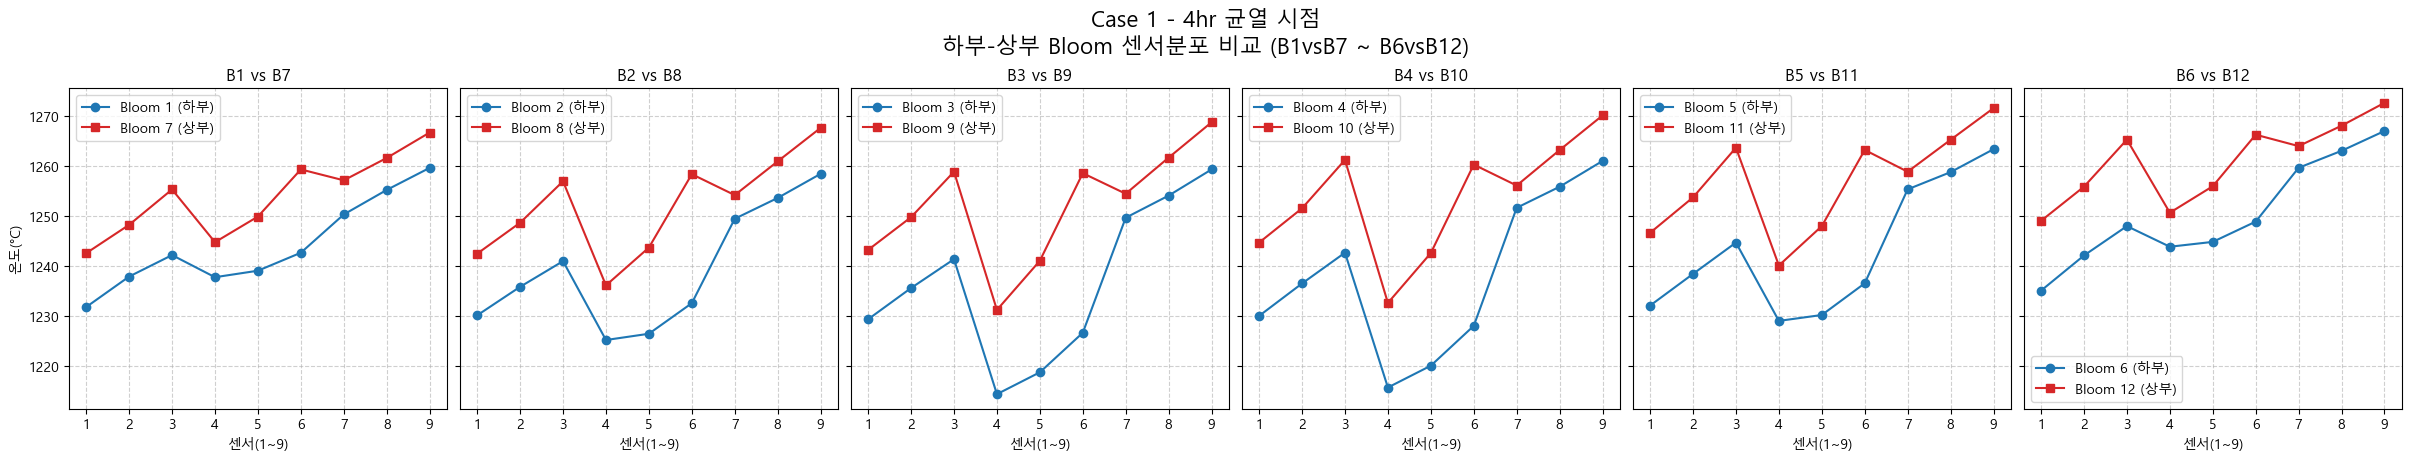


[그래프 생성] Case 1, 균열 완료 시점


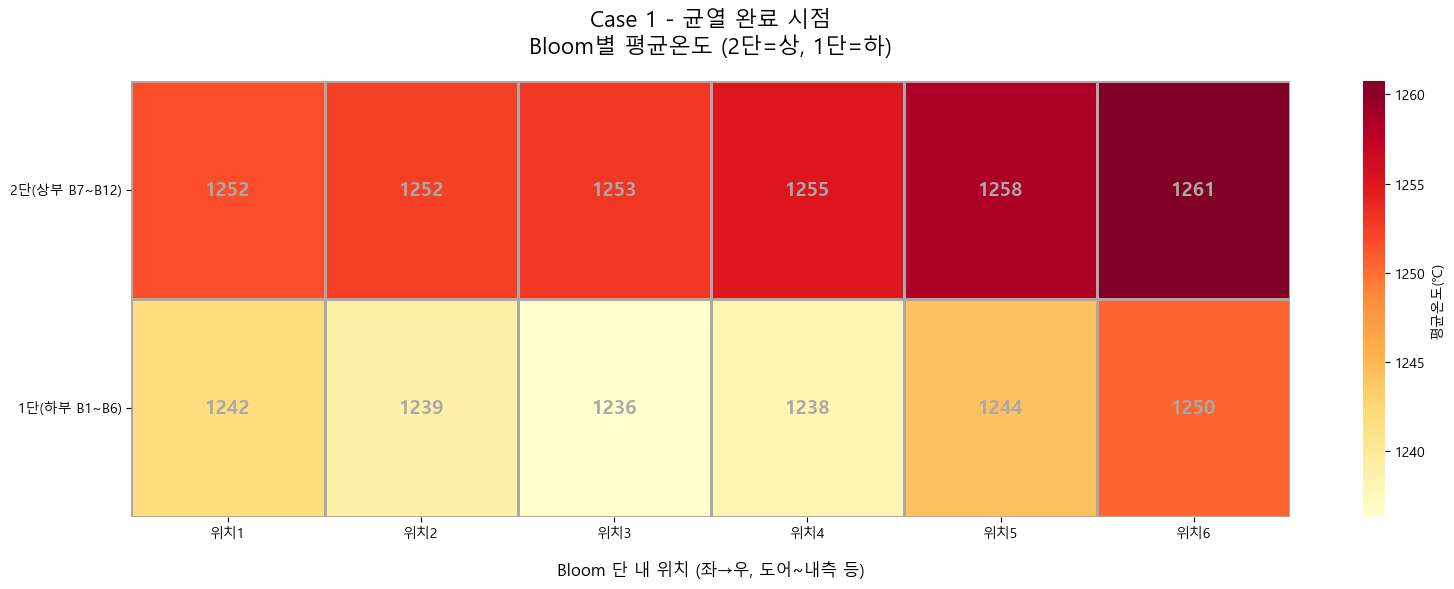

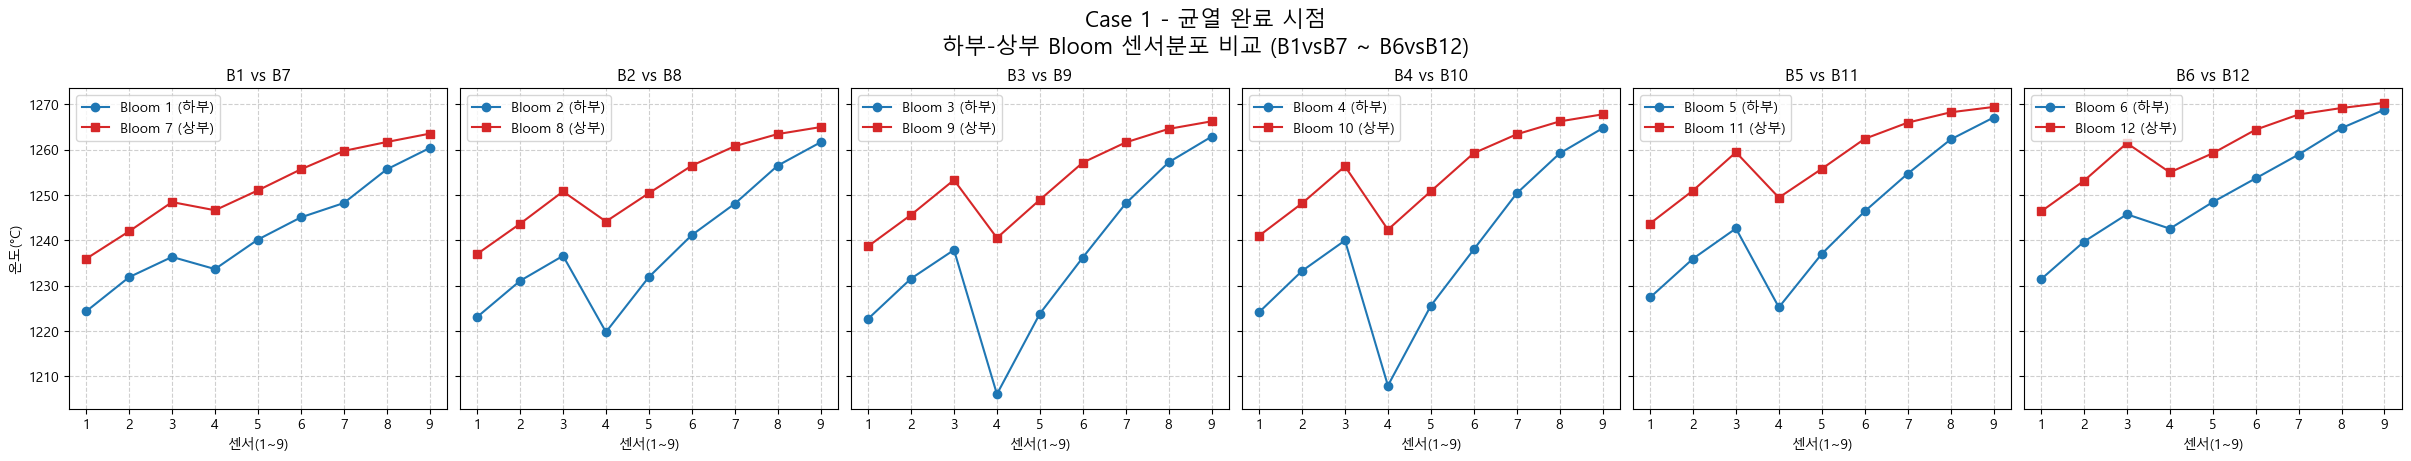


[그래프 생성] Case 2, 균열 완료 시점


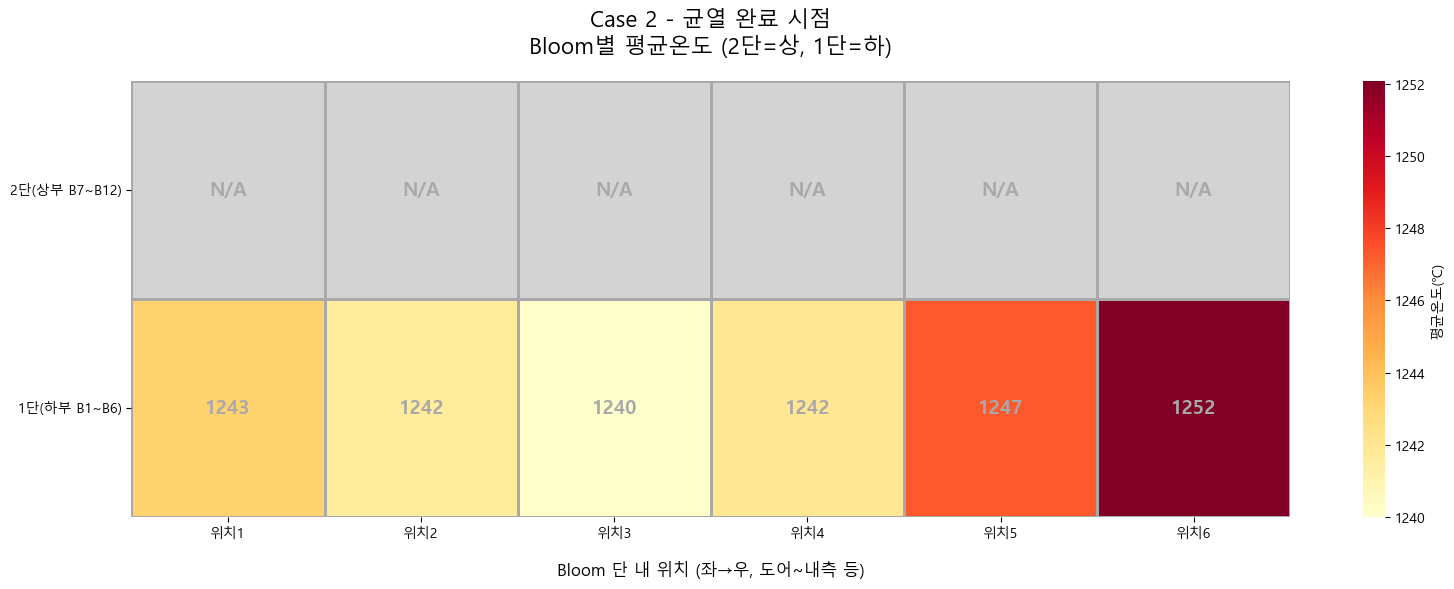

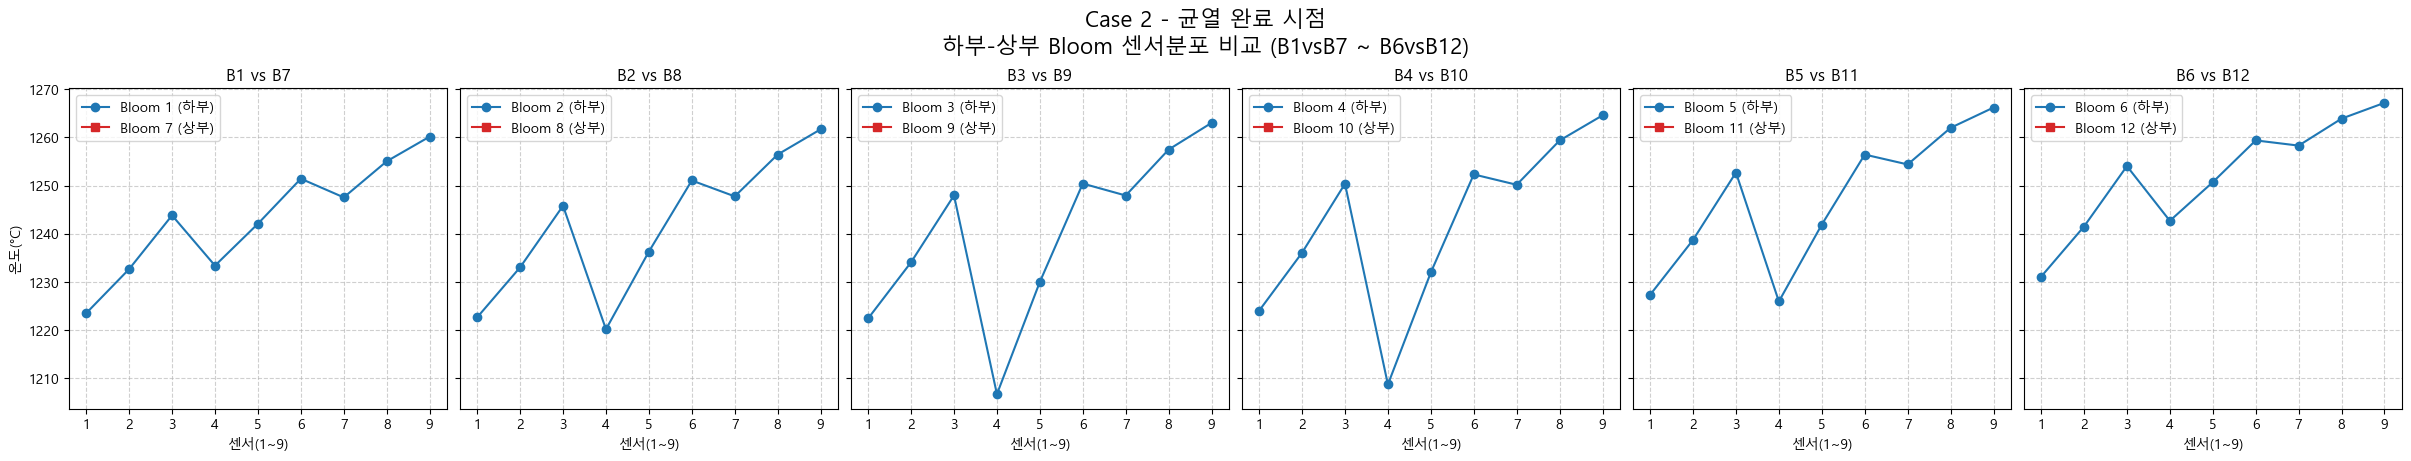


[그래프 생성] Case 3, 4hr 균열 시점


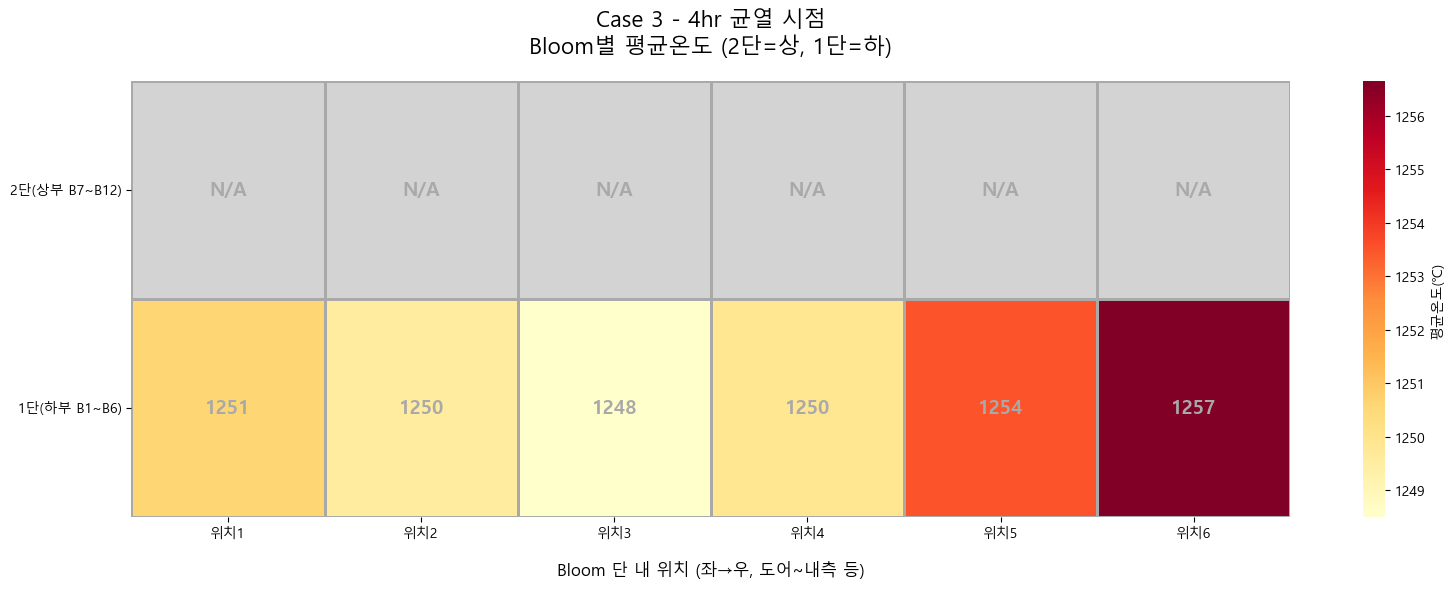

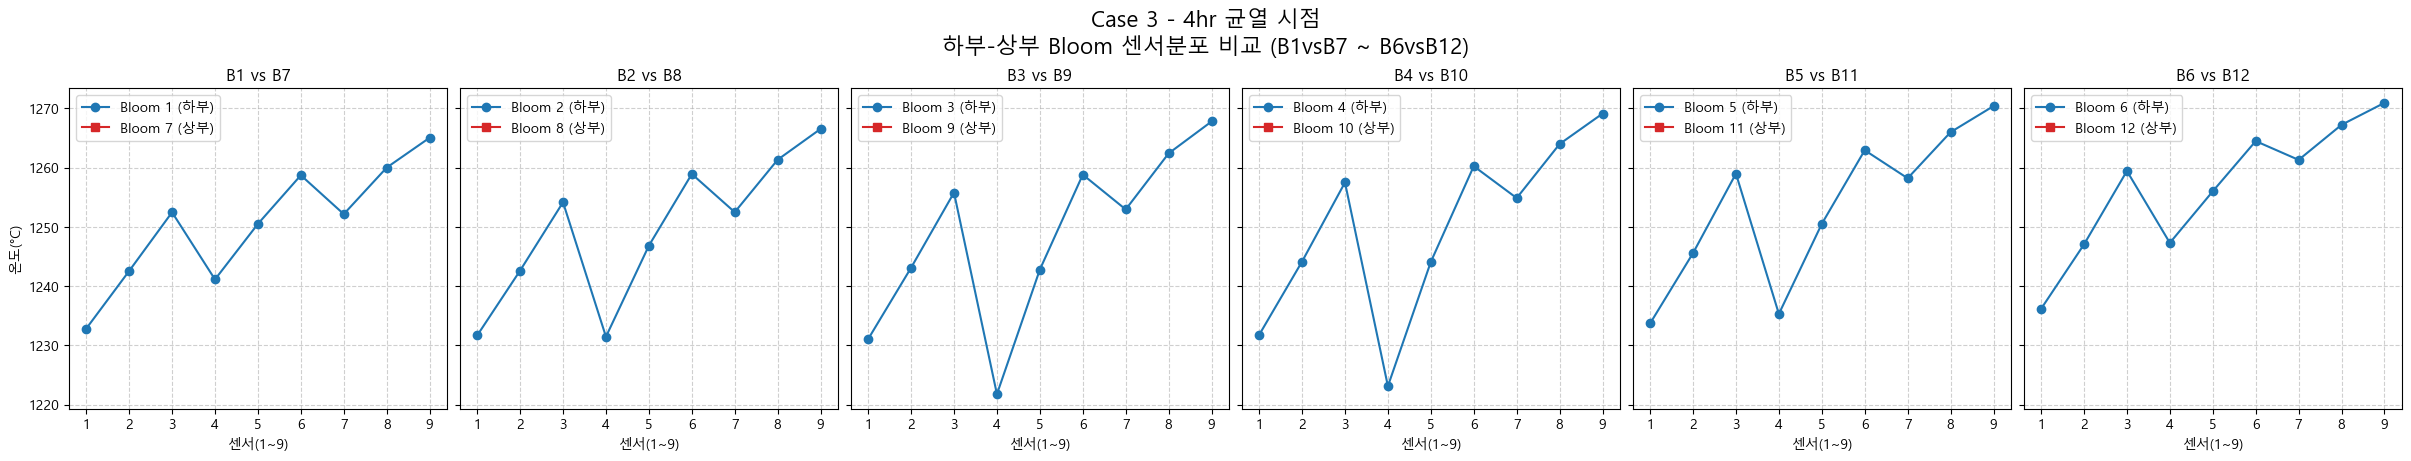


[그래프 생성] Case 3, 균열 완료 시점


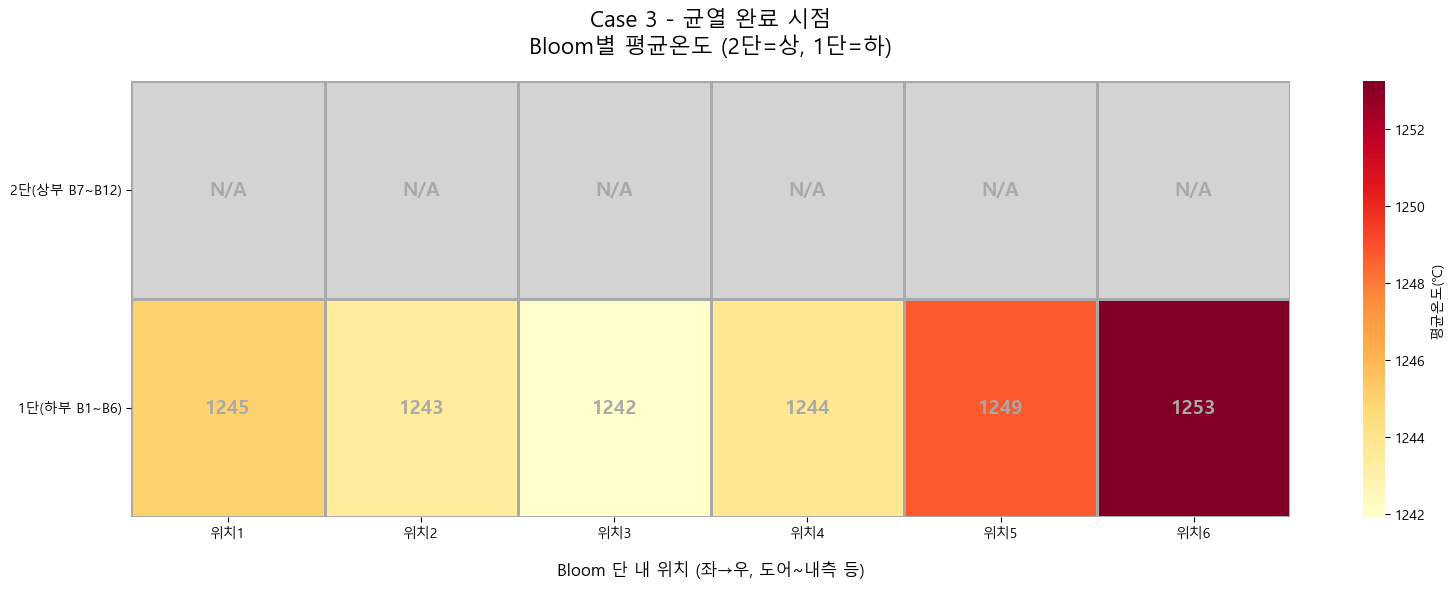

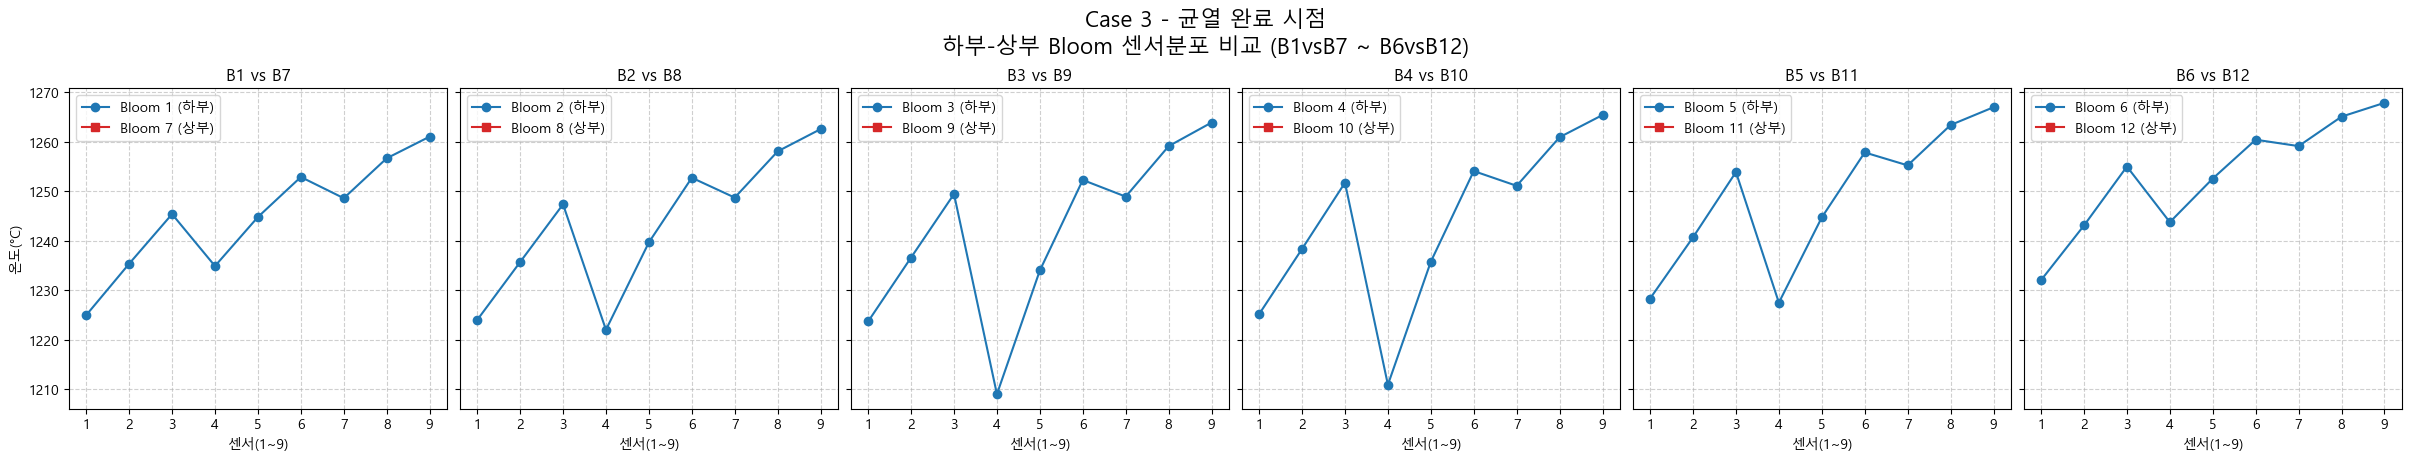


[그래프 생성] Case 4, 4hr 균열 시점


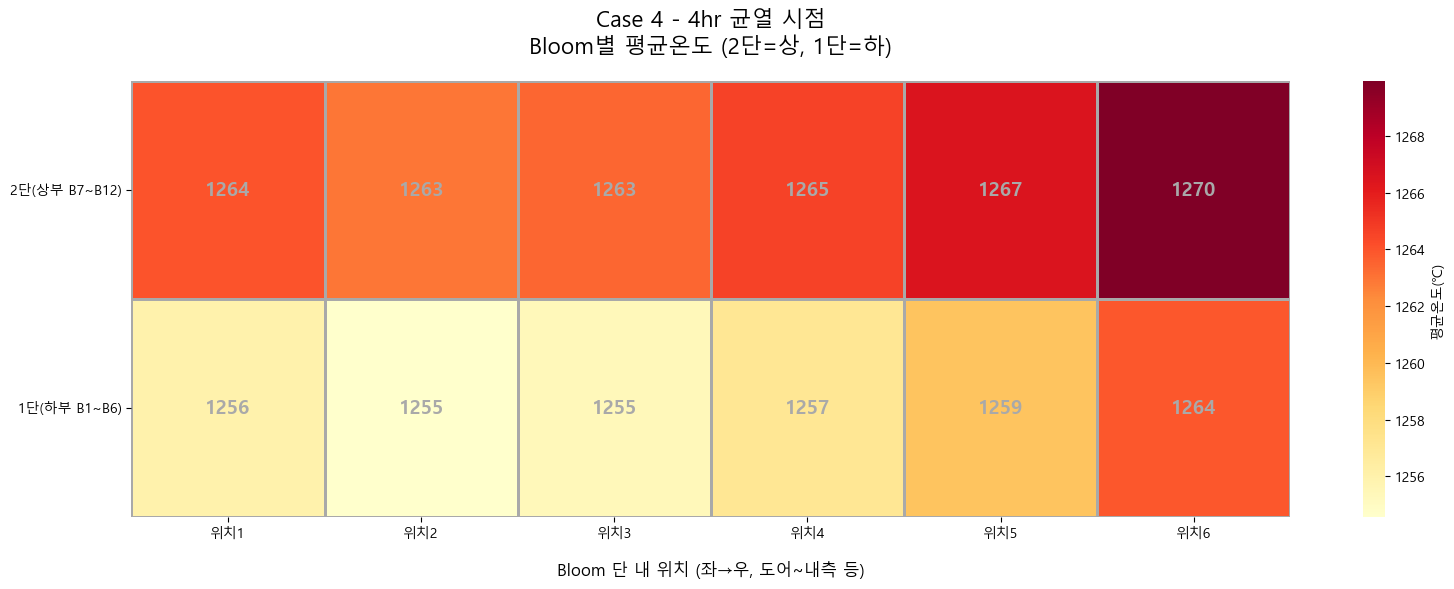

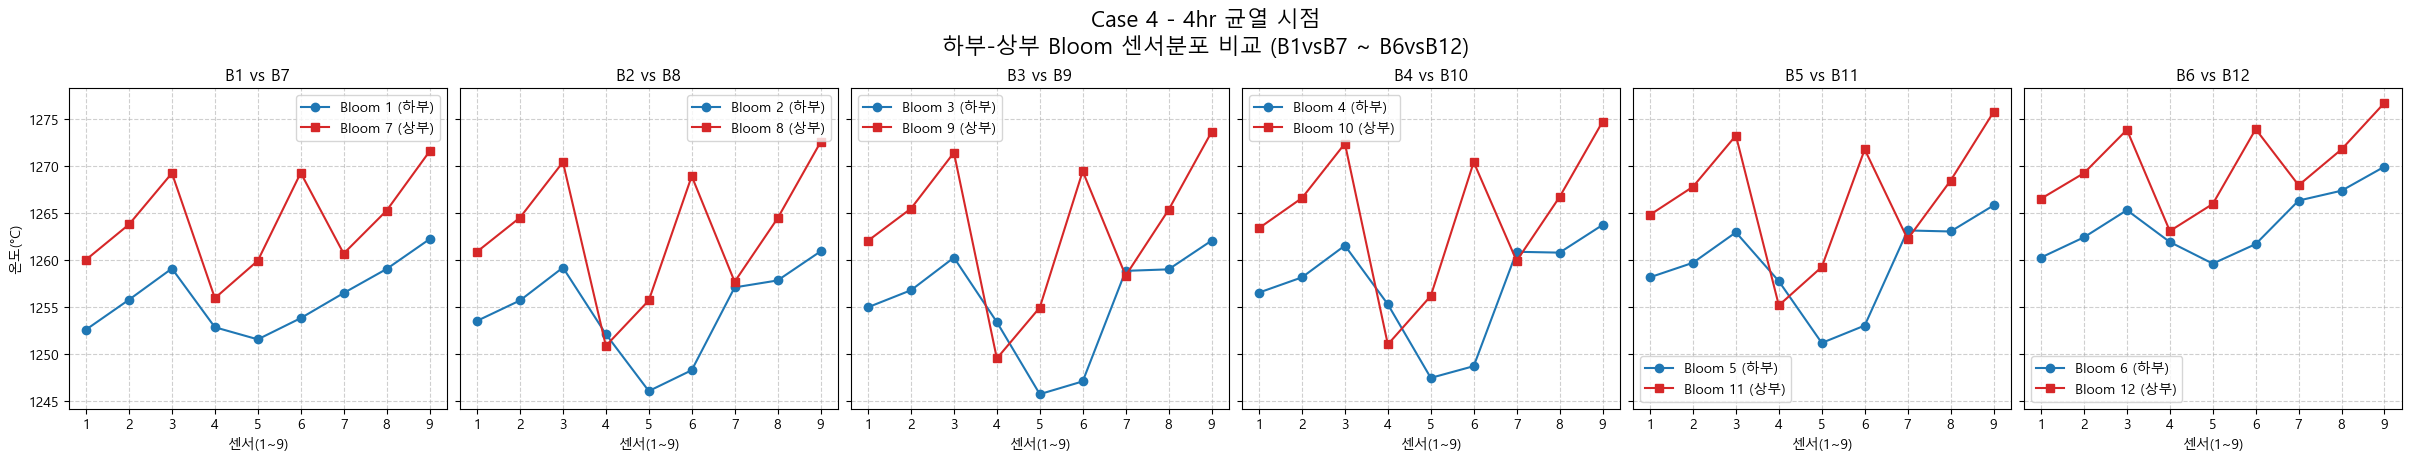


[그래프 생성] Case 4, 균열 완료 시점


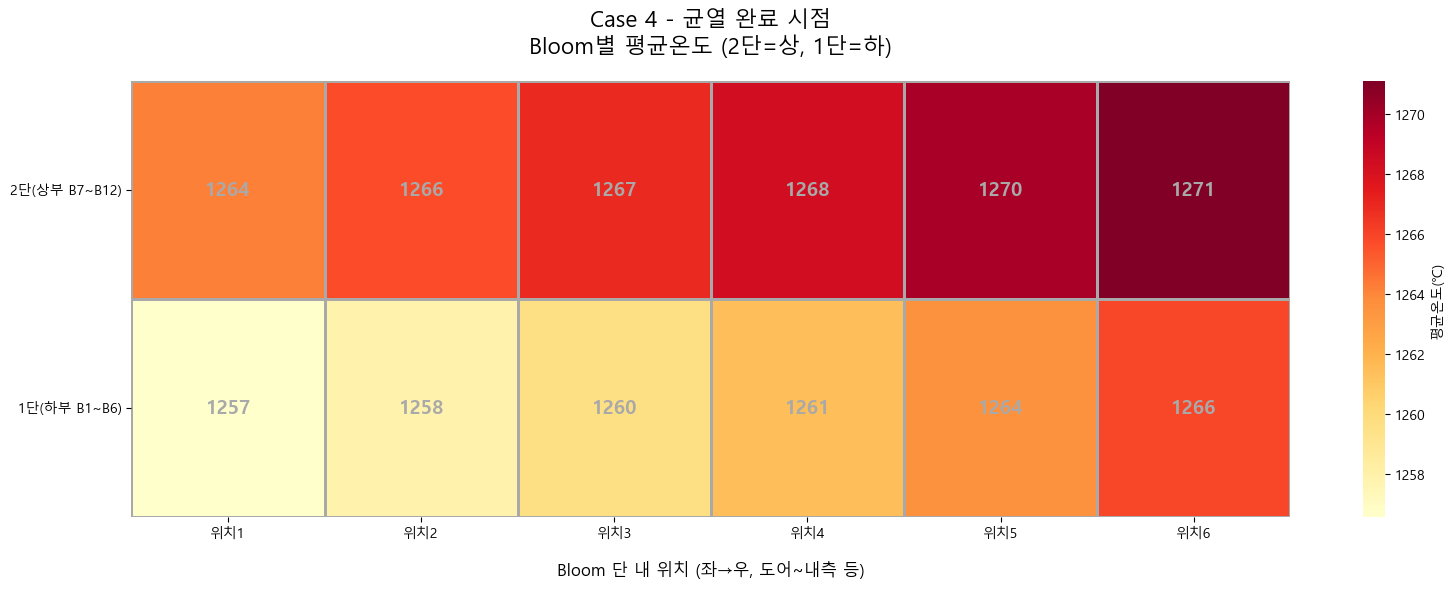

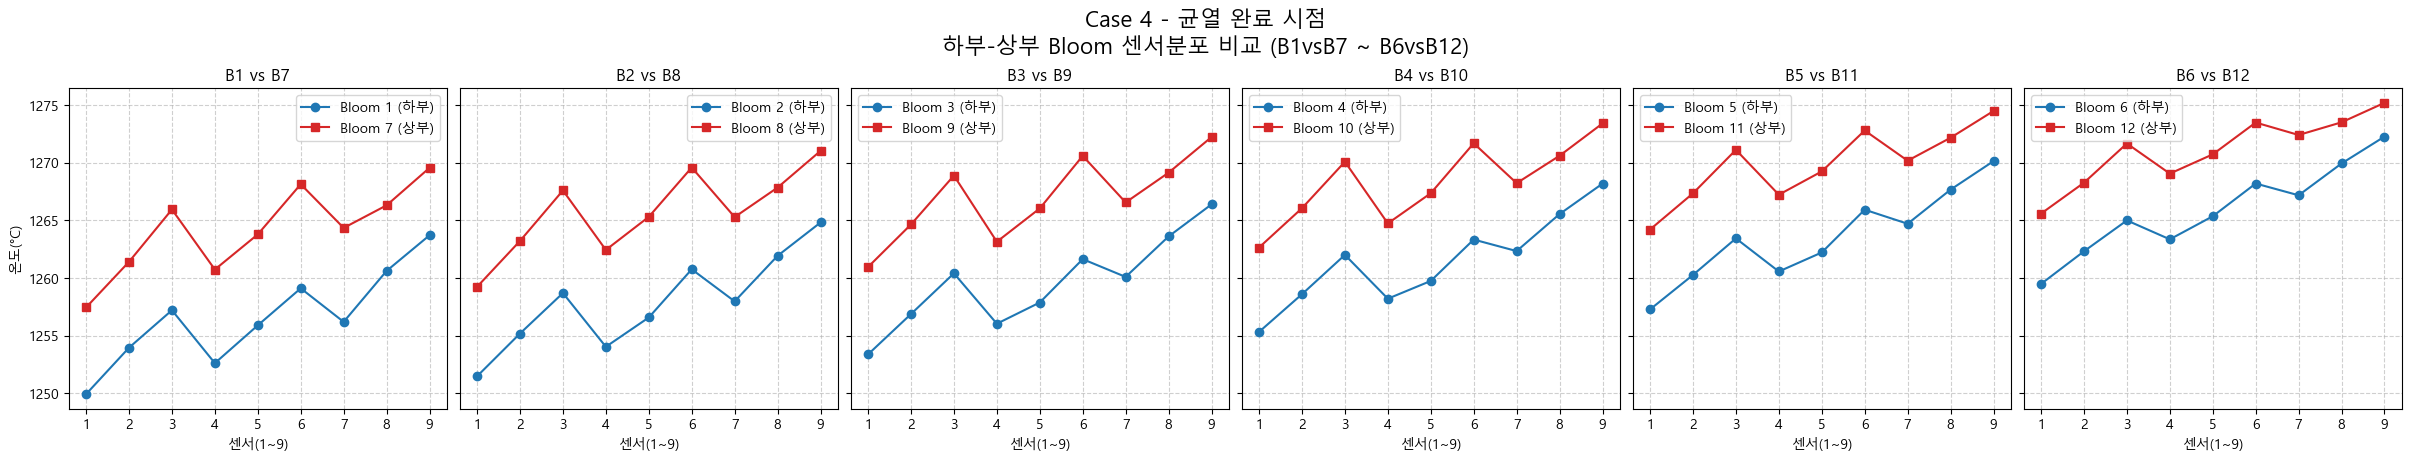


[그래프 생성] Case 5, 균열 완료 시점


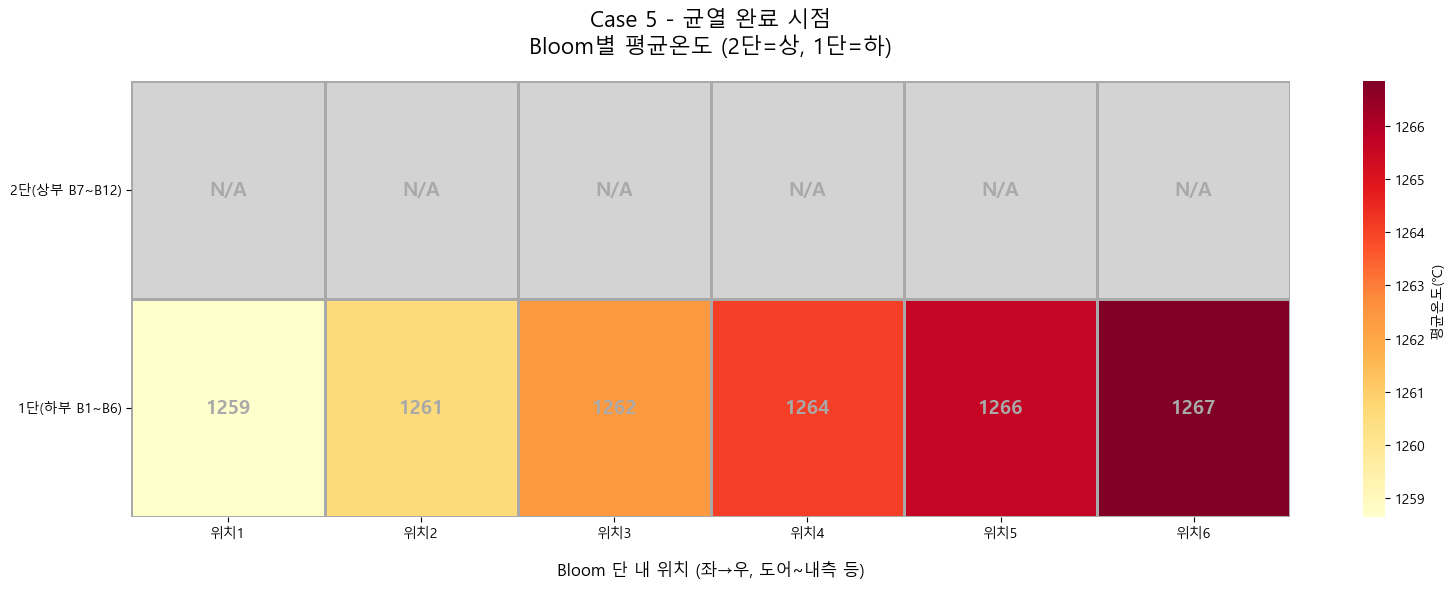

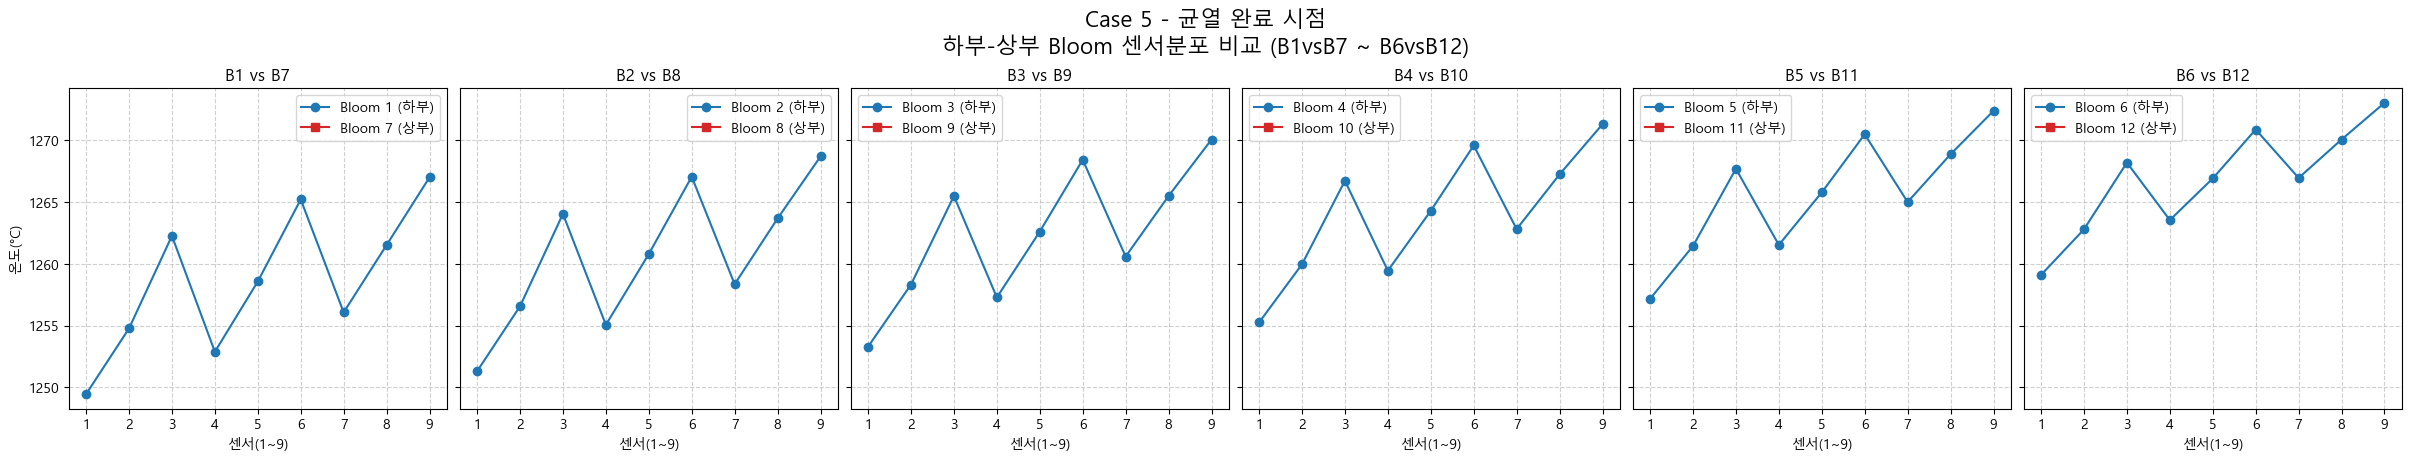


[그래프 생성] Case 6, 4hr 균열 시점


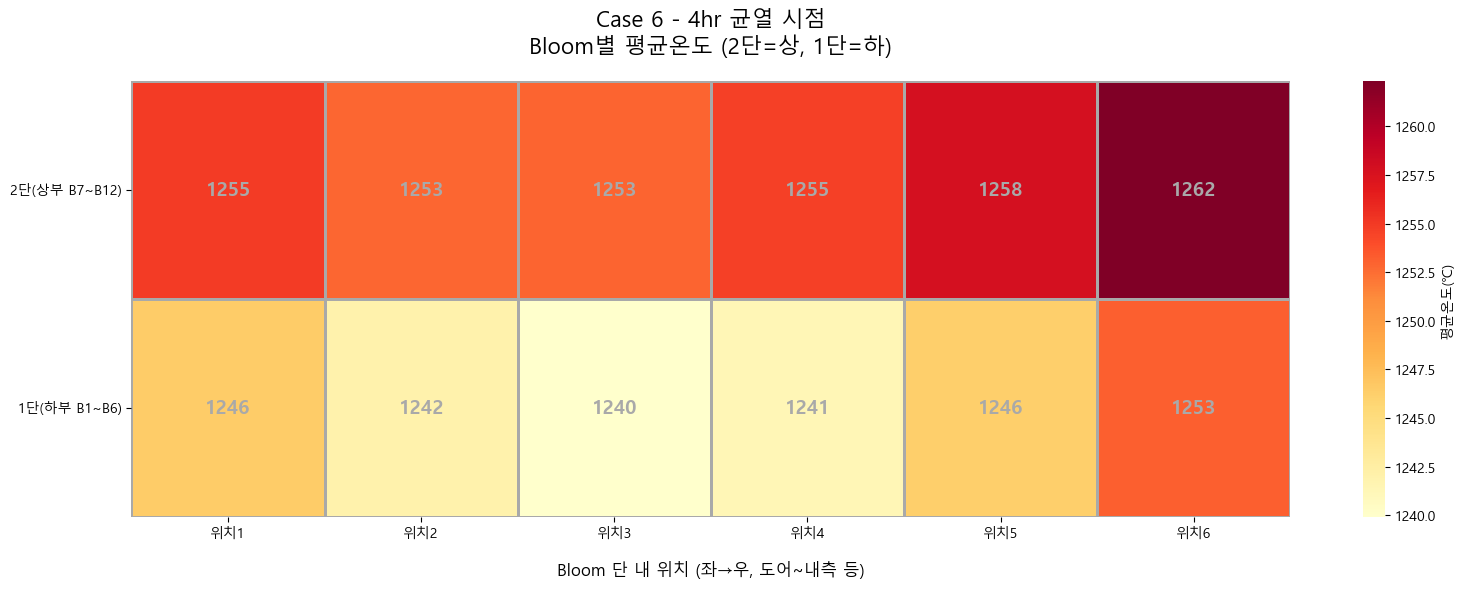

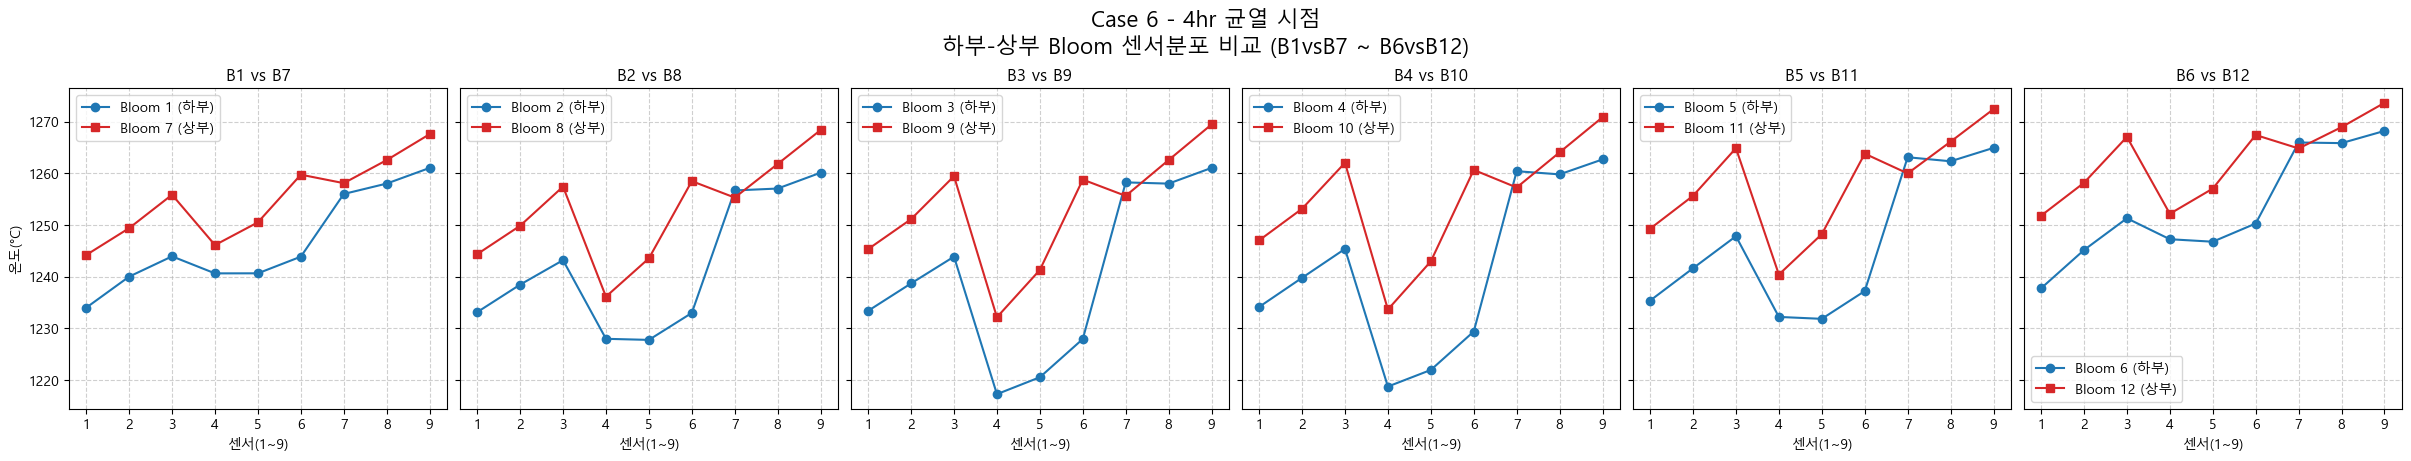


[그래프 생성] Case 6, 균열 완료 시점


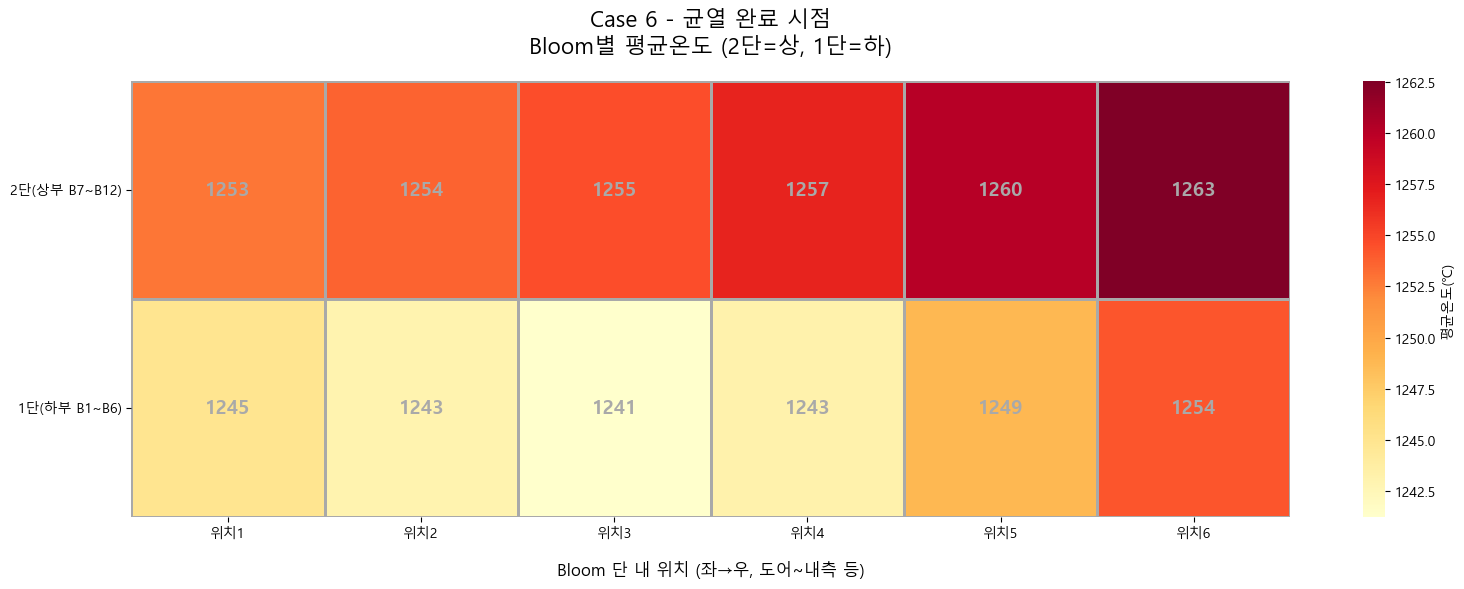

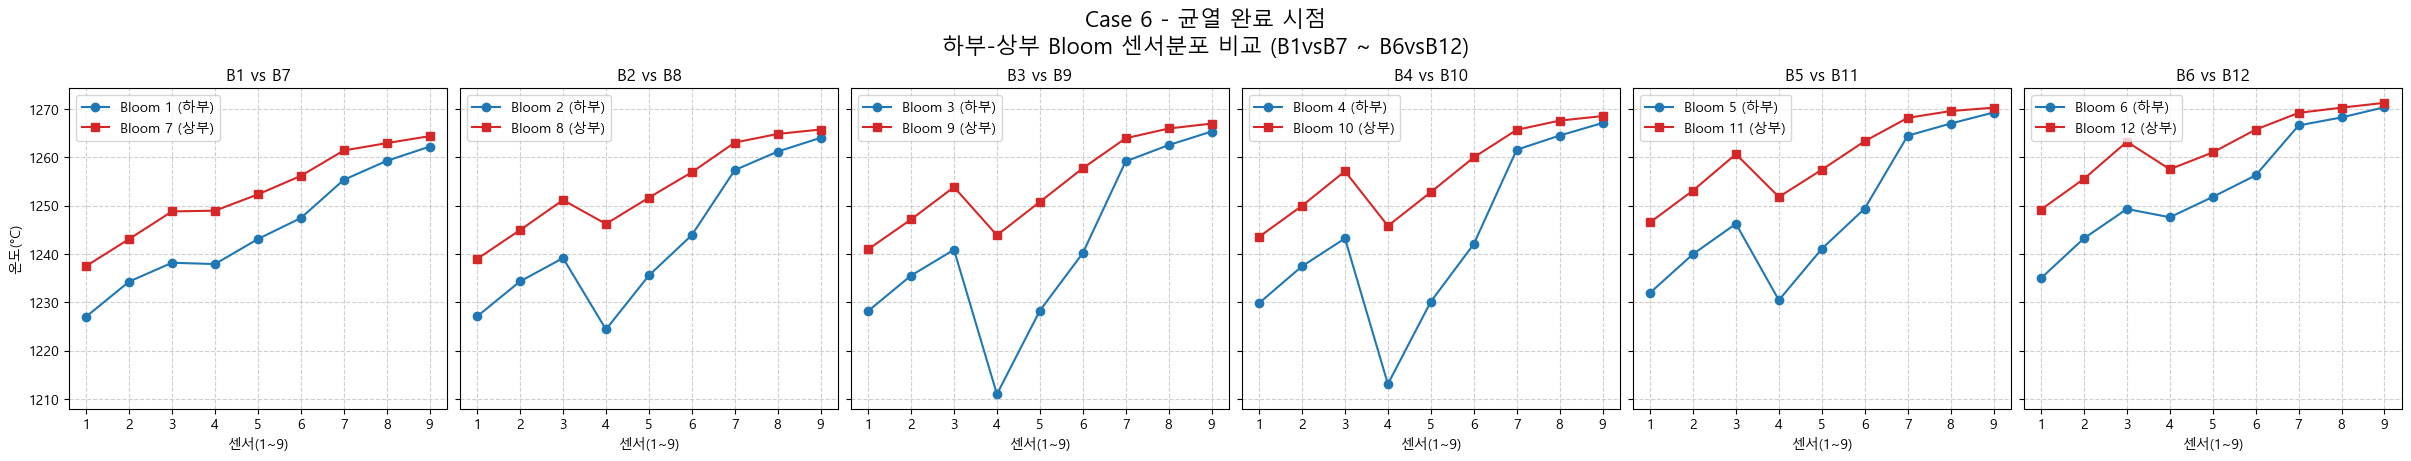


[그래프 생성] Case 7, 균열 완료 시점


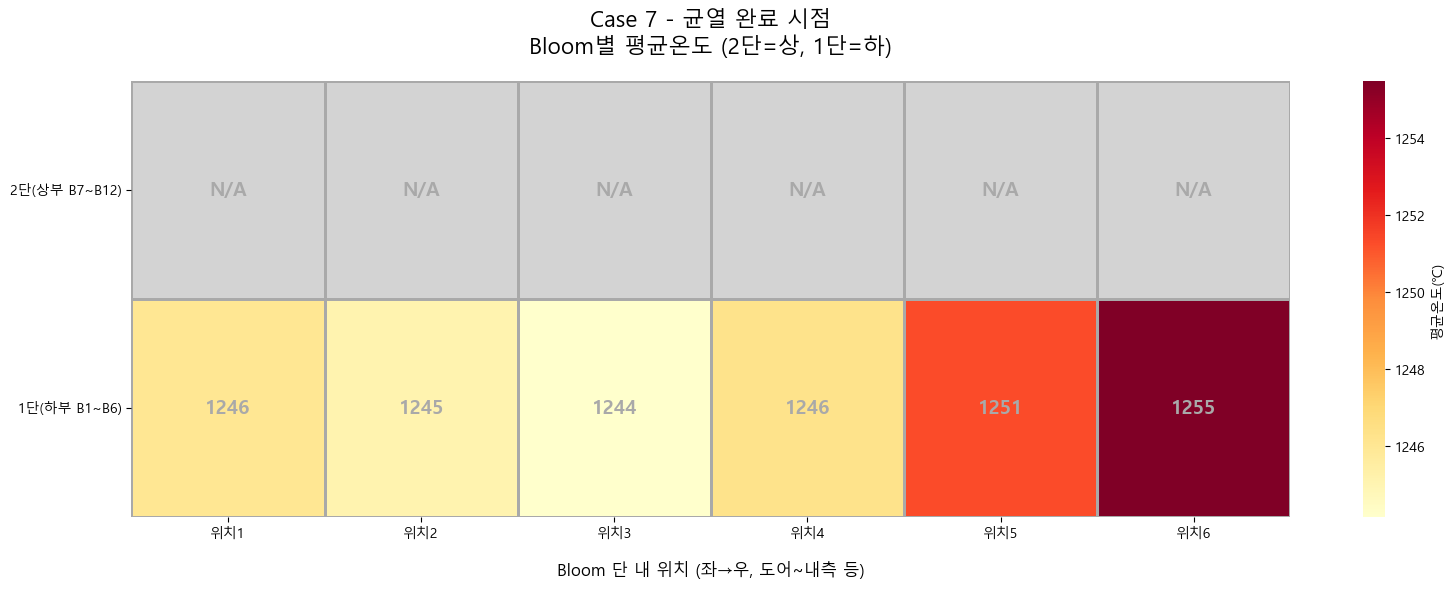

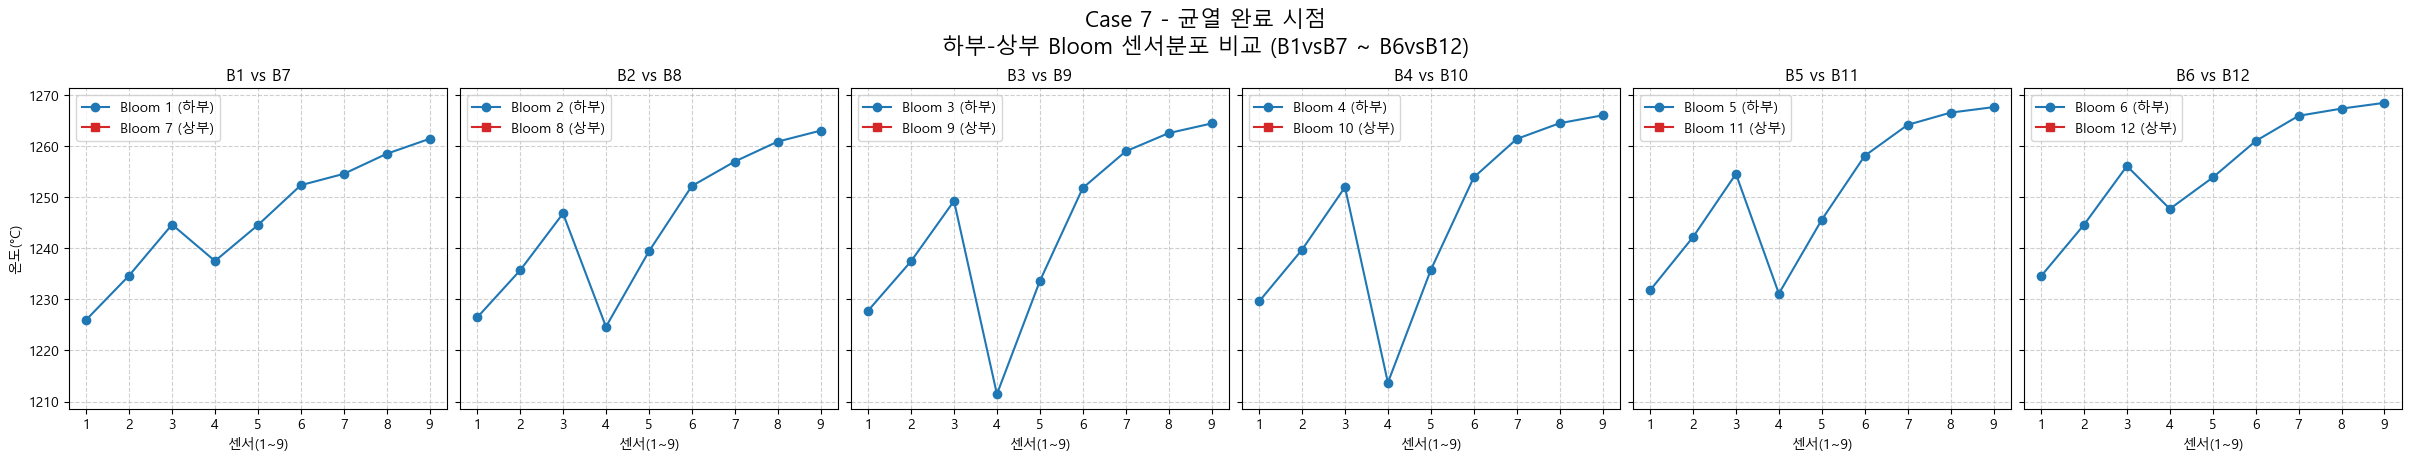


[그래프 생성] Case 8, 4hr 균열 시점


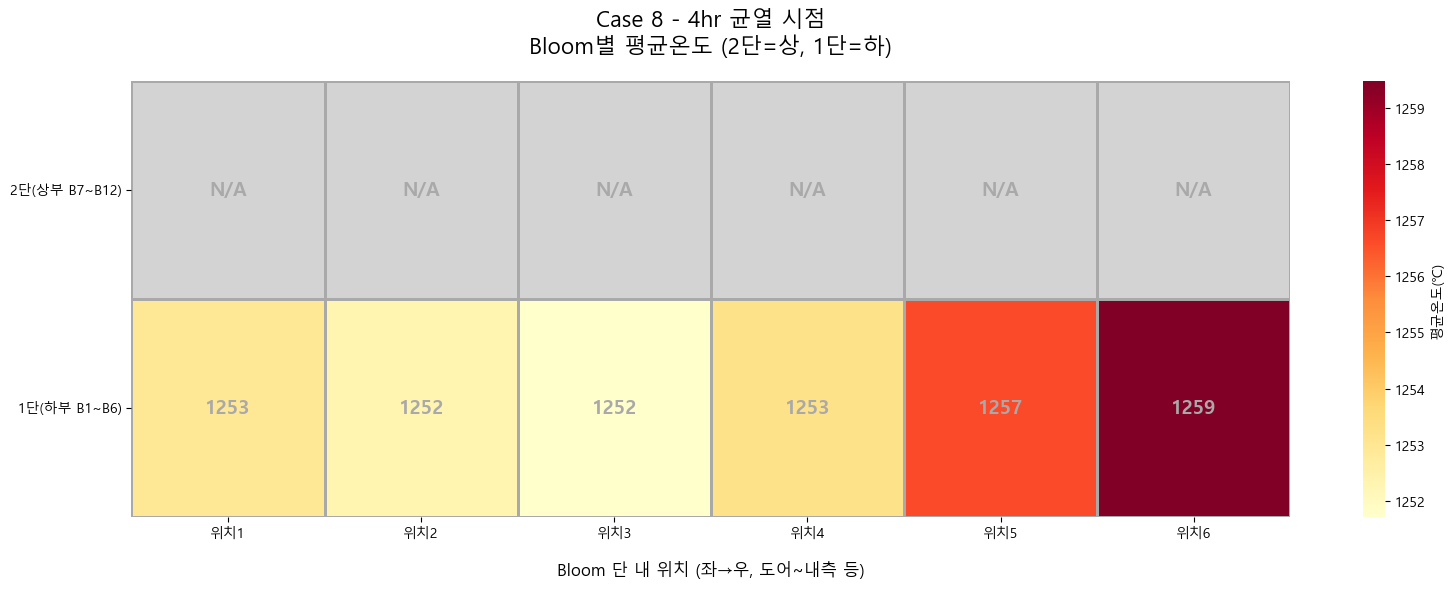

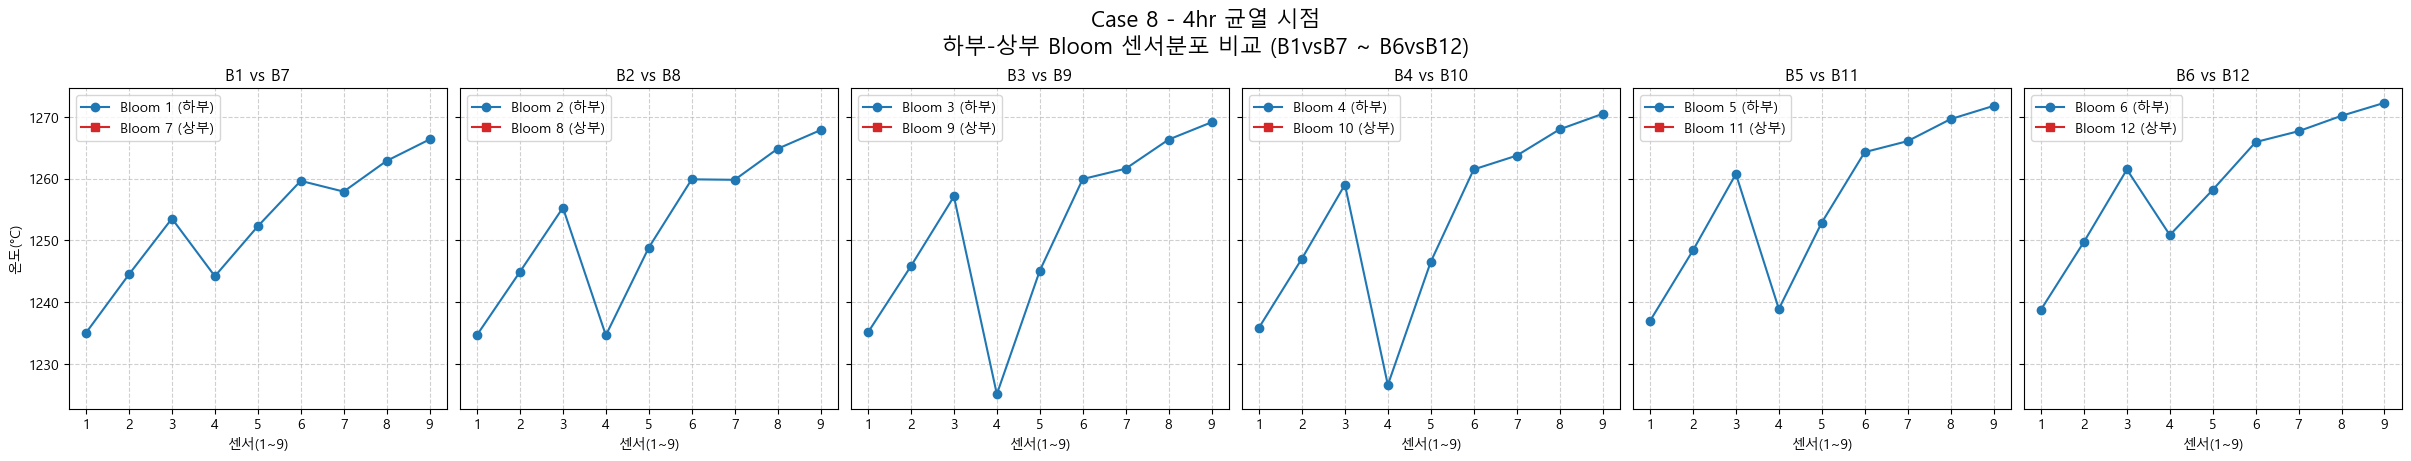


[그래프 생성] Case 8, 균열 완료 시점


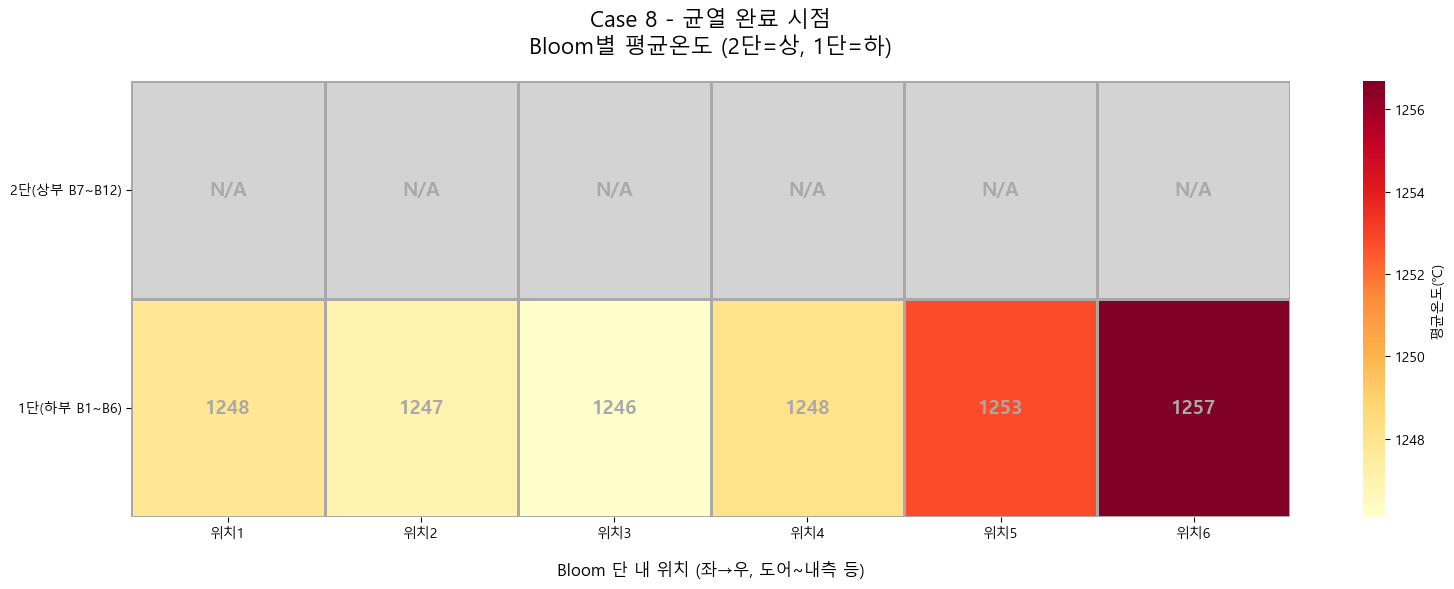

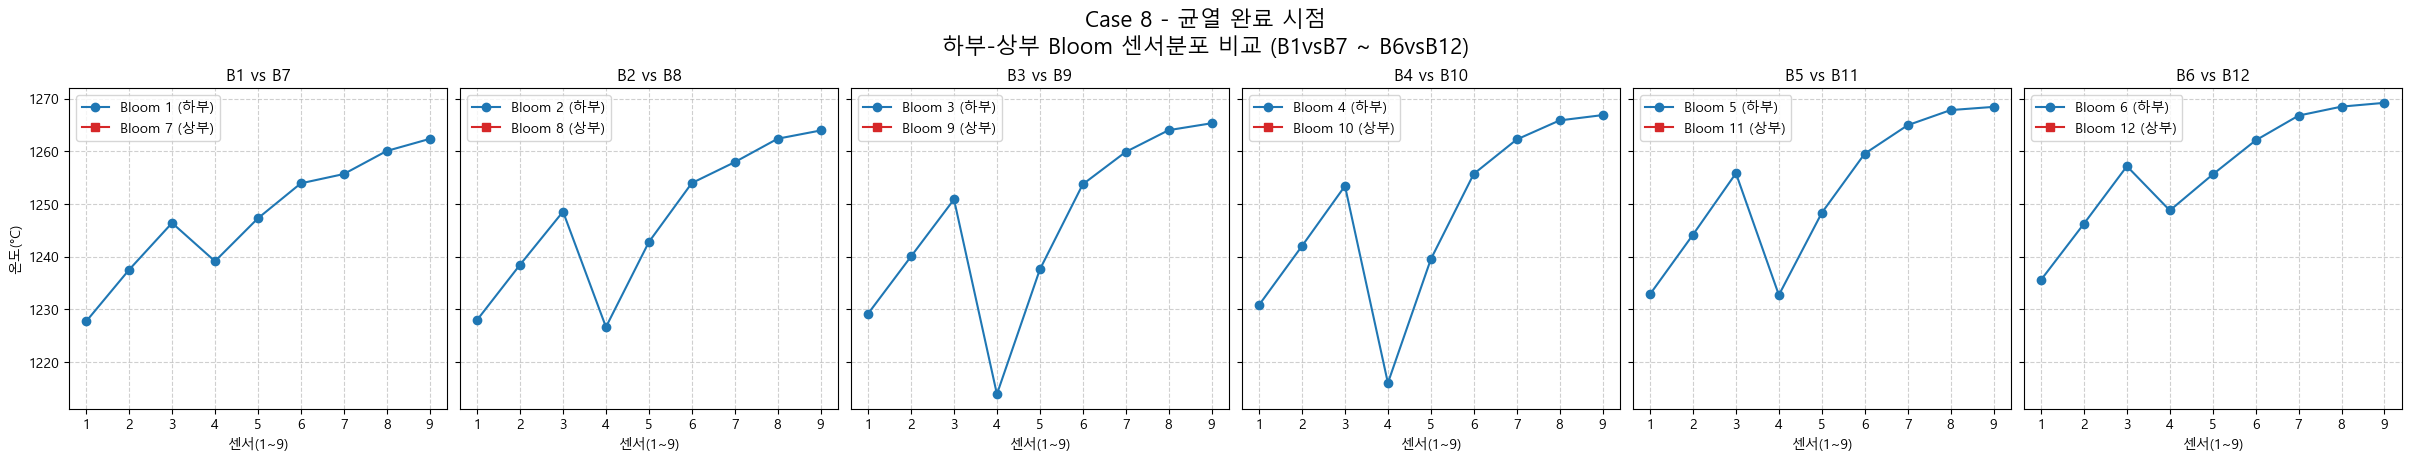


[그래프 생성] Case 9, 4hr 균열 시점


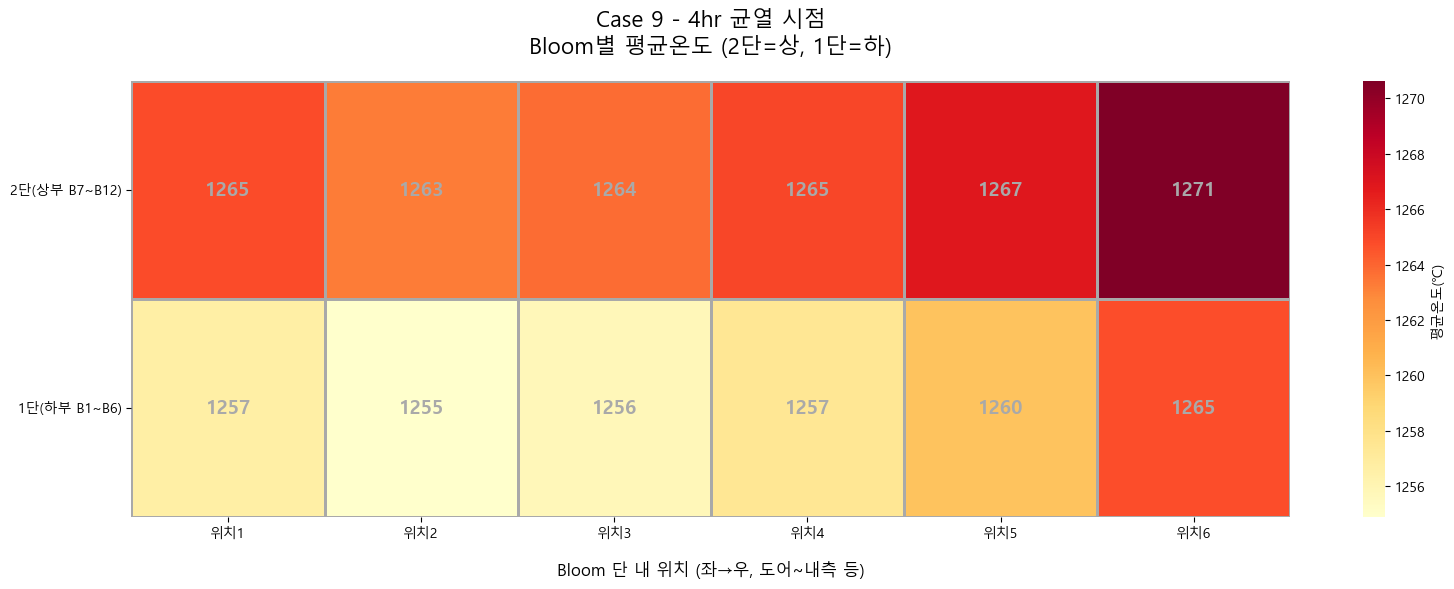

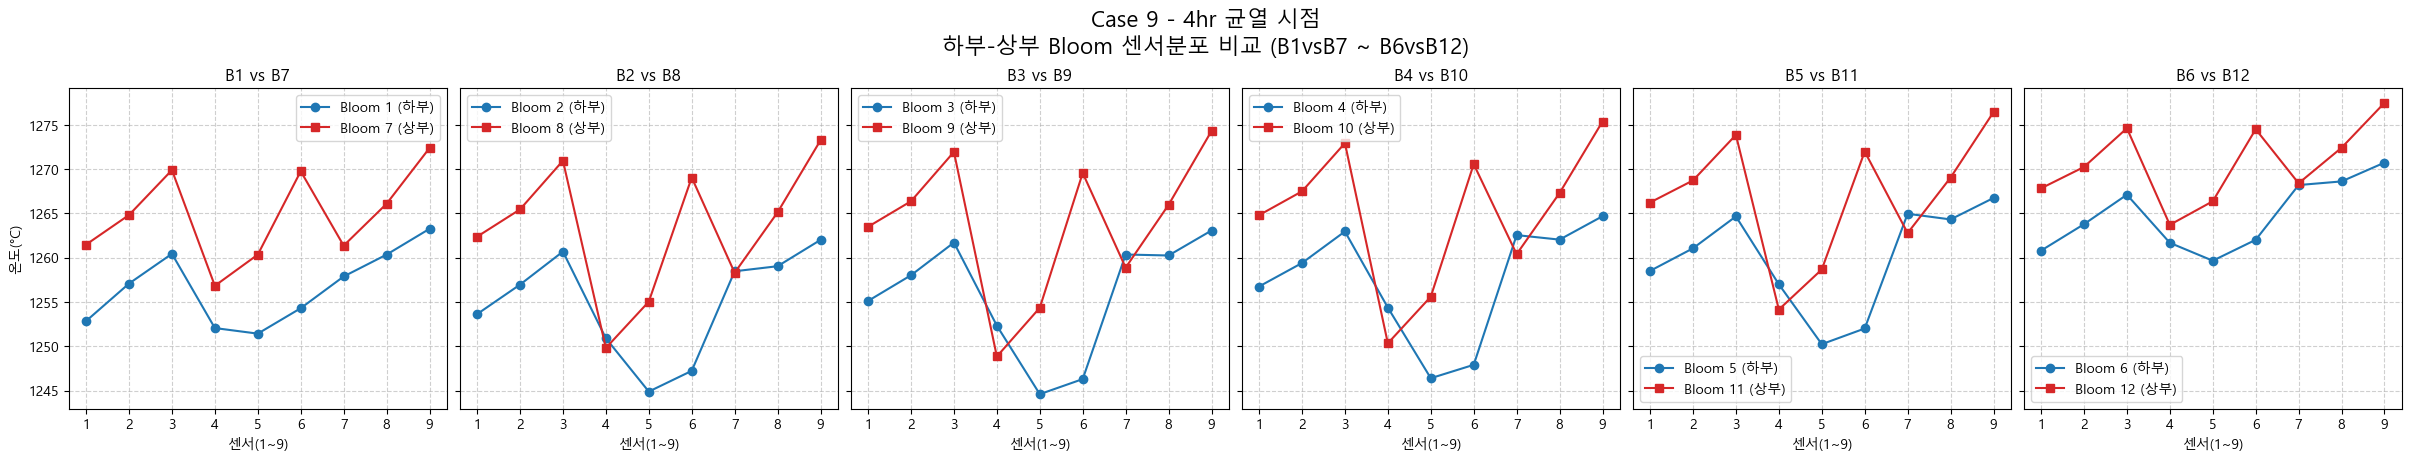


[그래프 생성] Case 9, 균열 완료 시점


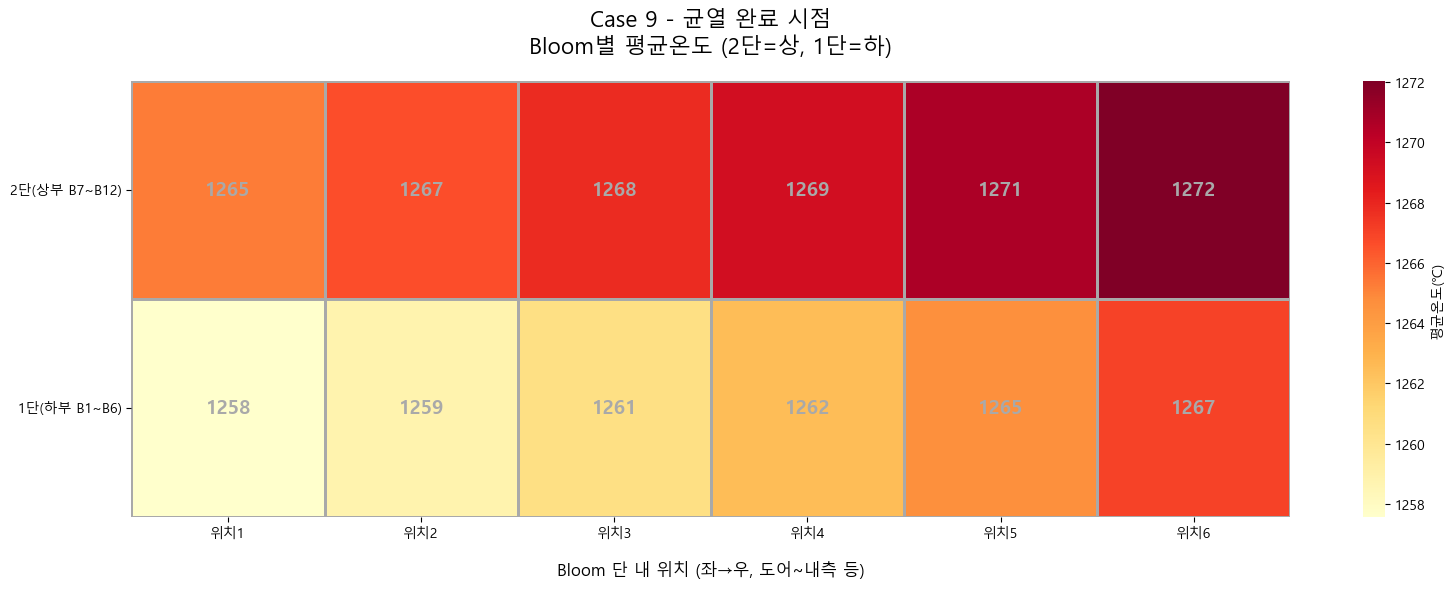

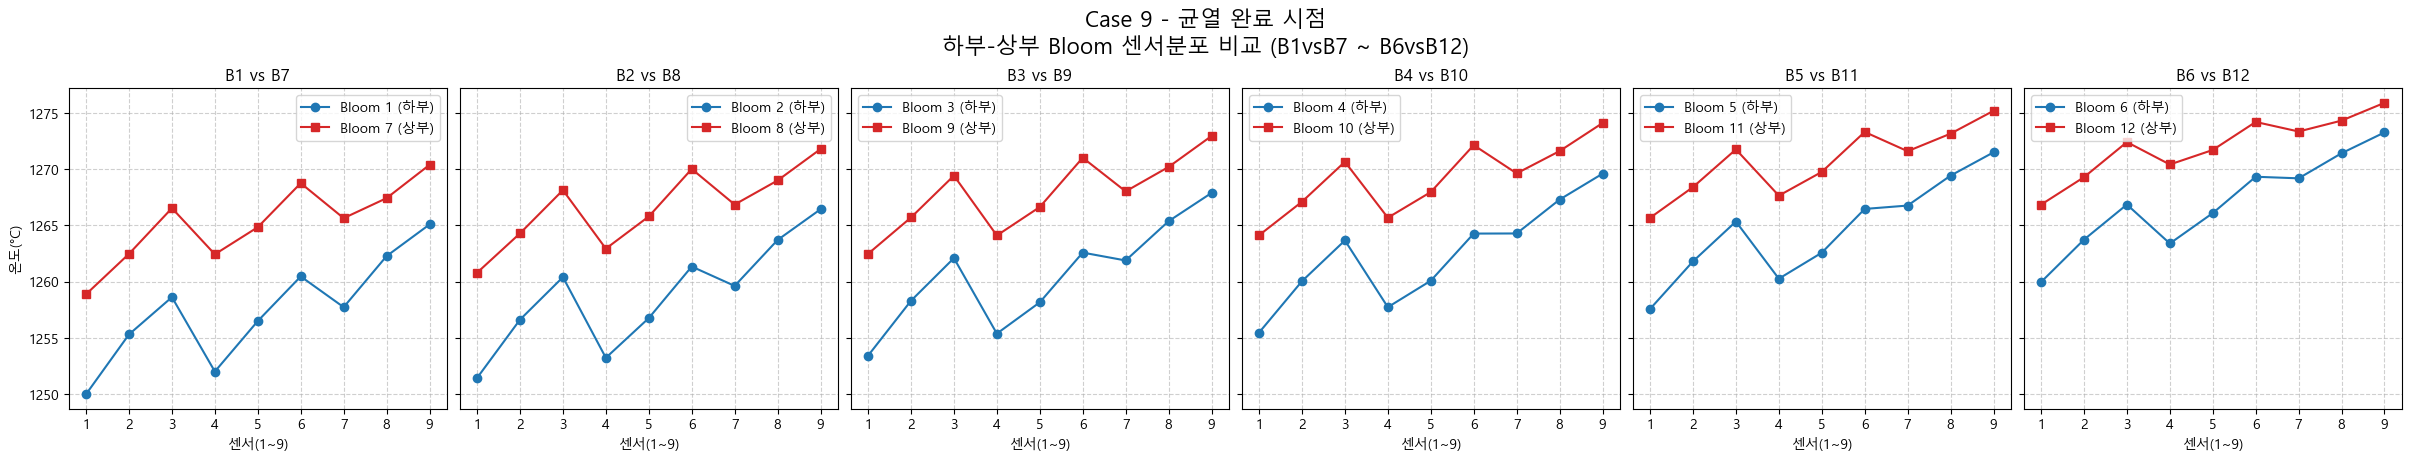


[그래프 생성] Case 10, 균열 완료 시점


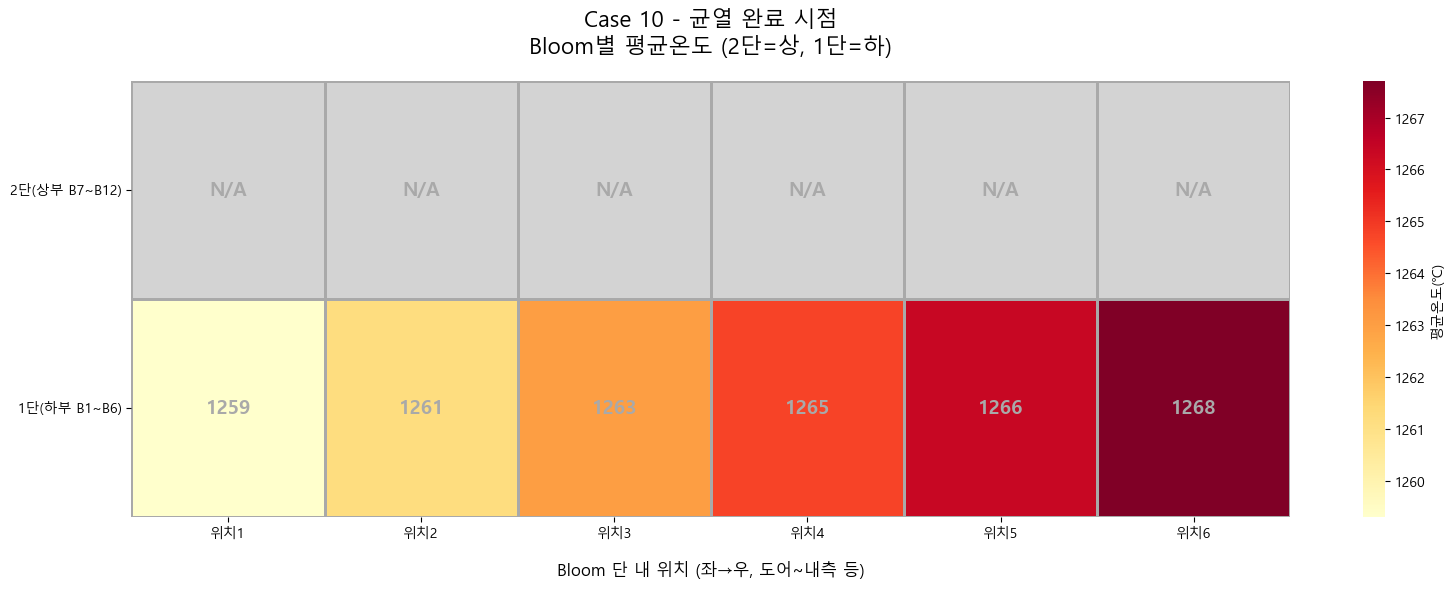

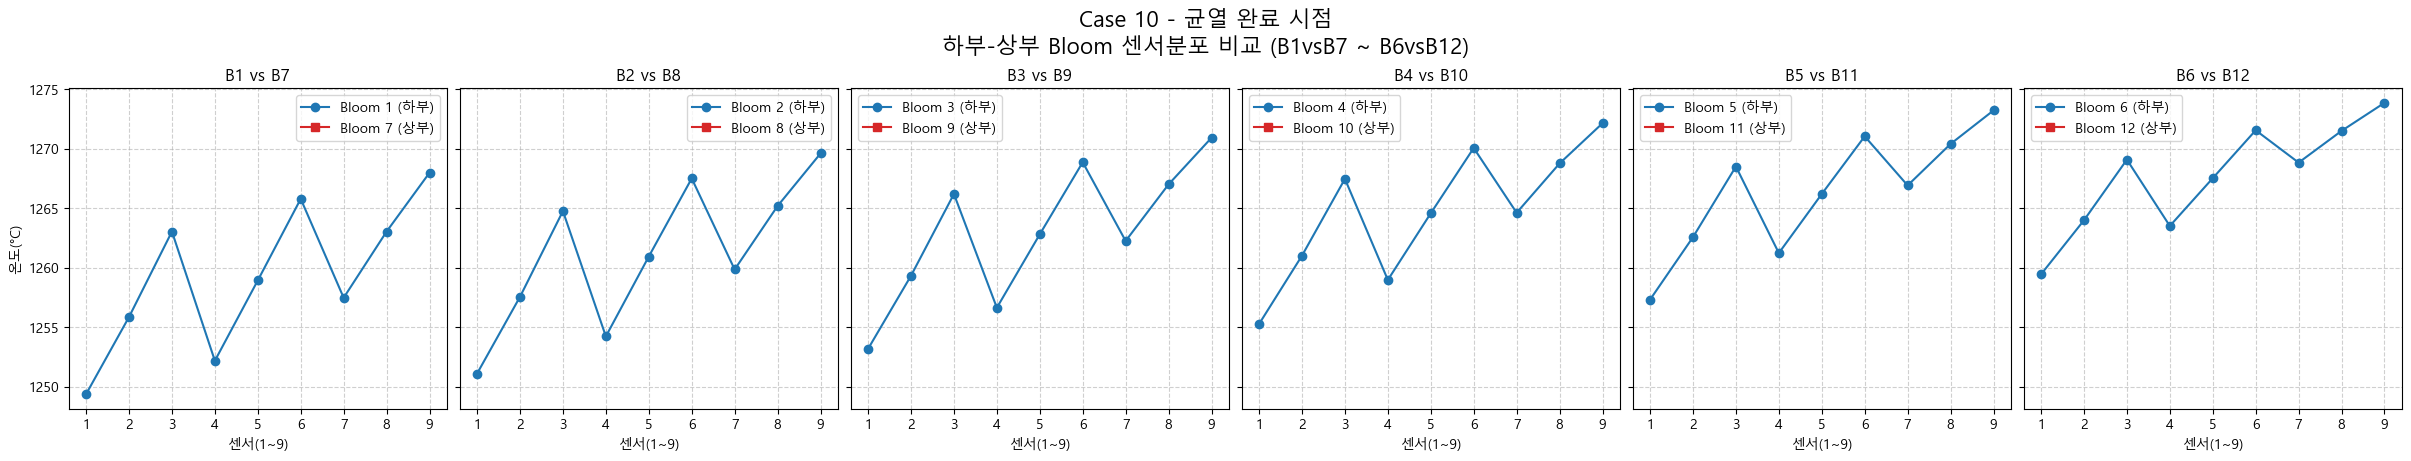

In [6]:
# ==============================================================================
# Step 0. [환경설정] - 한글 폰트/필수 패키지 임포트 (한글깨짐 방지)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Windows: Malgun Gothic, Mac: AppleGothic
try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    matplotlib.rc('font', family='AppleGothic')
matplotlib.rc('axes', unicode_minus=False)

# ==============================================================================
# Step 1. [분석 함수 정의] - 헤더 자동 탐색 및 Bloom/센서 추출
# ==============================================================================
def find_header_row(file_path, sheet_name):
    """Excel 시트에서 'Time'이 포함된 헤더 행 번호를 찾습니다."""
    try:
        tmp = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl', header=None, nrows=10)
        for i, row in tmp.iterrows():
            if any('time' in str(cell).strip().lower() for cell in row):
                return i
    except Exception as e:
        print(f"'{sheet_name}' 시트에서 헤더를 찾는 중 오류 발생: {e}")
    return 0

def extract_bloom_sensor_table(file_path, sheet_name, time_point):
    """지정된 시간의 Bloom 센서 데이터를 추출하여 DataFrame으로 만듭니다."""
    try:
        header_row = find_header_row(file_path, sheet_name)
        df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl', header=header_row)
        
        # 유효한 컬럼만 선택
        df = df.loc[:, df.columns.notnull()]
        df = df.loc[:, [str(c).strip() != "" for c in df.columns]]
        
        # Time 컬럼 찾기
        time_col = next((col for col in df.columns if 'time' in str(col).lower()), None)
        
        if not time_col:
            print(f"[{sheet_name}] 경고: Time 컬럼을 찾을 수 없습니다.")
            return None
            
        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        if df[time_col].isna().all():
            print(f"[{sheet_name}] 경고: Time 컬럼에 유효한 숫자 데이터가 없습니다.")
            return None
            
        # 지정된 시간에 가장 가까운 데이터 선택 (허용오차 0.5)
        time_data = df[np.isclose(df[time_col], time_point, atol=0.5)]
        if time_data.empty:
            # 데이터가 없는 것은 오류가 아니므로 정보성 메시지만 출력
            # print(f"[{sheet_name}] 정보: Time={time_point}에 해당하는 데이터가 없습니다.")
            return None

        rows = []
        for i in range(1, 13): # Bloom 1 ~ 12
            for j in range(1, 10): # Sensor 1 ~ 9
                col_name = f'Bloom {i} sensor {j}'
                if col_name in time_data.columns:
                    value = time_data.iloc[0][col_name]
                    rows.append({"Case": sheet_name, "Time": time_point, "Bloom": i, "Sensor": j, "Value": value})
        
        if not rows:
            print(f"[{sheet_name}, Time={time_point}] 정보: 추출된 Bloom 센서 데이터가 없습니다.")
            return None

        return pd.DataFrame(rows)
    except FileNotFoundError:
        print(f"오류: '{excel_file_path}' 파일을 찾을 수 없습니다.")
        return None
    except Exception as e:
        print(f"'{sheet_name}' 시트 처리 중 오류 발생: {e}")
        return None

# ==============================================================================
# Step 2. [수정] 분석대상 설정 - 케이스 10개로 확장
# ==============================================================================
excel_file_path = "250716_가열로 시뮬레이션 results3_가공.xlsx"
case_sheets = [f"Case {i}" for i in range(1, 11)] # Case 1부터 Case 10까지 리스트 생성
time_points = {
    "4hr 균열 시점 (Time = 47860)": 47860.0,
    "균열 완료 시점": 57382.5, # 기본값, 특정 케이스에서 변경됨
}

# ==============================================================================
# Step 3. [수정] Bloom/센서별 데이터 적재 - 특정 케이스 조건부 처리
# ==============================================================================
bloom_sensor_all = []
print("데이터 적재 시작...")

# 특정 조건이 적용될 케이스와 시간 값 정의
special_cases = ["Case 2", "Case 5", "Case 7", "Case 10"]
special_completion_time = 75382.5

for sheet in case_sheets:
    for time_desc, default_time_val in time_points.items():
        
        current_time_val = default_time_val
        
        # 특정 케이스에 대한 조건 처리
        if sheet in special_cases:
            if "4hr" in time_desc:
                print(f"  - 건너뛰기: {sheet}, {time_desc}")
                continue  # 4hr 시점은 건너뜀
            elif "균열 완료" in time_desc:
                current_time_val = special_completion_time # 특별 시간 값 적용
        
        # Time 키에서 동적으로 시간 값을 제거하고 현재 값을 추가하여 명확한 설명 생성
        base_time_desc = time_desc.split(' (Time')[0]
        current_time_desc_for_print = f"{base_time_desc} (Time = {current_time_val})"
        
        print(f"  - 처리 중: {sheet}, {current_time_desc_for_print}")
        result = extract_bloom_sensor_table(excel_file_path, sheet, current_time_val)
        
        if result is not None:
            result["TimeDesc"] = base_time_desc # 그룹핑을 위해 기본 설명 사용
            bloom_sensor_all.append(result)
            
print("데이터 적재 완료.")

if not bloom_sensor_all:
    raise Exception("데이터 적재 결과가 없습니다. 파일 경로, 시트명, 시간 값 등을 확인하세요.")
bloom_sensor_df = pd.concat(bloom_sensor_all, ignore_index=True)

# ==============================================================================
# Step 4. [Bloom별 요약 통계(평균, 내부ΔT, 최대/최소) 생성]
# ==============================================================================
bloom_summary = (
    bloom_sensor_df
    .groupby(['Case', 'TimeDesc', 'Bloom'])
    .agg(
        평균=('Value', 'mean'),
        내부ΔT=('Value', lambda x: np.nanmax(x) - np.nanmin(x) if x.notna().any() else np.nan),
        최대=('Value', 'max'),
        최소=('Value', 'min')
    )
    .reset_index()
)

# ==============================================================================
# Step 5. [최종 수정된 Heatmap 함수] - 라벨을 수동으로 그려 렌더링 문제 해결
# ==============================================================================
def plot_bloom_2x6_heatmap(df, case, time_desc):
    """
    Bloom별 평균 온도를 2x6 히트맵으로 시각화합니다.
    Seaborn의 자동 annotation 대신 수동으로 텍스트를 그려 렌더링 문제를 해결합니다.
    """
    mat = np.full((2, 6), np.nan)
    labels = np.empty((2, 6), dtype=object)

    for bloom_num in range(1, 13):
        row = 1 if bloom_num <= 6 else 0
        col = (bloom_num - 1) % 6

        # 해당 조건의 데이터를 찾음
        subset = df[(df['Case'] == case) & (df['TimeDesc'] == time_desc) & (df['Bloom'] == bloom_num)]

        # 데이터가 존재하고, '평균' 값이 유효한 숫자인지 확인
        if not subset.empty and pd.notna(subset['평균'].values[0]):
            avg_temp = subset['평균'].values[0]
            mat[row, col] = avg_temp
            labels[row, col] = f'{avg_temp:.0f}'
        else:
            # 데이터가 없거나 NaN 값이면 'N/A'로 처리
            mat[row, col] = np.nan
            labels[row, col] = 'N/A'

    plt.figure(figsize=(16, 6))
    
    # NaN 값을 표시할 색상(lightgray)을 지정
    cmap = plt.get_cmap("YlOrRd").copy()
    cmap.set_bad(color='lightgray')

    # 1. 히트맵을 그림 (자동 annotation 기능은 사용 안 함)
    ax = sns.heatmap(mat, fmt='', cmap=cmap, cbar_kws={"label": "평균온도(℃)"},
                     linewidths=1, linecolor='darkgray')

    # 2. 각 셀에 수동으로 텍스트 라벨을 추가
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            label_text = labels[r, c]
            ax.text(c + 0.5, r + 0.5, label_text,
                    ha='center', va='center',
                    fontsize=14, weight='bold', color='darkgray') # 글자색 회색으로 변경
    
    plt.title(f"{case} - {time_desc}\nBloom별 평균온도 (2단=상, 1단=하)", fontsize=16, pad=20)
    plt.yticks([0.5, 1.5], ["2단(상부 B7~B12)", "1단(하부 B1~B6)"], rotation=0, va='center')
    plt.xticks(np.arange(6) + 0.5, [f"위치{i}" for i in range(1, 7)], rotation=0)
    plt.xlabel("Bloom 단 내 위치 (좌→우, 도어~내측 등)", fontsize=12, labelpad=15)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Step 6. [2x6 배열 Bloom별 센서값 꺾은선그래프]
# ==============================================================================
# def plot_all_bloom_sensors_2x6(df, case, time_desc):
#     fig, axs = plt.subplots(2, 6, figsize=(20, 6), sharey=True, constrained_layout=True)
#     fig.suptitle(f"{case} - {time_desc}\nBloom별 센서값 (2단=상, 1단=하)", fontsize=16)
    
#     for b in range(1, 13):
#         subset = df[(df['Case']==case) & (df['TimeDesc']==time_desc) & (df['Bloom']==b)].sort_values('Sensor')
#         row = 1 if b <= 6 else 0
#         col = (b-1) % 6
        
#         ax = axs[row, col]
#         if not subset.empty:
#             ax.plot(subset['Sensor'], subset['Value'], marker='o', linestyle='-')
#         ax.set_title(f"Bloom {b}", fontsize=11)
#         ax.set_xlabel("센서(1~9)")
#         ax.grid(True, linestyle='--', alpha=0.6)

#     for ax in axs[:, 0]:
#         ax.set_ylabel("온도(°C)")

#     axs[0,0].set_ylabel("온도(°C)\n2단(상부 B7~B12)")
#     axs[1,0].set_ylabel("온도(°C)\n1단(하부 B1~B6)")
    
#     plt.show()

# ==============================================================================
# Step 7. 상부-하부 Bloom(쌍) 비교 꺾은선 그래프(B1&B7, ..., B6&B12) - 1x6 플롯
# ==============================================================================
def plot_bloom_pairs(df, case, time_desc):
    fig, axs = plt.subplots(1, 6, figsize=(24, 4.5), sharey=True, constrained_layout=True)
    fig.suptitle(f"{case} - {time_desc}\n하부-상부 Bloom 센서분포 비교 (B1vsB7 ~ B6vsB12)", fontsize=16)
    colors = ['tab:blue', 'tab:red']
    
    for i in range(1, 7):
        ax = axs[i-1]
        
        # 하부(B1~B6)
        sub1 = df[(df['Case']==case) & (df['TimeDesc']==time_desc) & (df['Bloom']==i)].sort_values('Sensor')
        # 상부(B7~B12)
        sub2 = df[(df['Case']==case) & (df['TimeDesc']==time_desc) & (df['Bloom']==i+6)].sort_values('Sensor')
        
        if not sub1.empty:
            ax.plot(sub1['Sensor'], sub1['Value'], marker='o', label=f"Bloom {i} (하부)", color=colors[0])
        if not sub2.empty:
            ax.plot(sub2['Sensor'], sub2['Value'], marker='s', label=f"Bloom {i+6} (상부)", color=colors[1])
        
        ax.set_title(f"B{i} vs B{i+6}", fontsize=12)
        ax.set_xlabel("센서(1~9)")
        ax.grid(True, linestyle='--', alpha=0.6)
        if ax.has_data():
            ax.legend()

    axs[0].set_ylabel("온도(°C)")
    plt.show()

# ==============================================================================
# Step 8. 모든 유효한 케이스에 대해 그래프 자동 생성
# ==============================================================================
# case_sheets에 정의된 모든 케이스에 대해 반복
for case_name in case_sheets:
    # 각 케이스의 시간대별로 반복
    for time_description in time_points.keys():
        # Step 3에서 조건에 따라 데이터가 로드되었으므로,
        # bloom_summary에 해당 데이터가 있는지 확인하는 것만으로 충분합니다.
        has_data = not bloom_summary[(bloom_summary['Case'] == case_name) & (bloom_summary['TimeDesc'] == time_description.split(' (Time')[0])].empty
        
        if has_data:
            print(f"\n{'='*40}\n[그래프 생성] {case_name}, {time_description.split(' (Time')[0]}\n{'='*40}")
            plot_bloom_2x6_heatmap(bloom_summary, case_name, time_description.split(' (Time')[0])
            #plot_all_bloom_sensors_2x6(bloom_sensor_df, case_name, time_description.split(' (Time')[0])
            plot_bloom_pairs(bloom_sensor_df, case_name, time_description.split(' (Time')[0])
        else:
            # 이 메시지는 Step 3의 '건너뛰기' 메시지로 대체될 수 있습니다.
            # print(f"\n[알림] '{case_name}', '{time_description.split(' (Time')[0]}'에 대한 데이터가 없어 그래프를 생성하지 않습니다.")
            pass


# ==============================================================================
# Step 9. [DataFrame 직접 확인/엑셀 저장] (원할 경우 주석 해제)
# ==============================================================================
# print("\n[상세 데이터 샘플]")
# display(bloom_sensor_df.head())
# print("\n[요약 데이터 샘플]")
# display(bloom_summary.head())

# bloom_sensor_df.to_excel("bloom_sensor_detail_output.xlsx", index=False)
# bloom_summary.to_excel("bloom_summary_output.xlsx", index=False)
# print("\n상세 데이터와 요약 데이터를 Excel 파일로 저장했습니다.")


데이터 적재 시작...
데이터 적재 완료.

[인사이트 분석] 조건별 비교 시각화


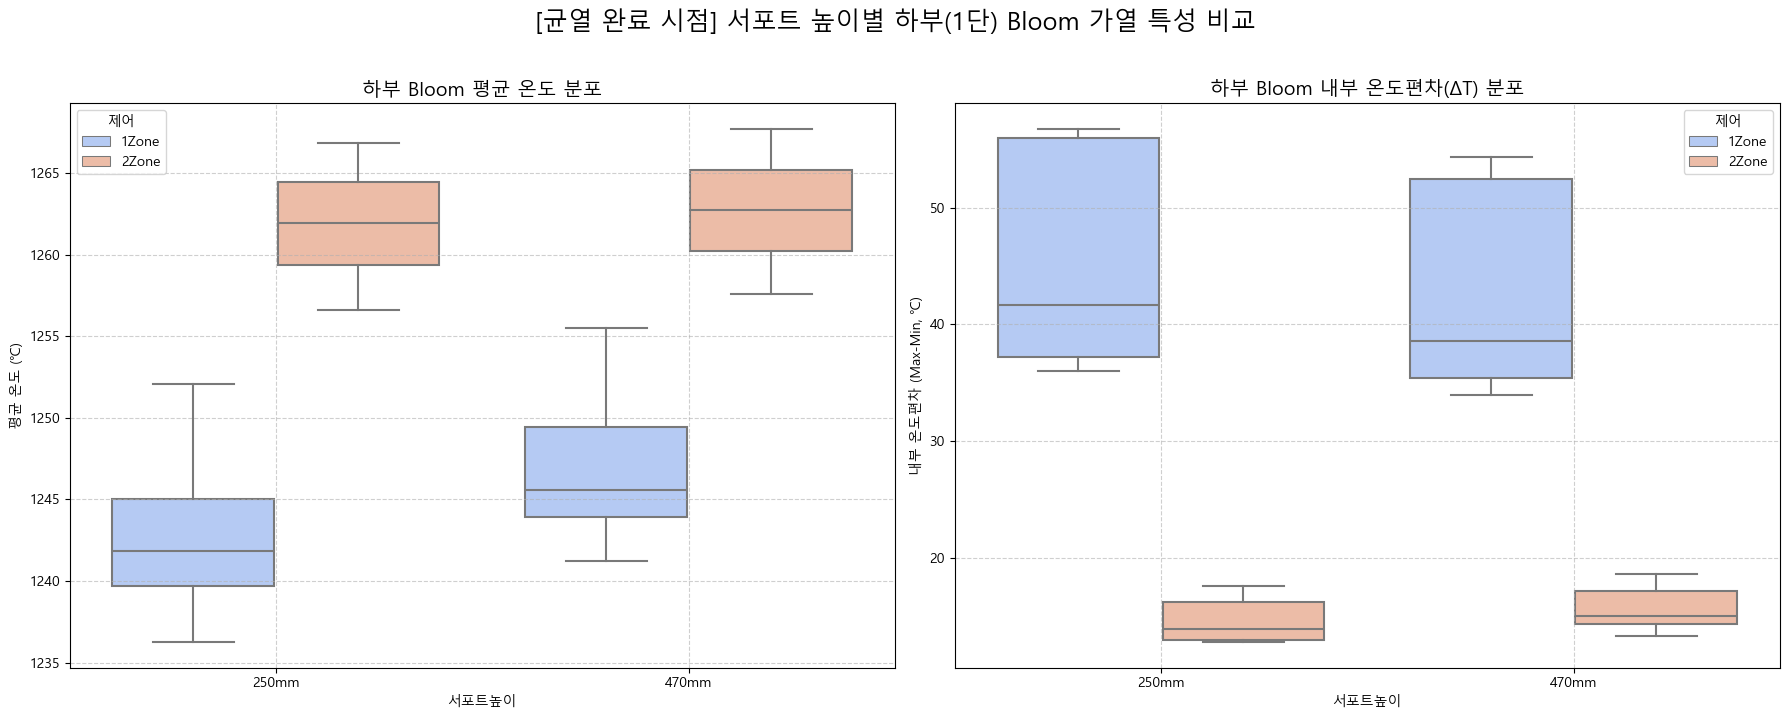

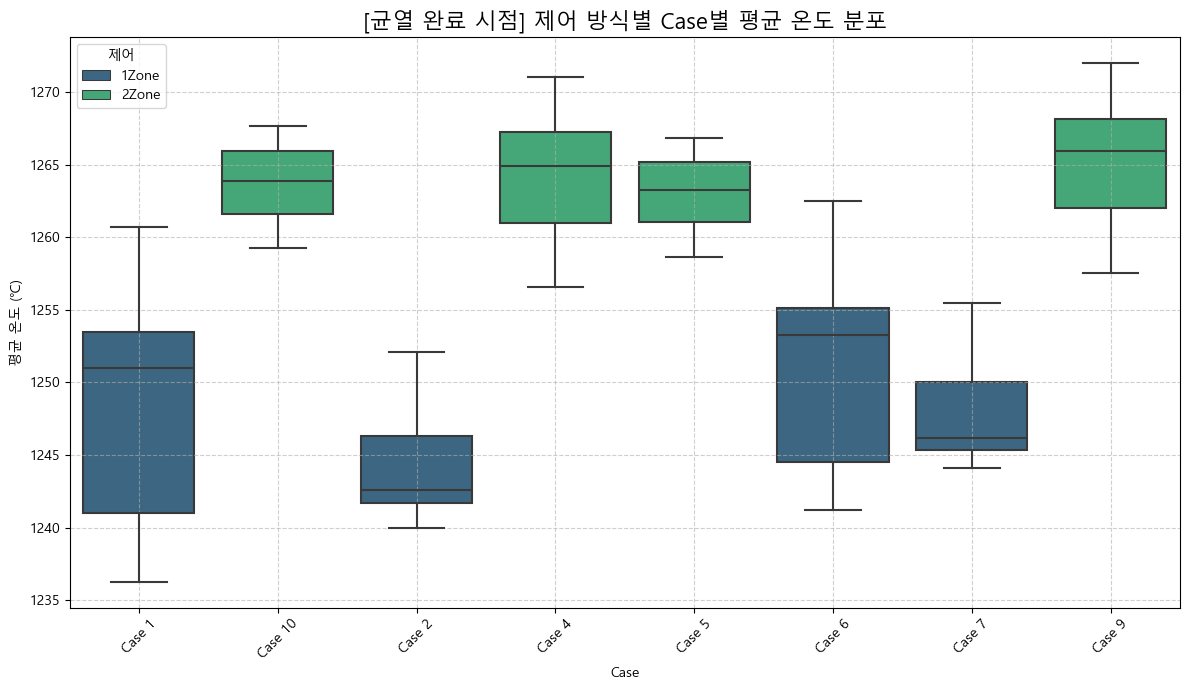


[참고] 케이스별 상세 시각화

--- [그래프 생성] Case 1, 4hr 균열 시점 ---


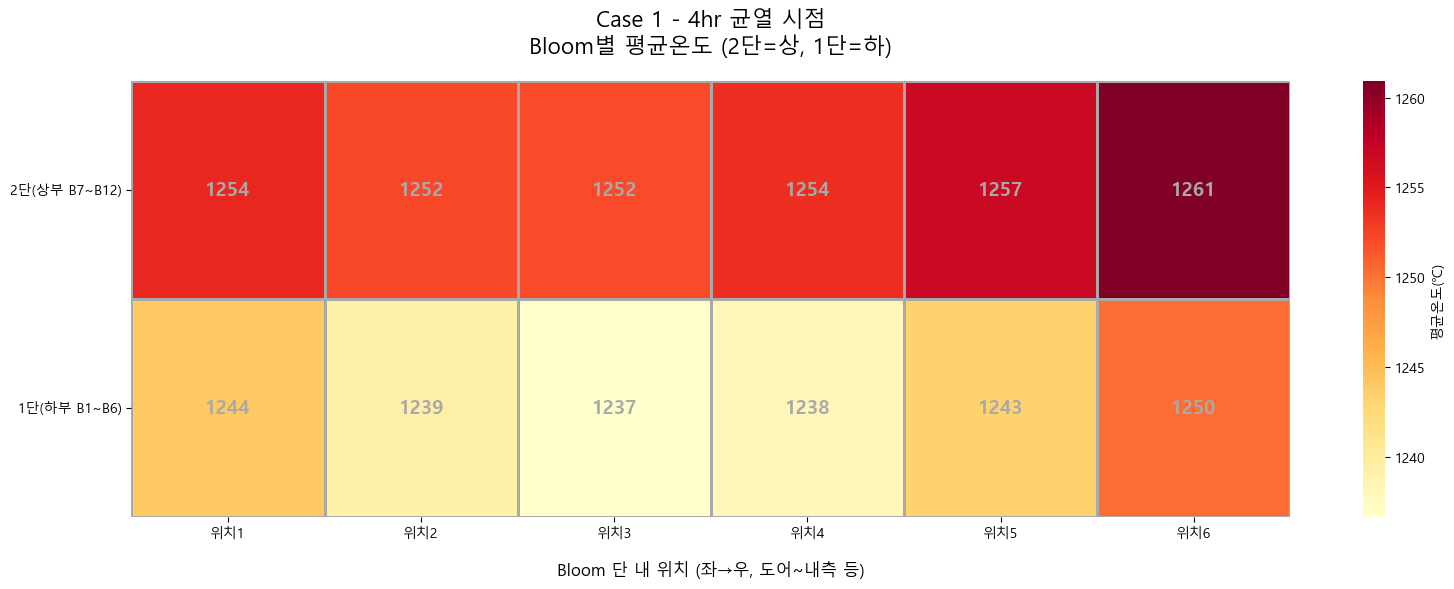

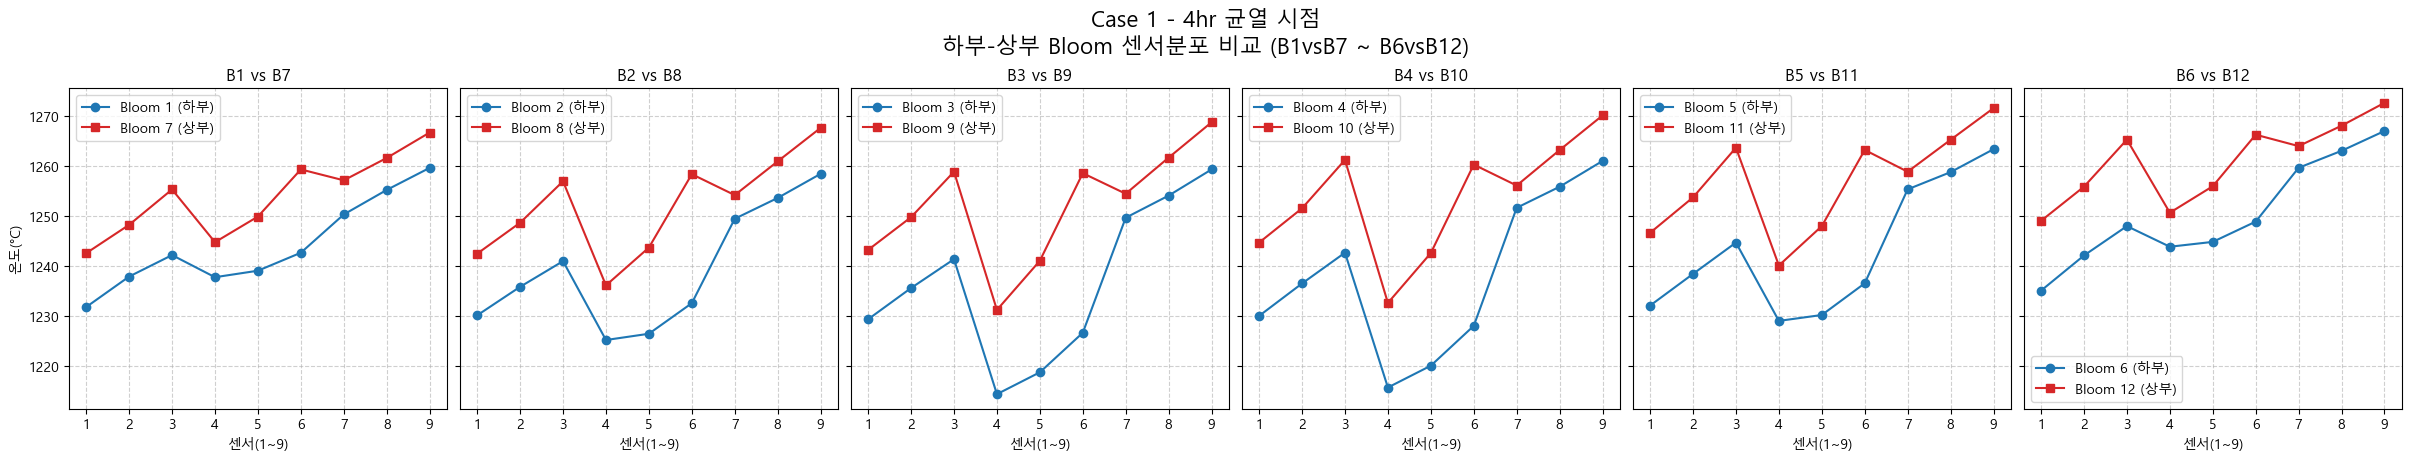


--- [그래프 생성] Case 1, 균열 완료 시점 ---


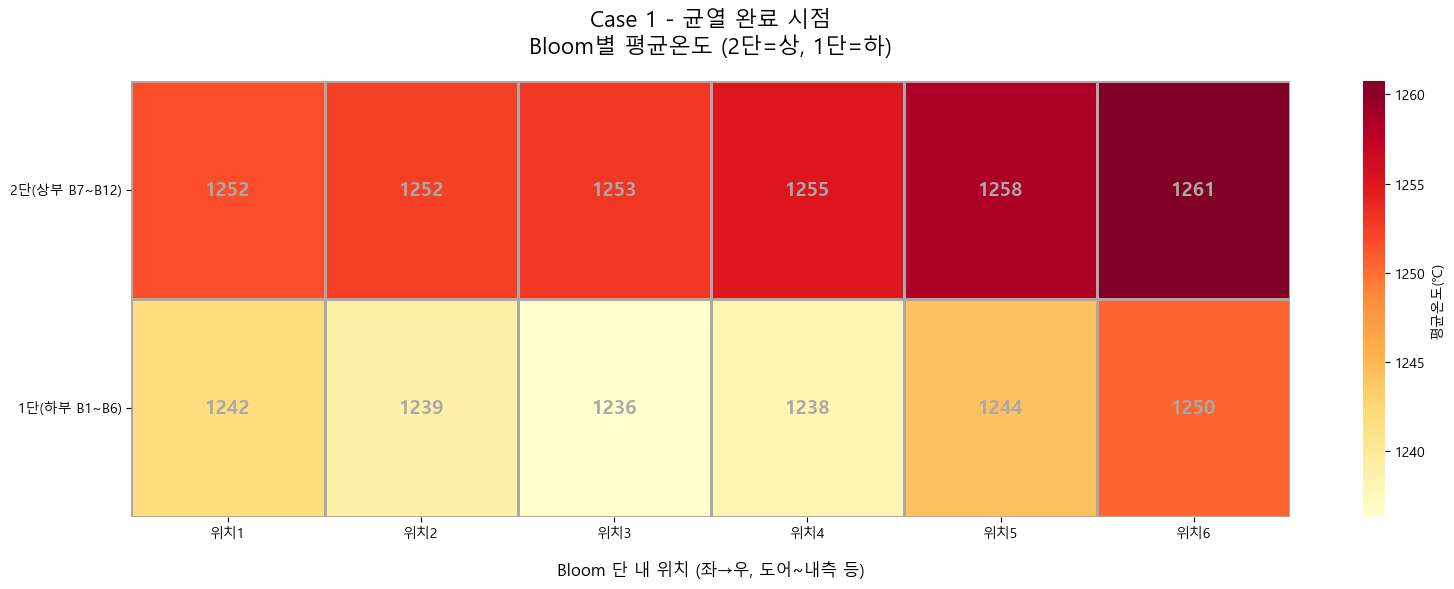

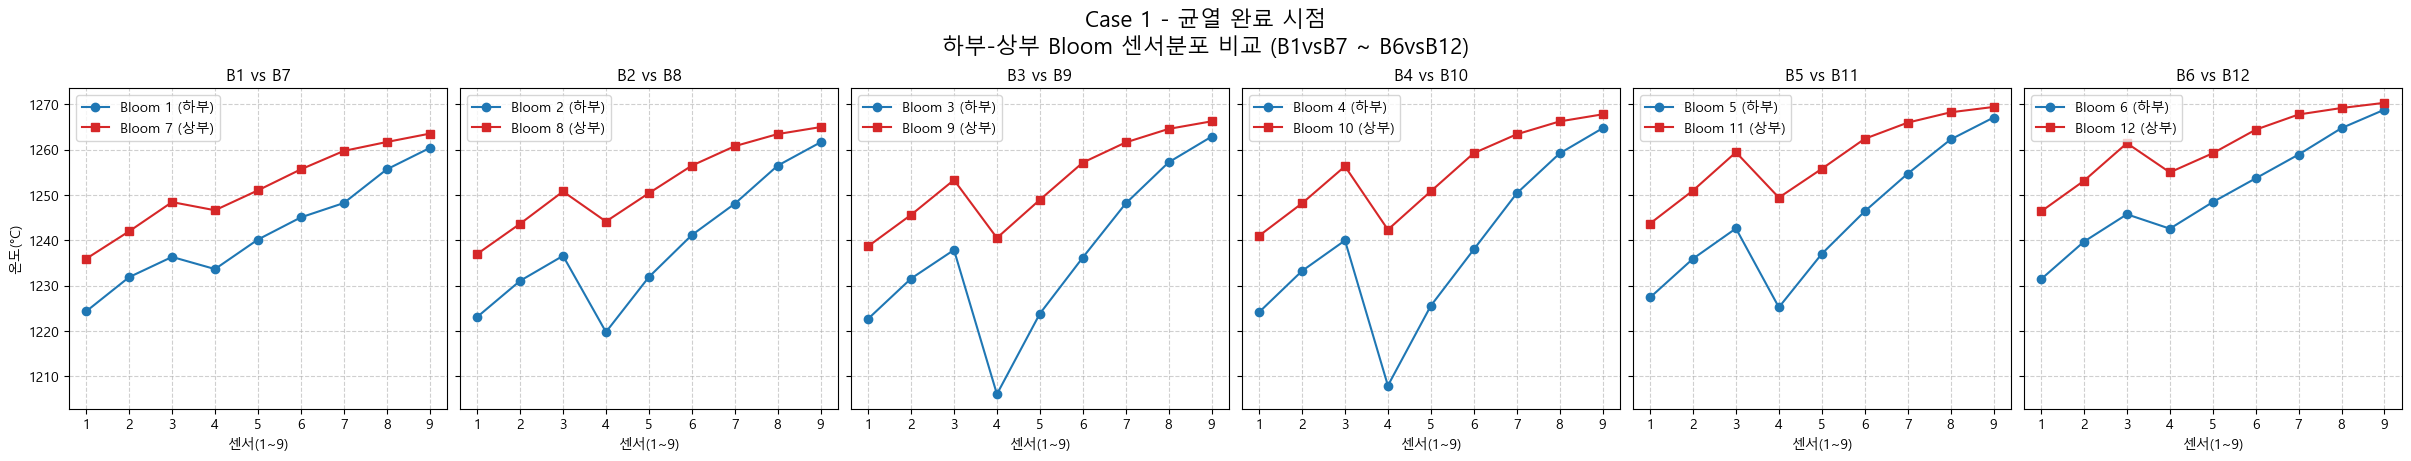


--- [그래프 생성] Case 2, 균열 완료 시점 ---


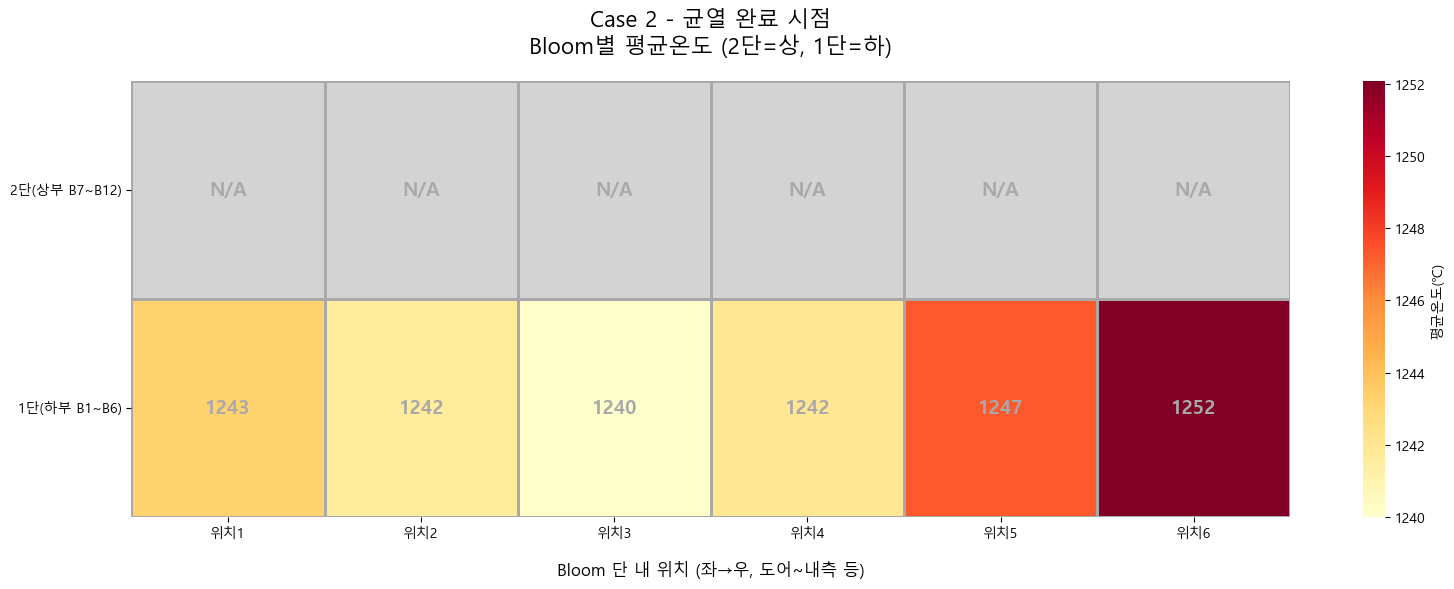

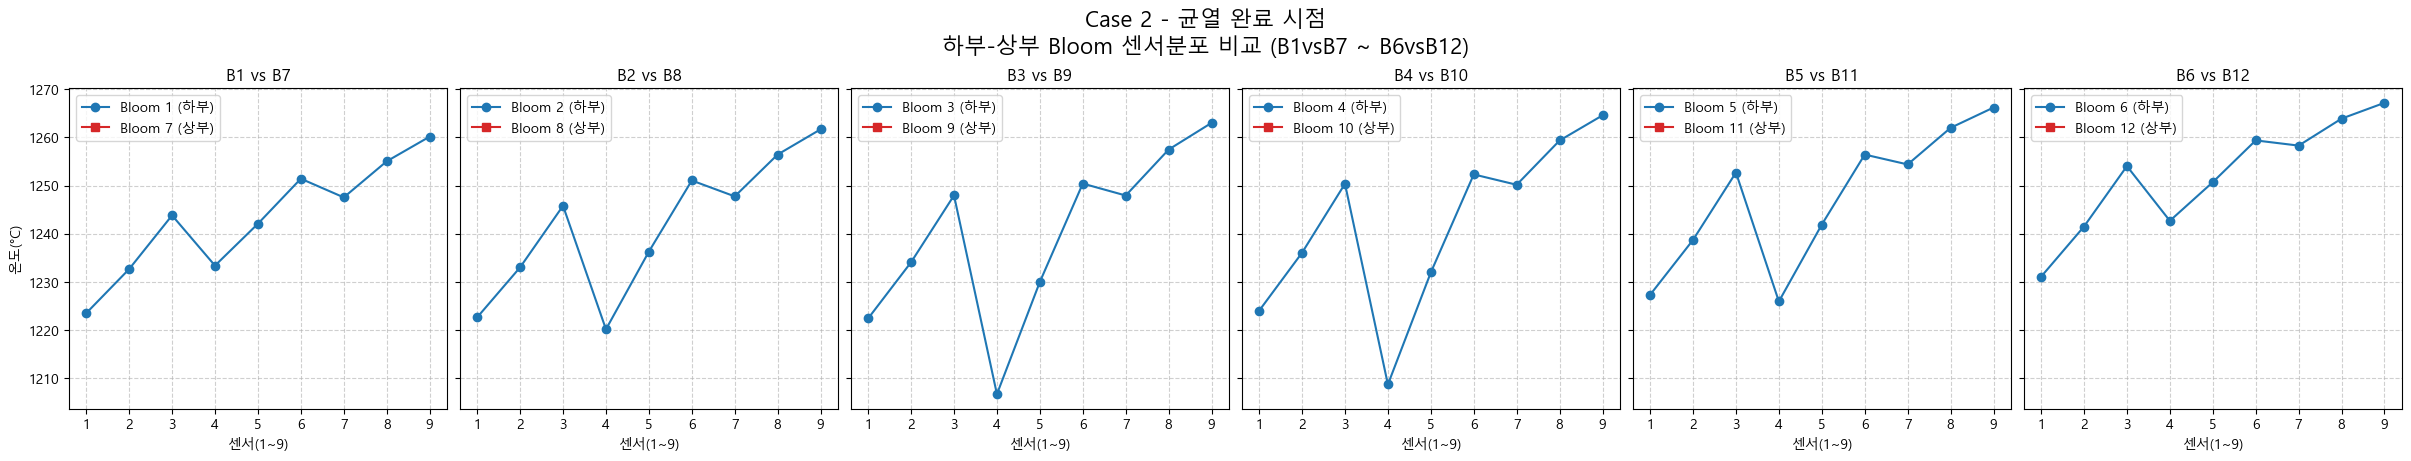


--- [그래프 생성] Case 3, 4hr 균열 시점 ---


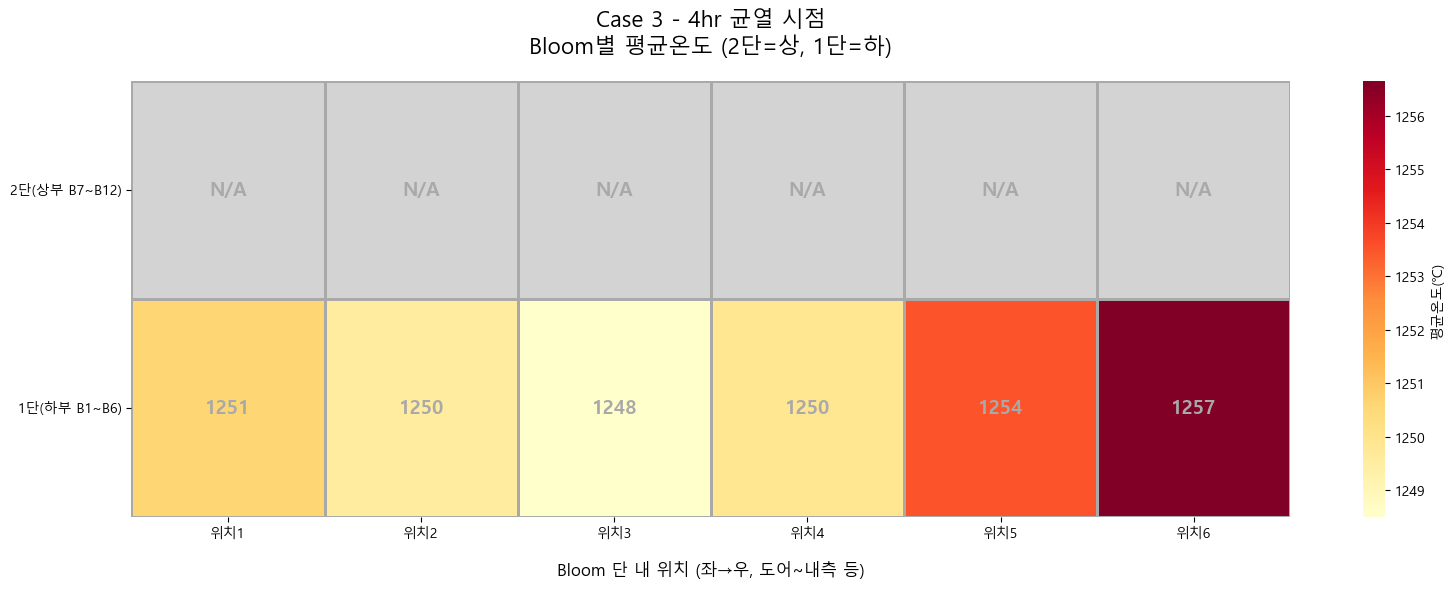

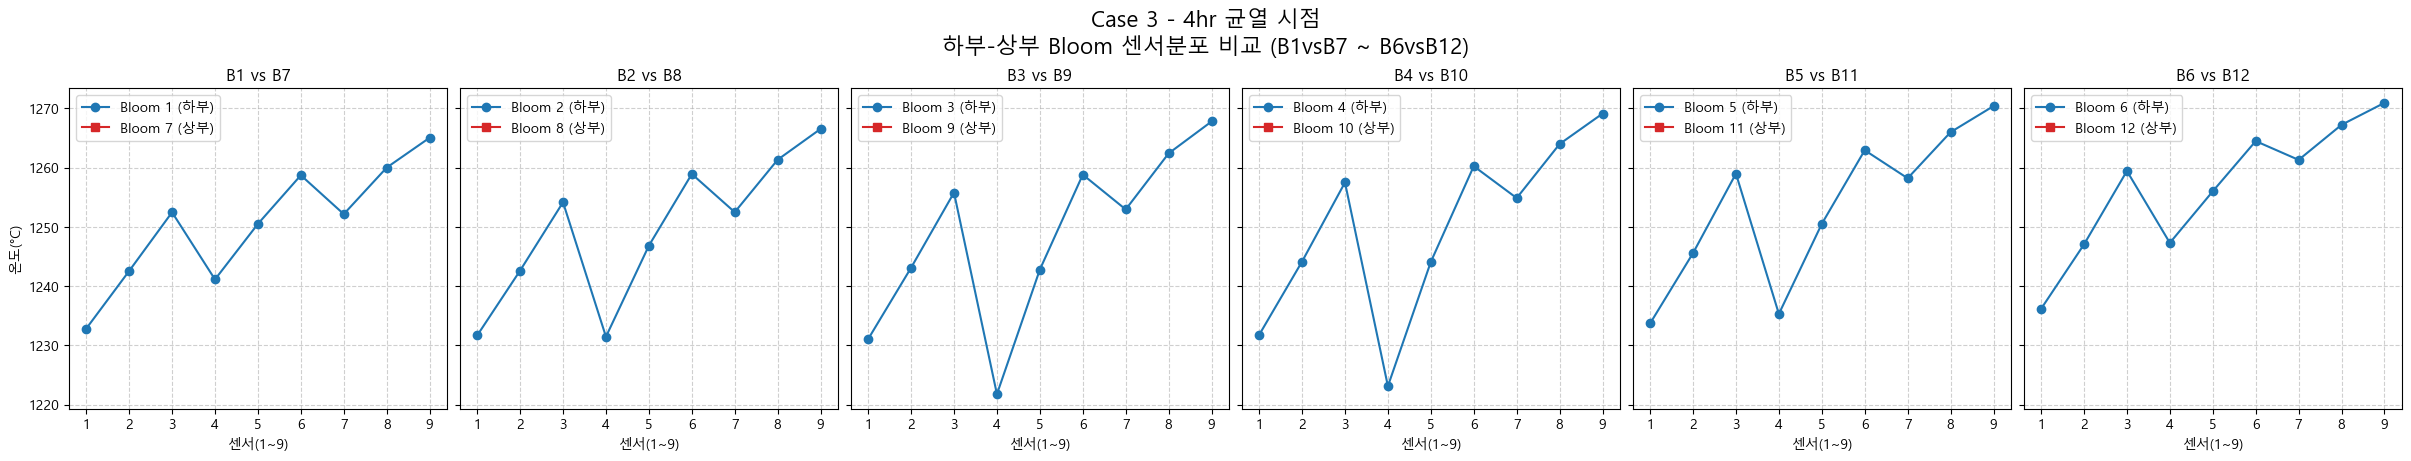


--- [그래프 생성] Case 3, 균열 완료 시점 ---


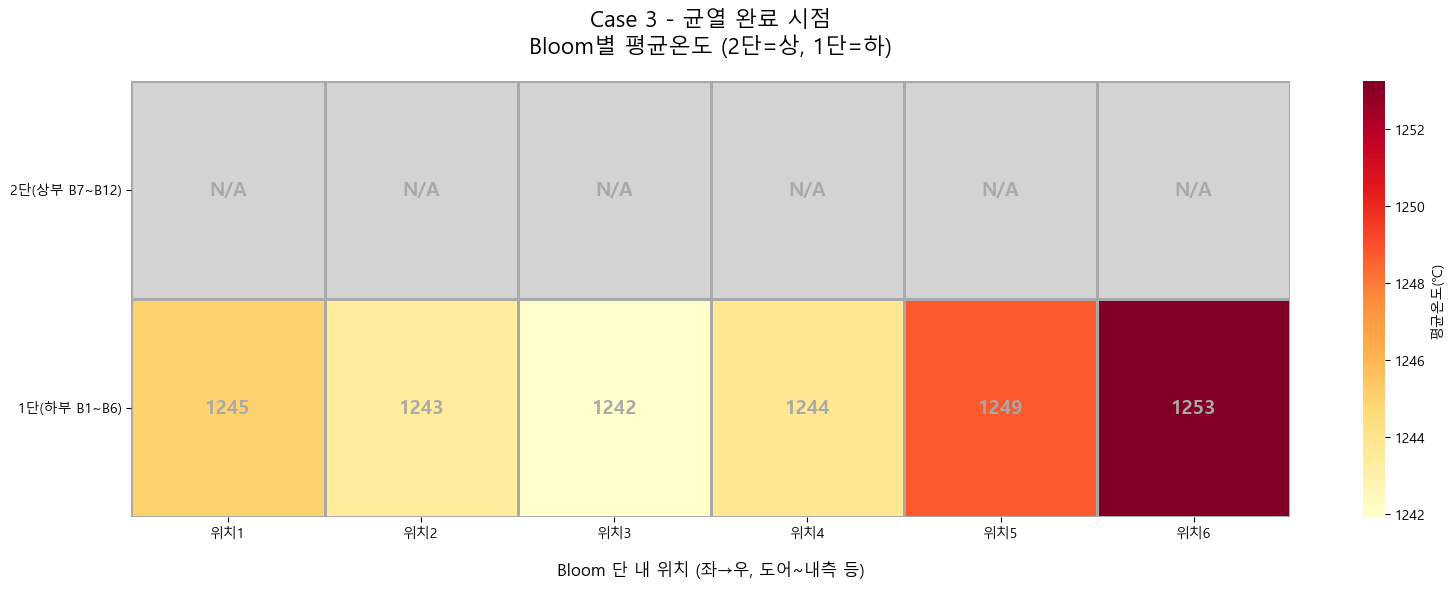

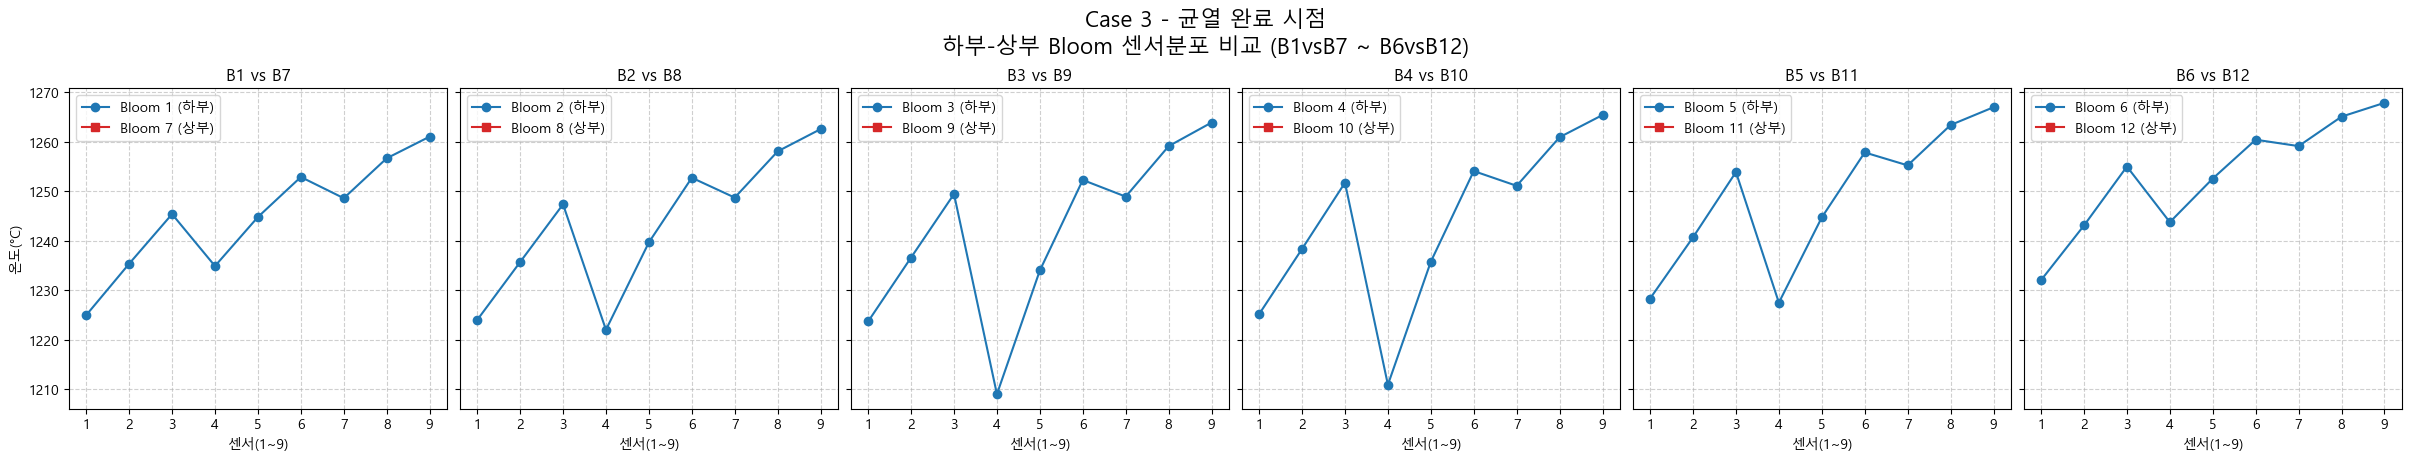


--- [그래프 생성] Case 4, 4hr 균열 시점 ---


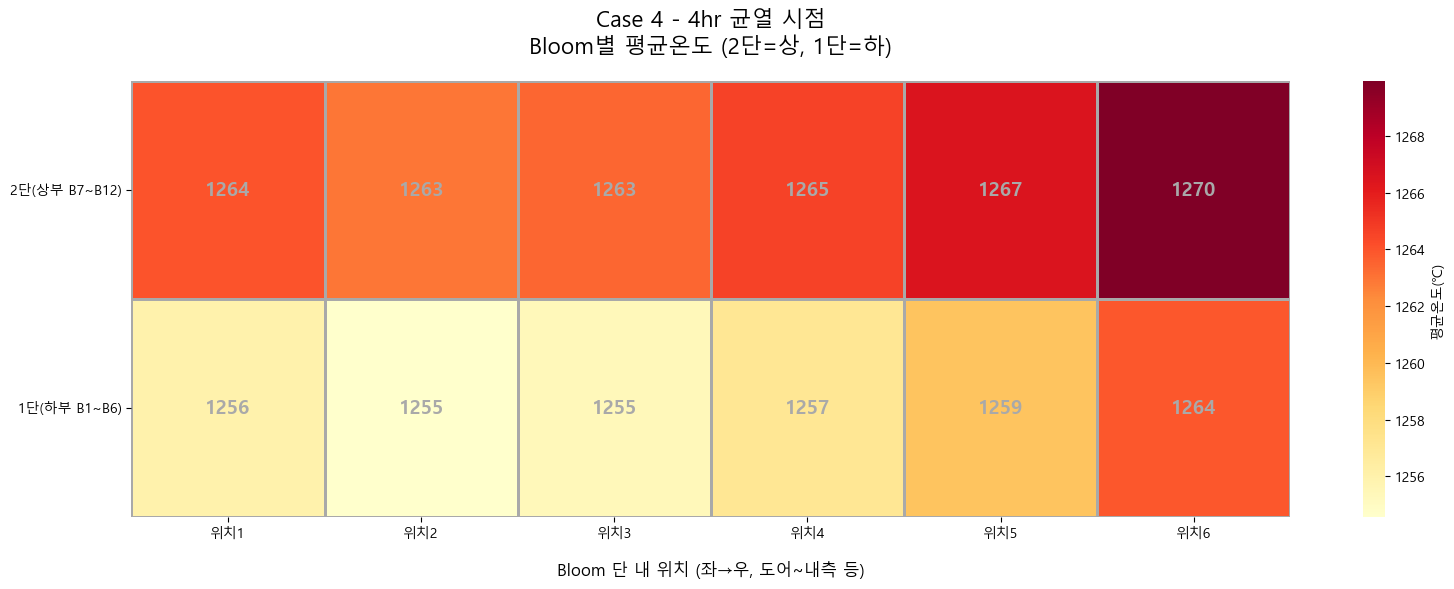

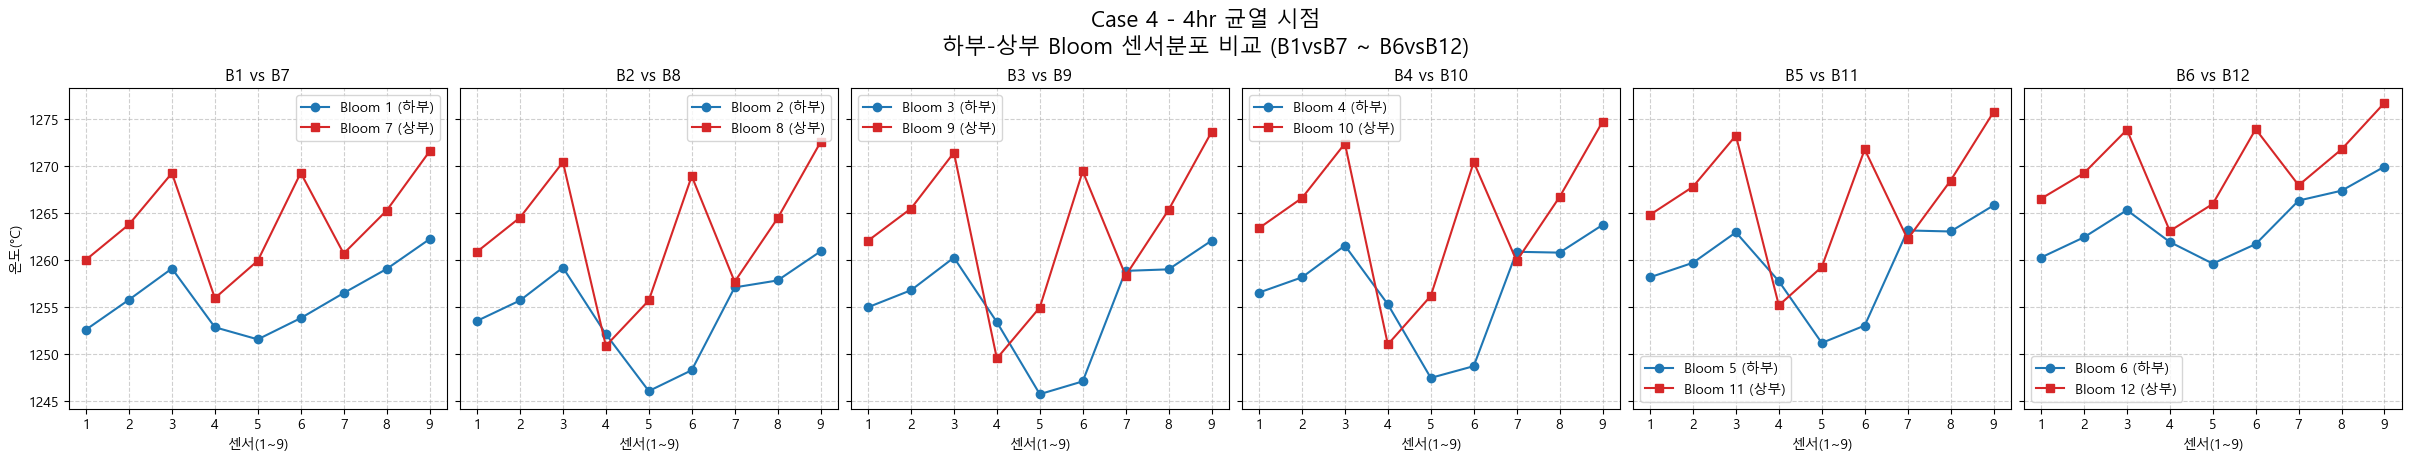


--- [그래프 생성] Case 4, 균열 완료 시점 ---


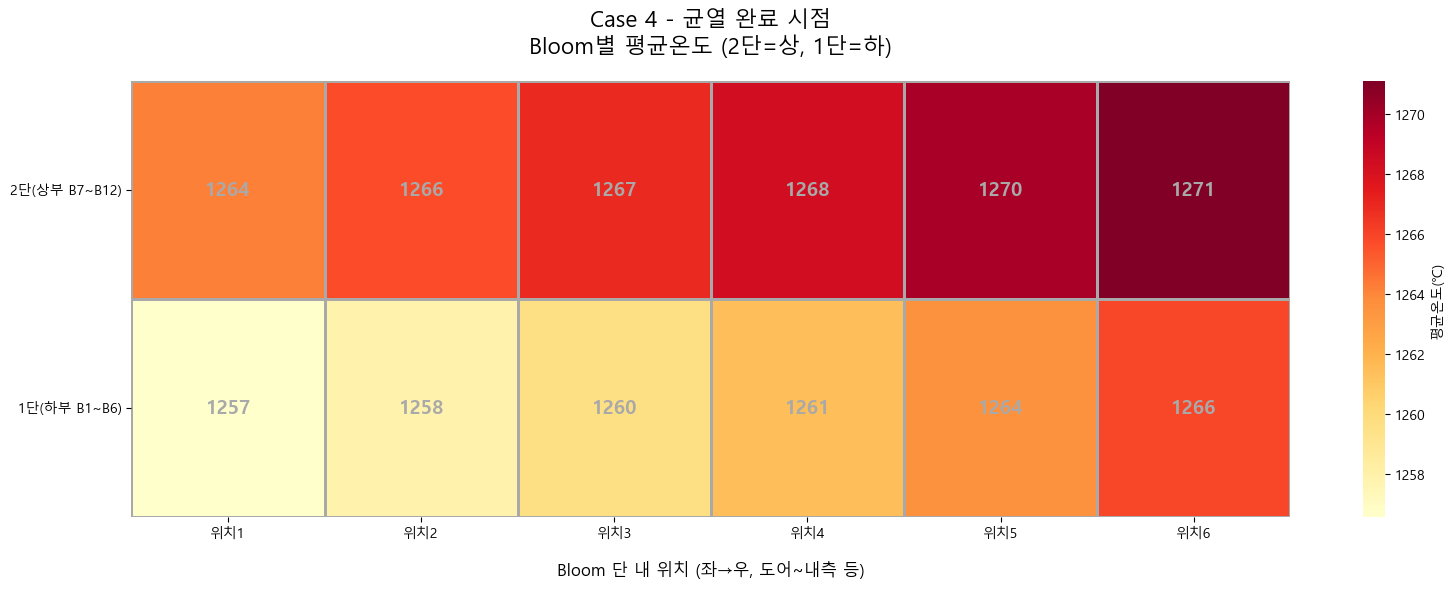

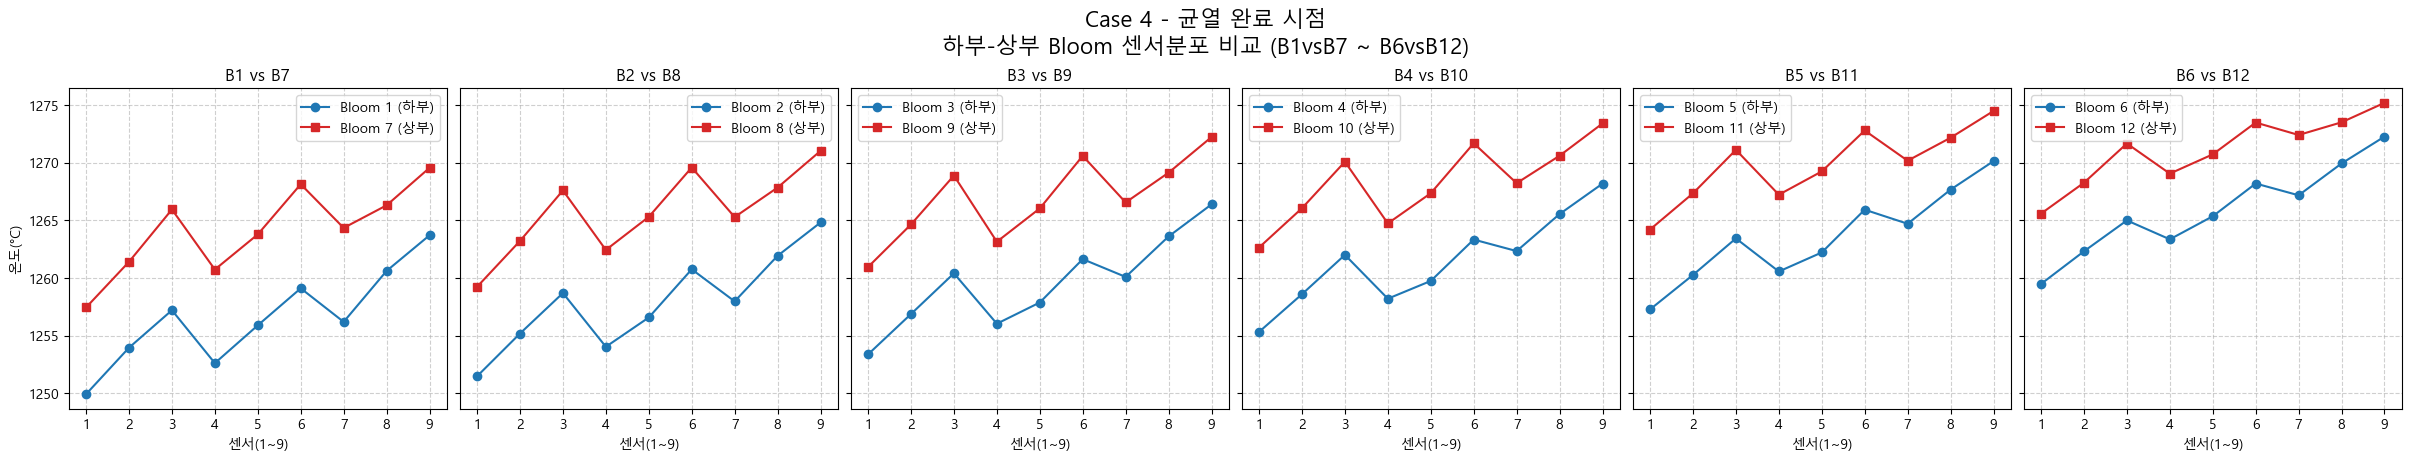


--- [그래프 생성] Case 5, 균열 완료 시점 ---


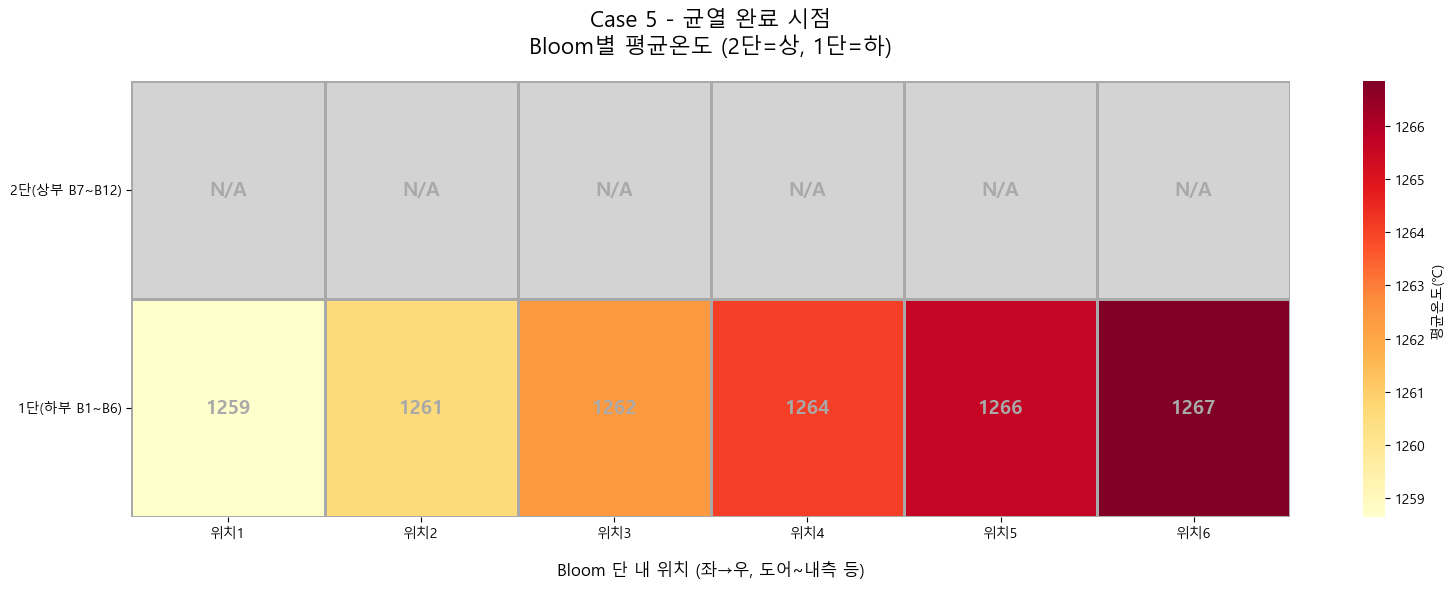

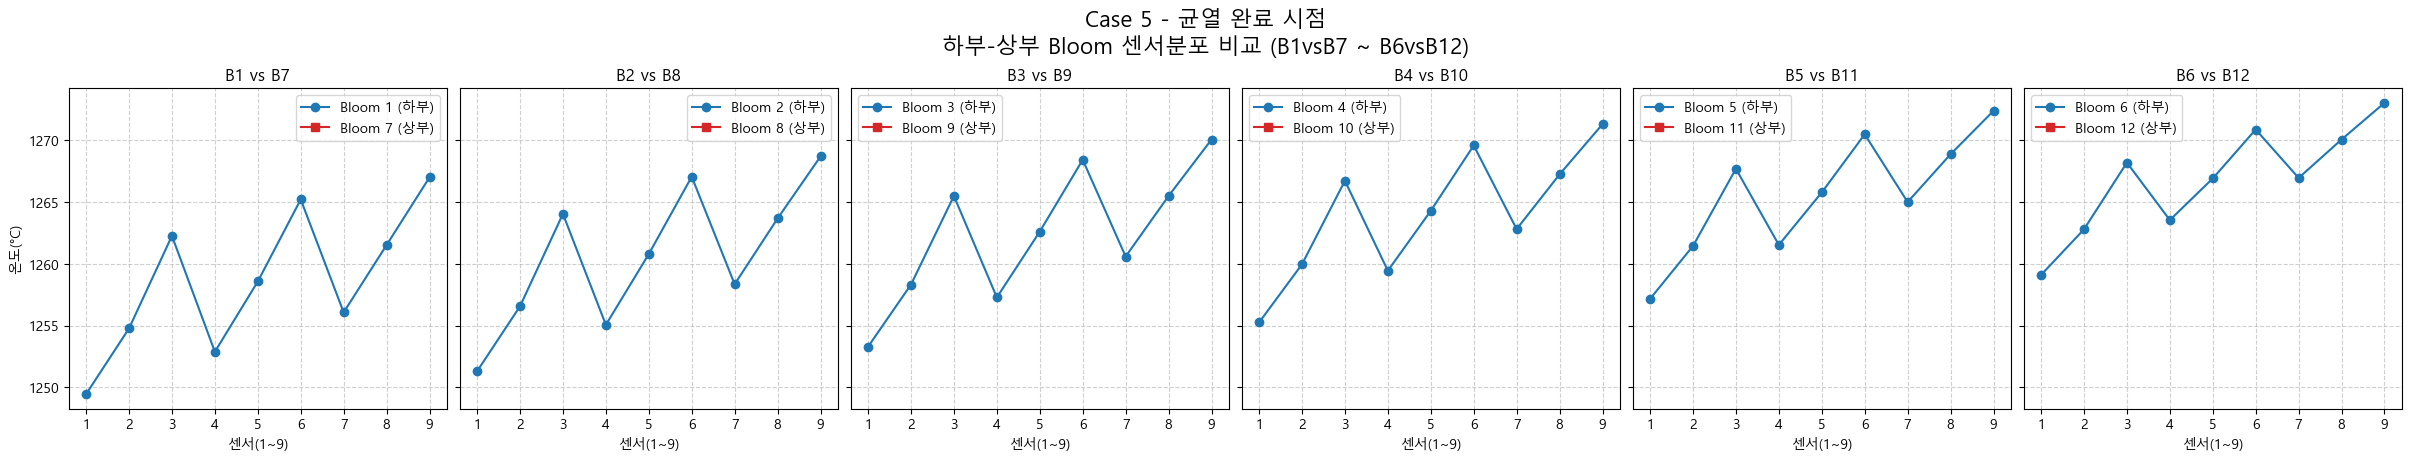


--- [그래프 생성] Case 6, 4hr 균열 시점 ---


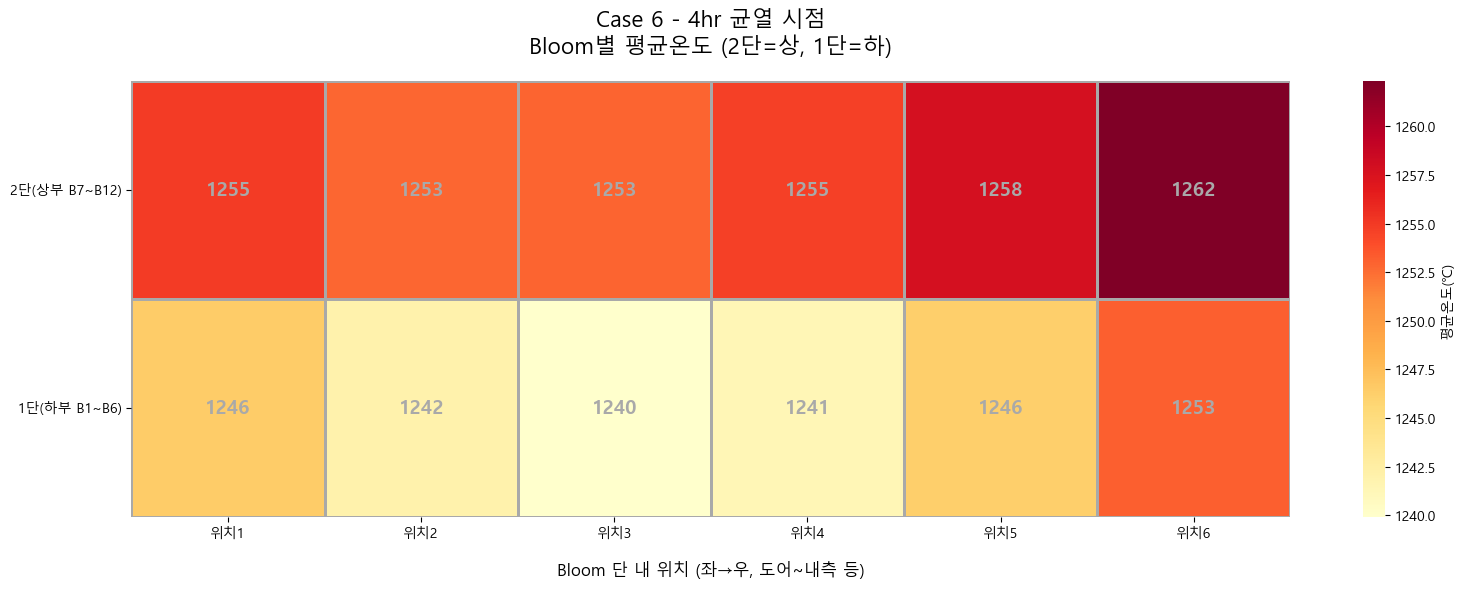

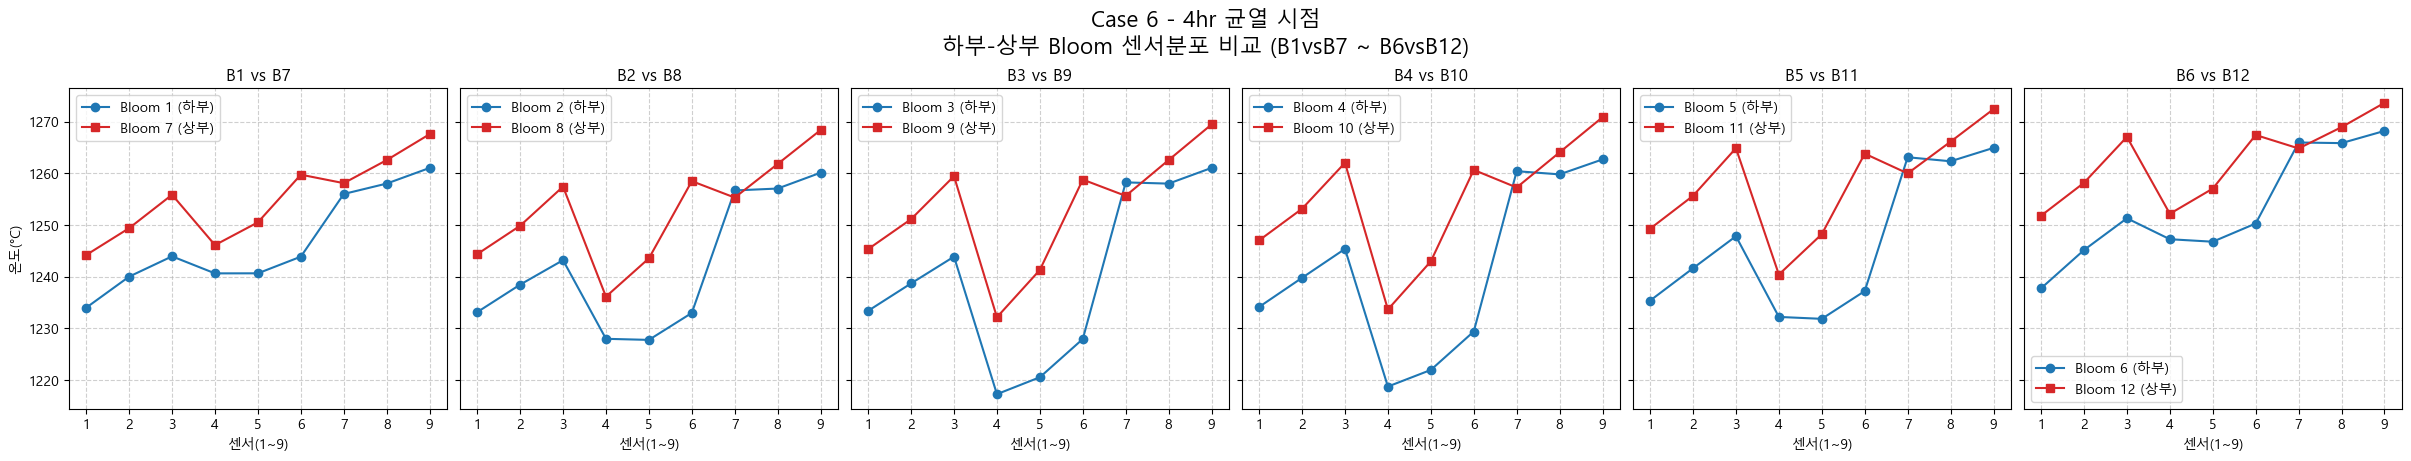


--- [그래프 생성] Case 6, 균열 완료 시점 ---


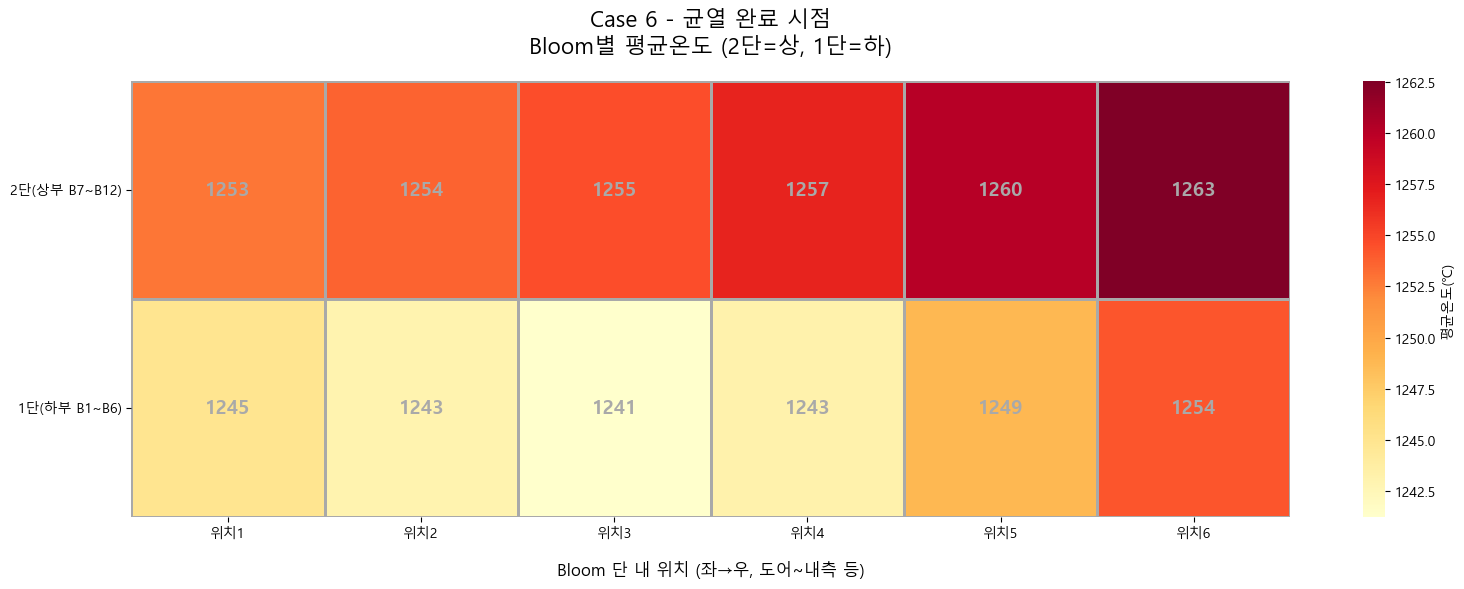

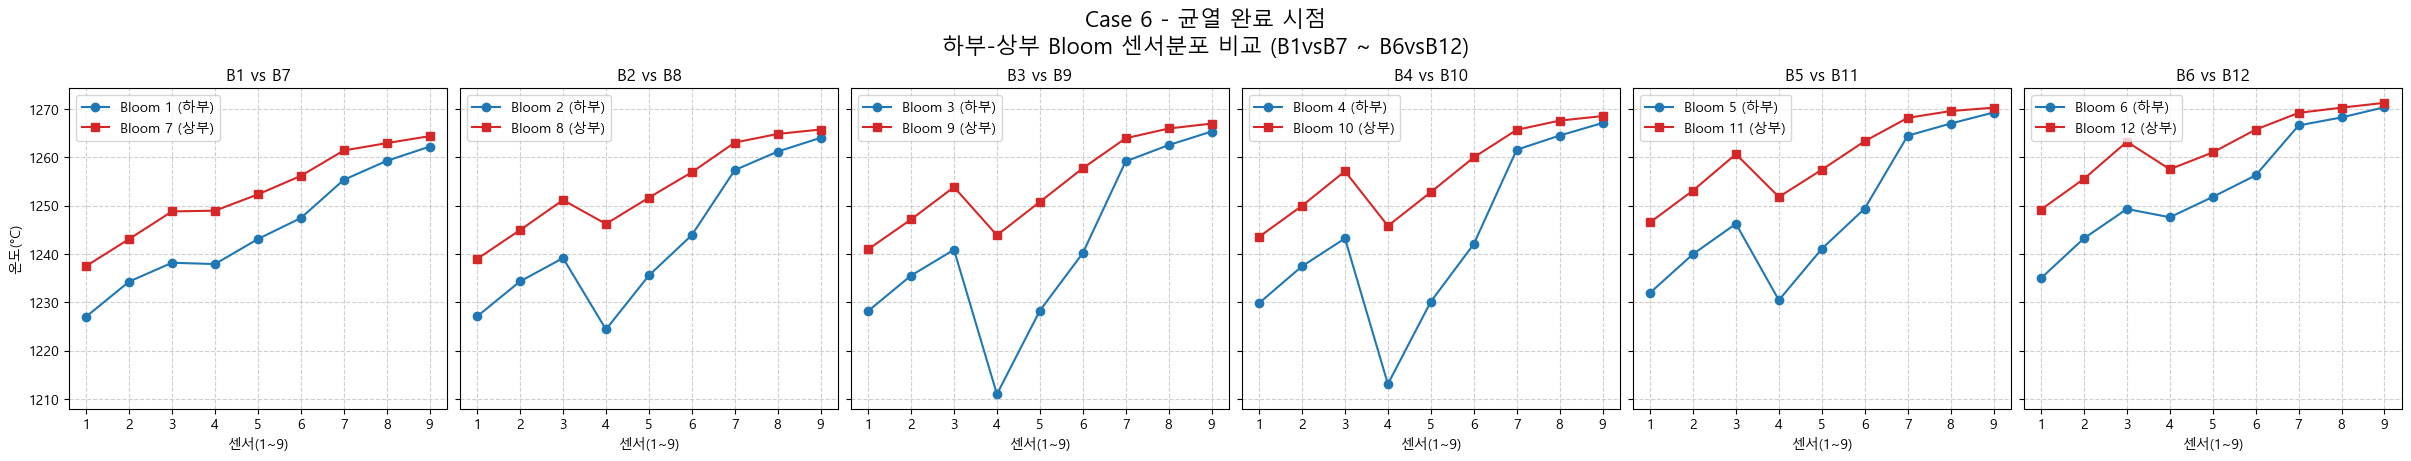


--- [그래프 생성] Case 7, 균열 완료 시점 ---


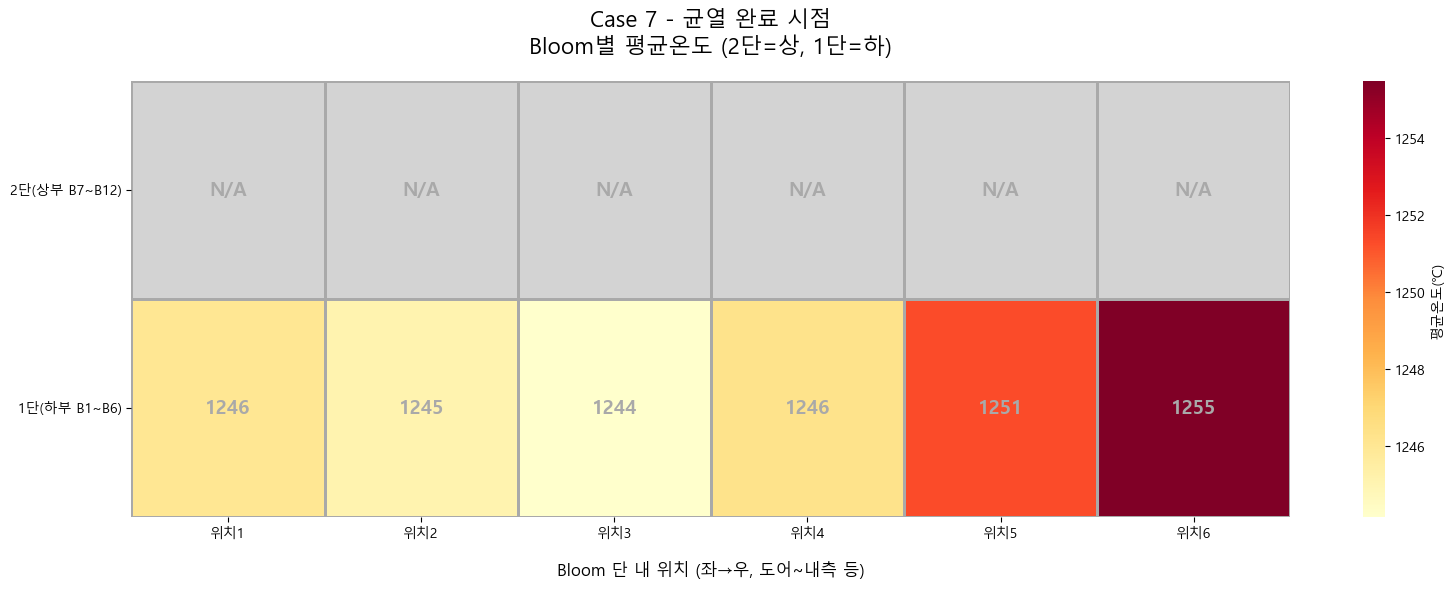

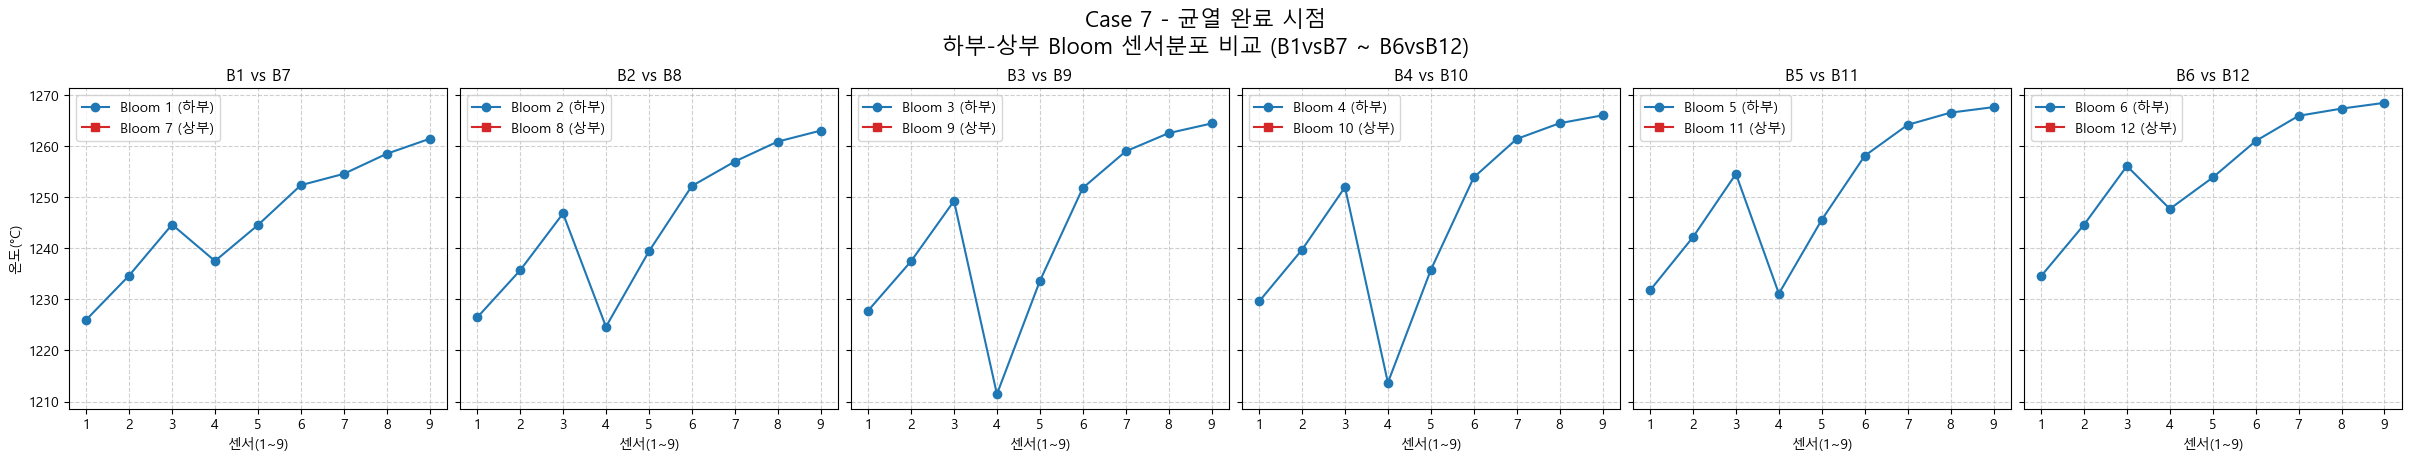


--- [그래프 생성] Case 8, 4hr 균열 시점 ---


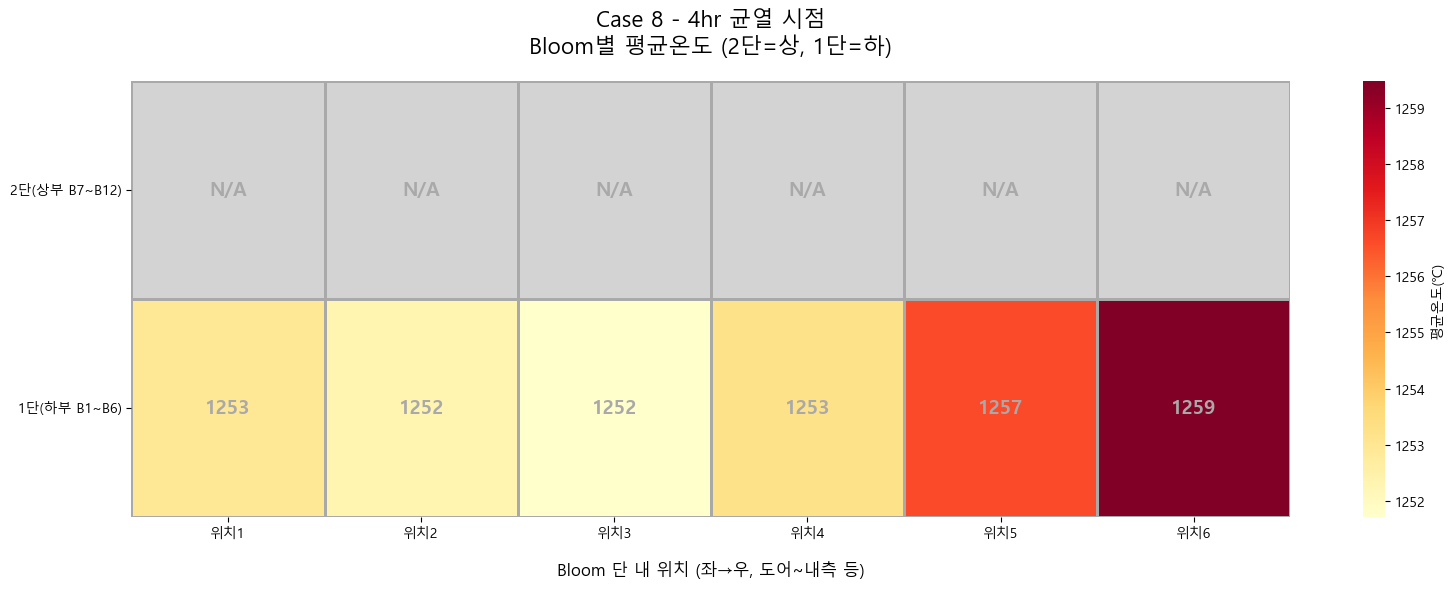

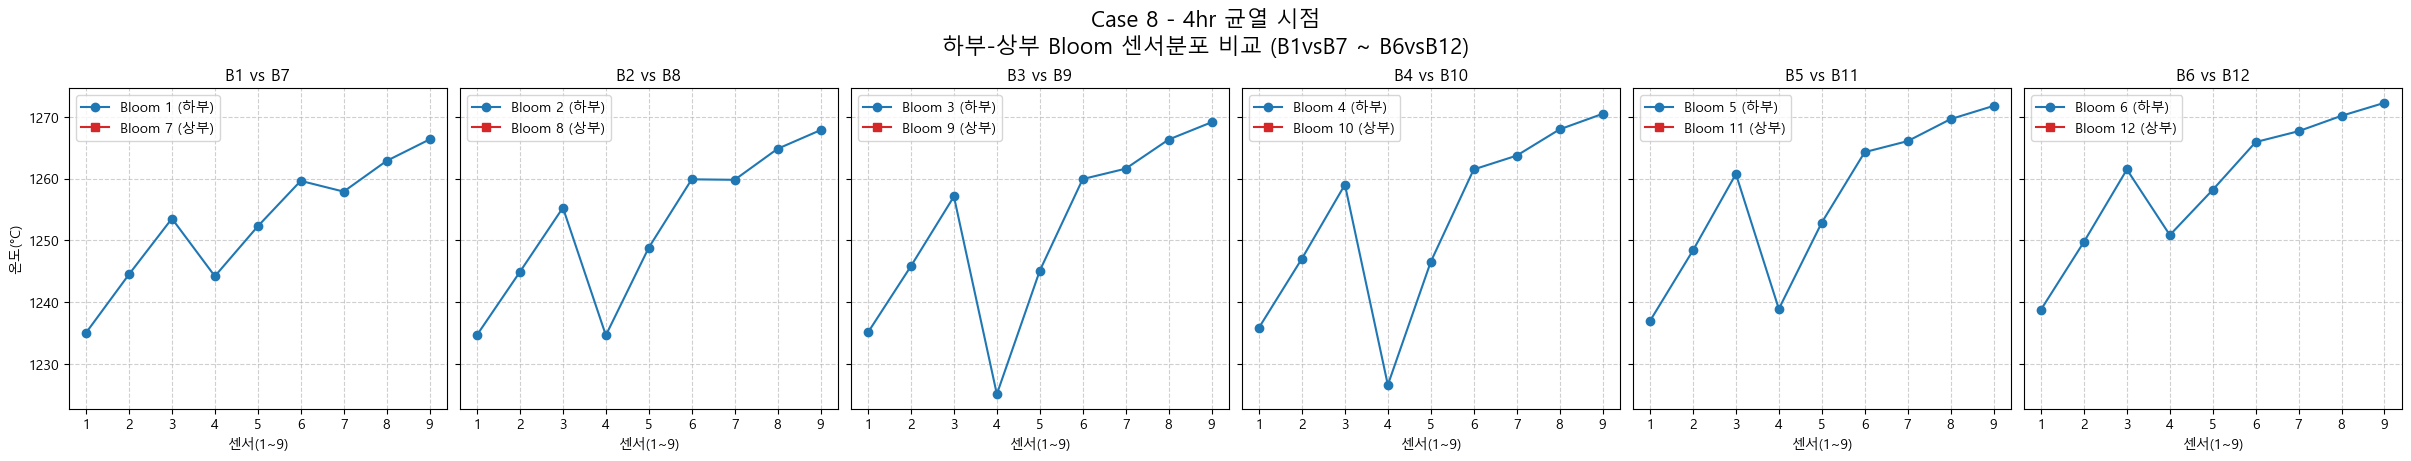


--- [그래프 생성] Case 8, 균열 완료 시점 ---


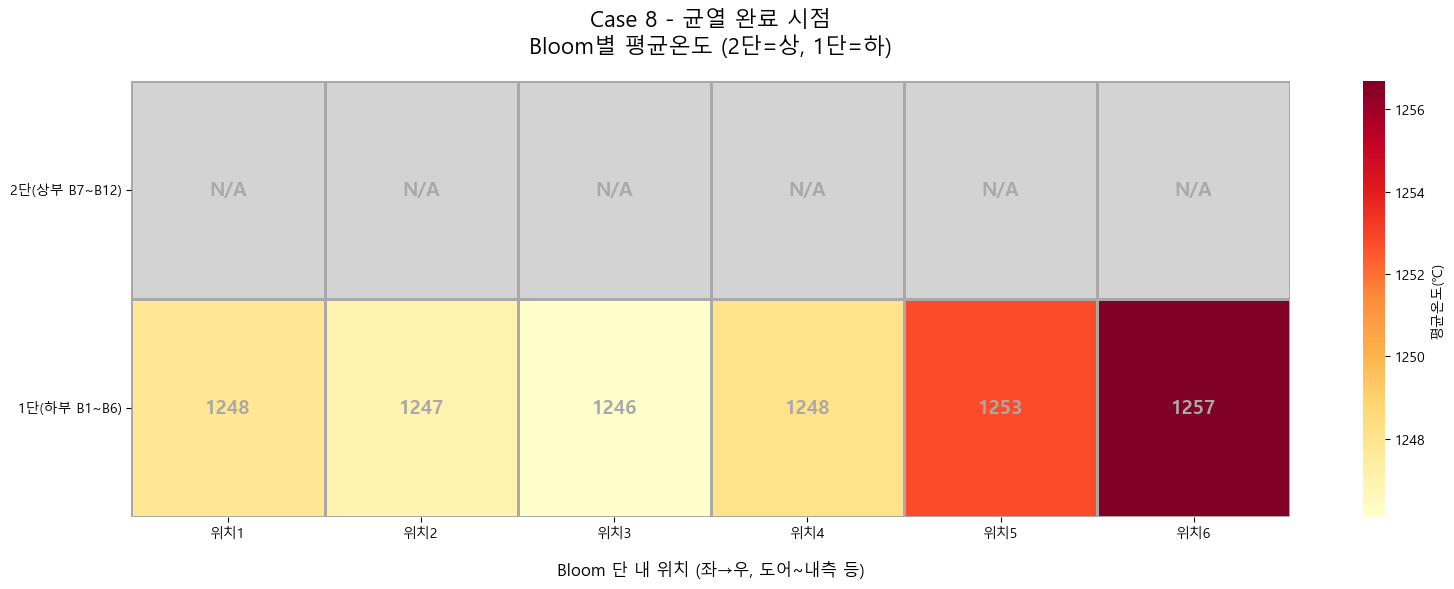

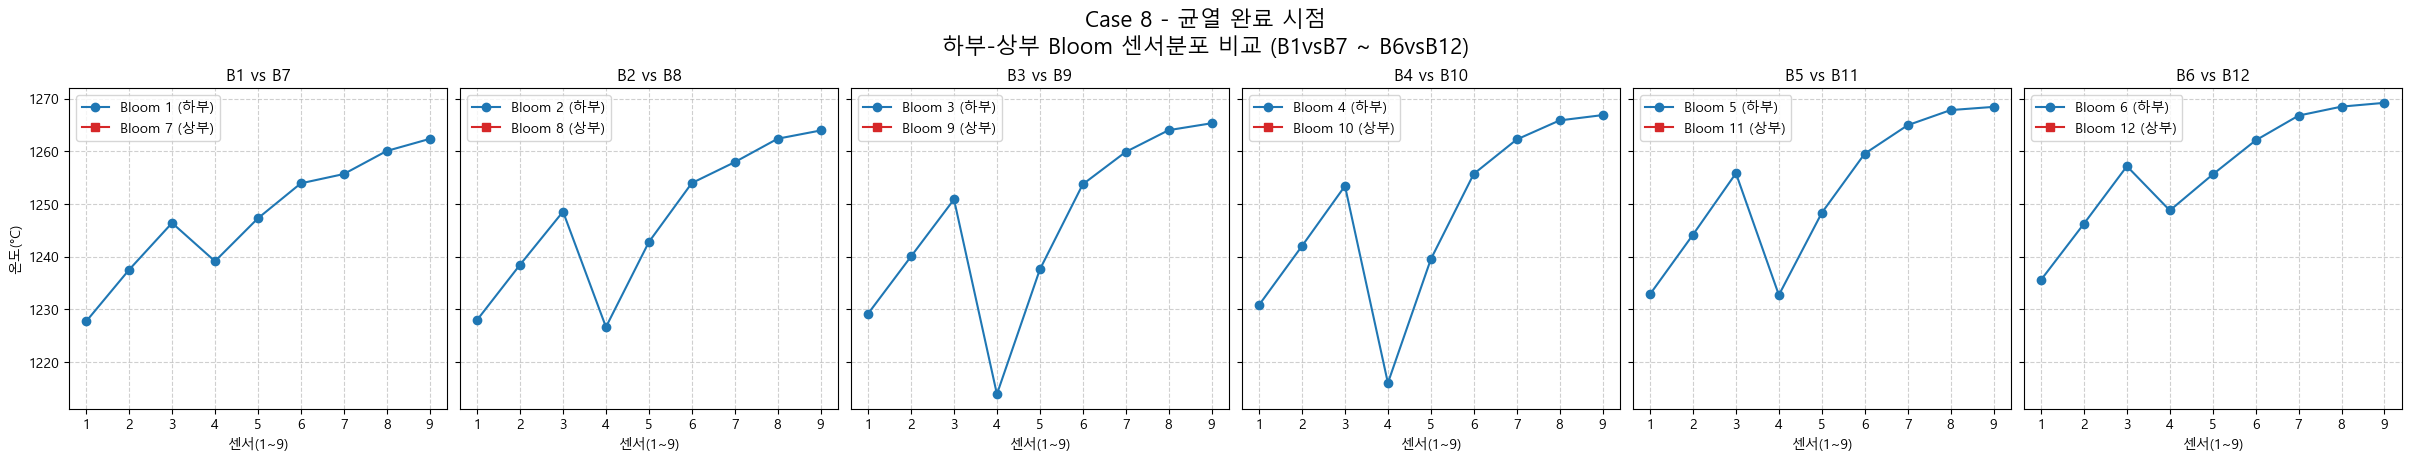


--- [그래프 생성] Case 9, 4hr 균열 시점 ---


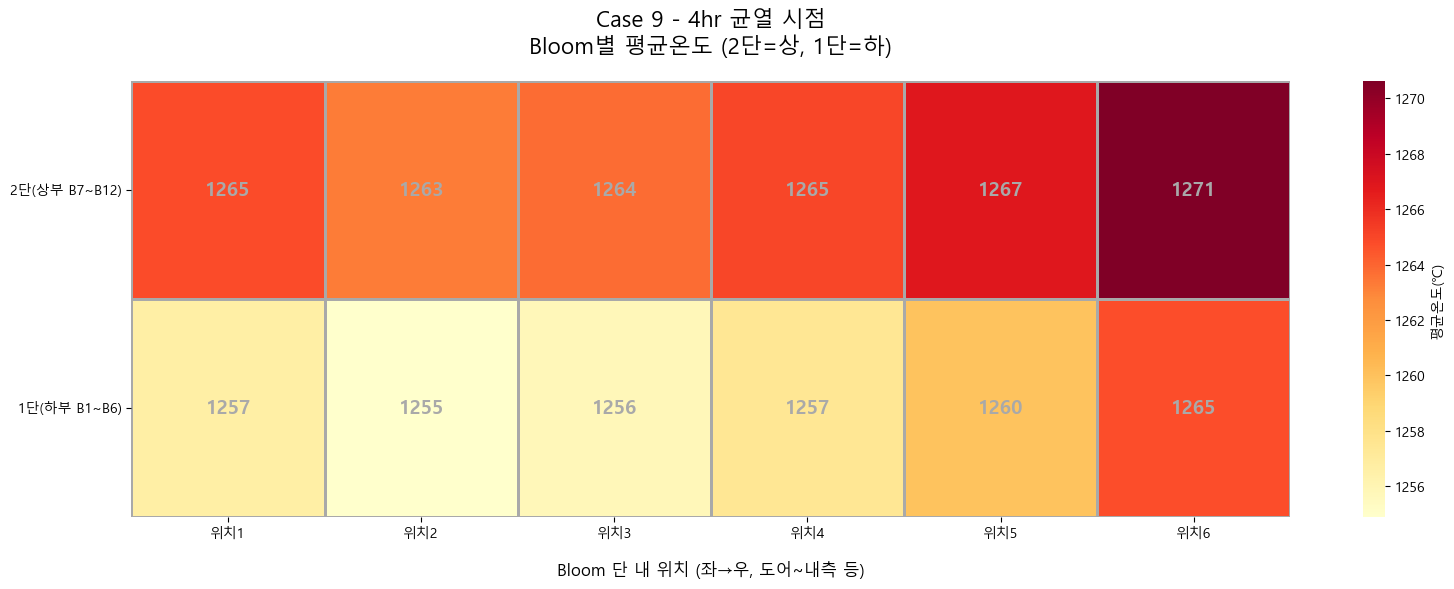

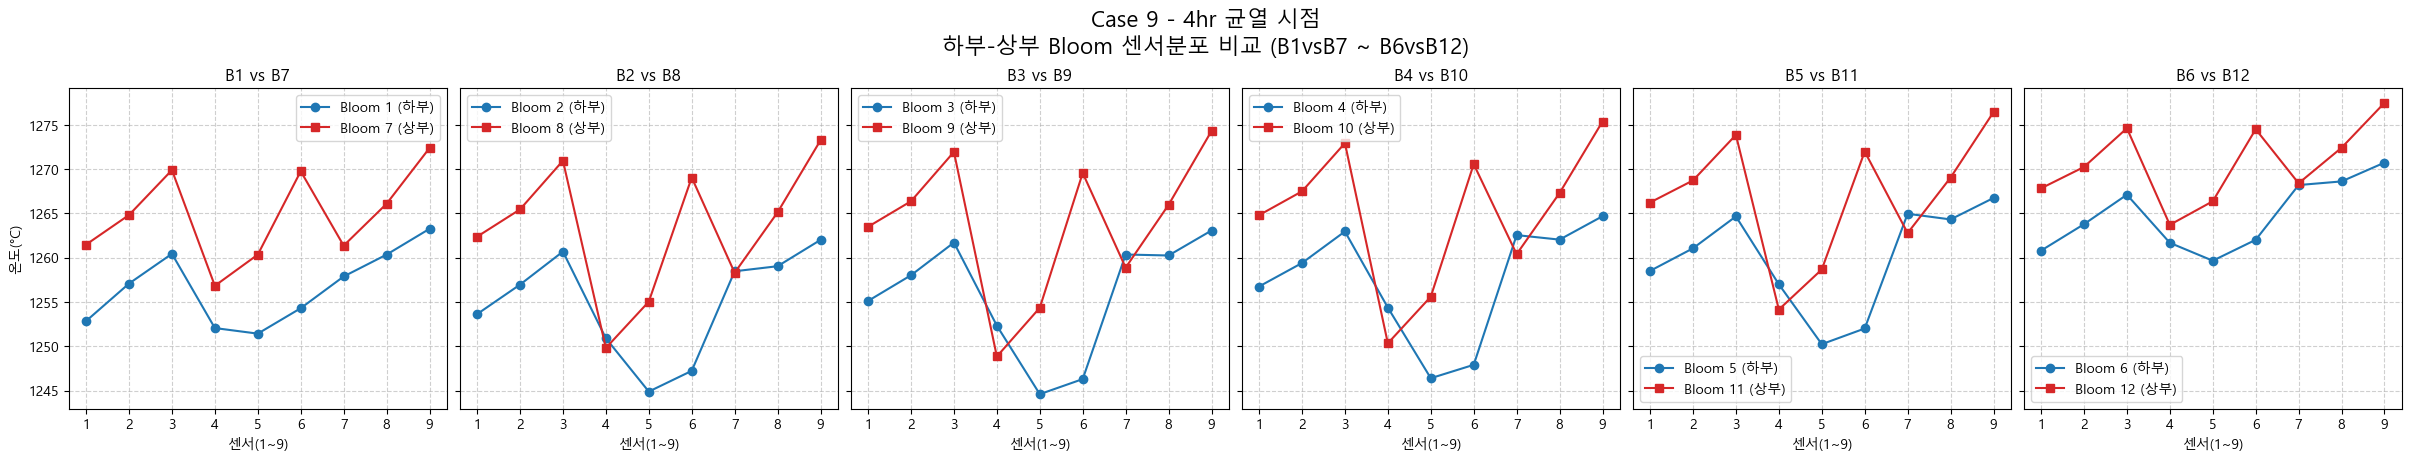


--- [그래프 생성] Case 9, 균열 완료 시점 ---


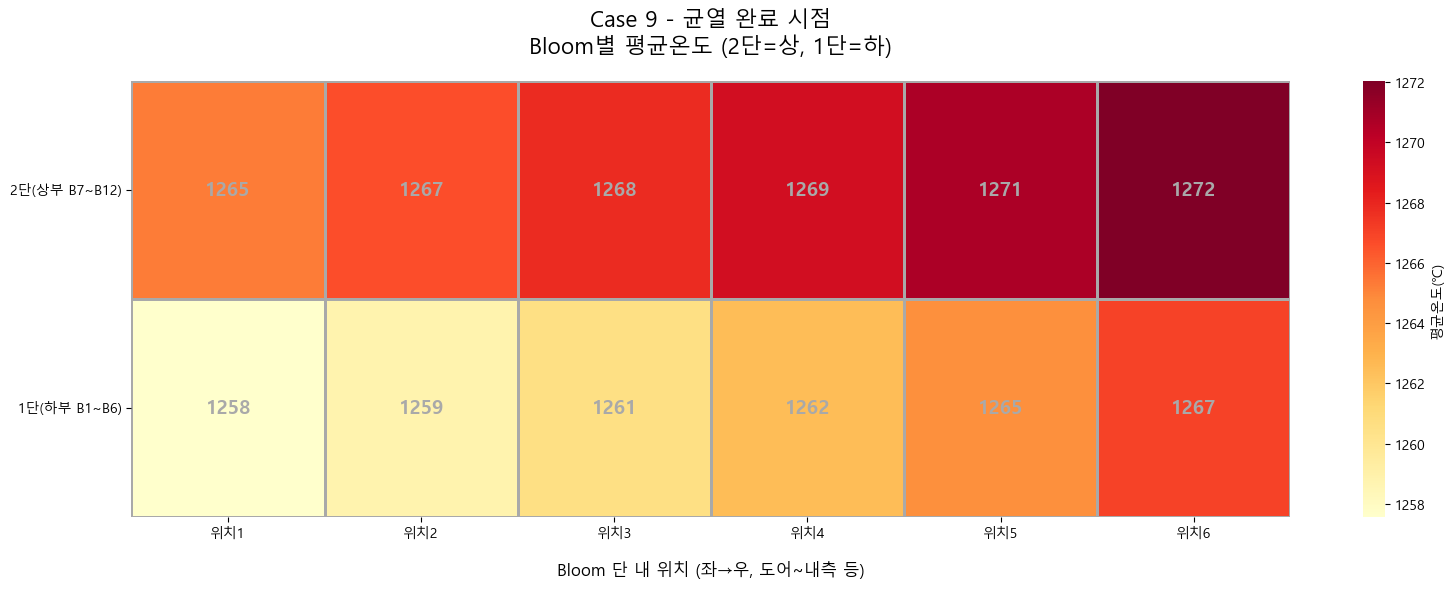

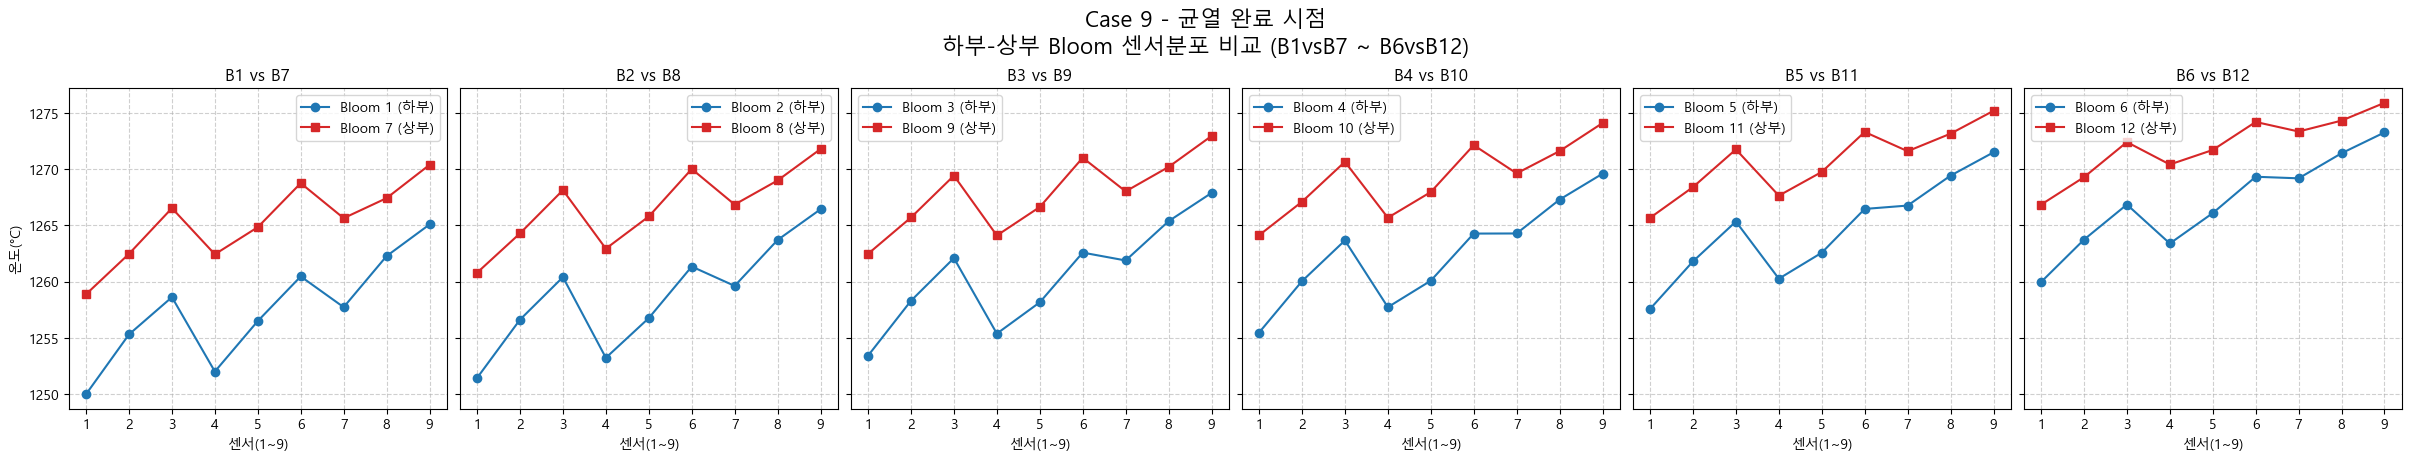


--- [그래프 생성] Case 10, 균열 완료 시점 ---


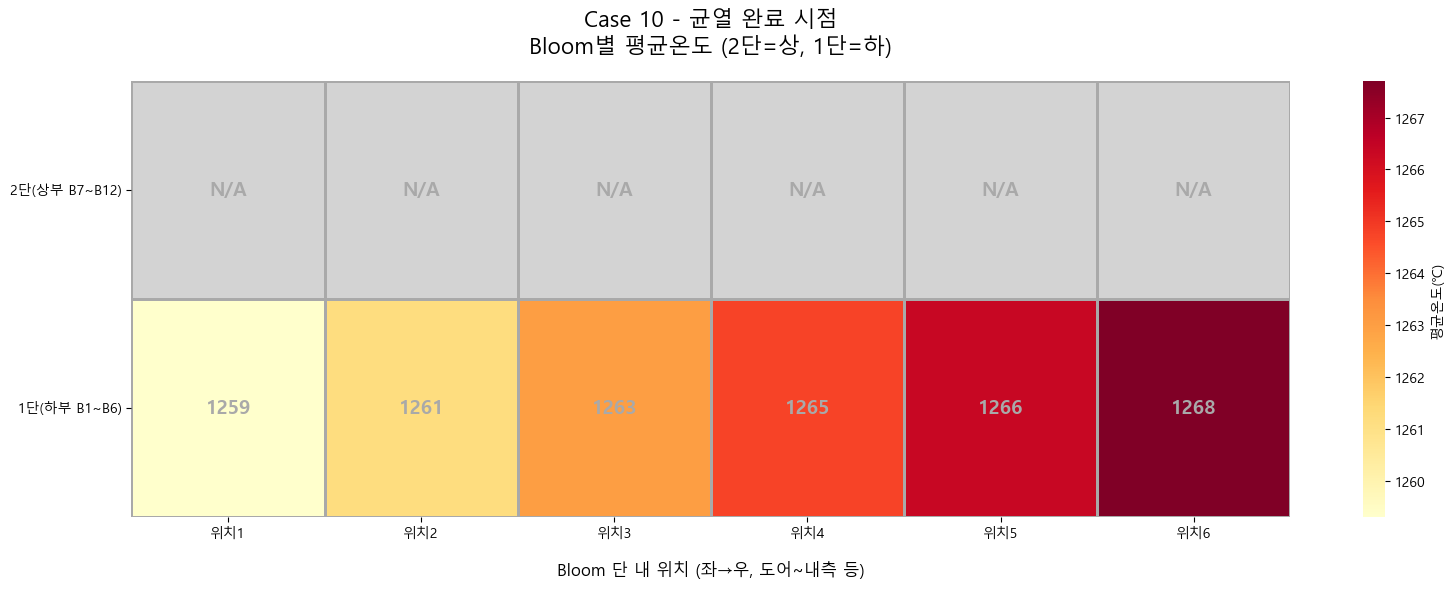

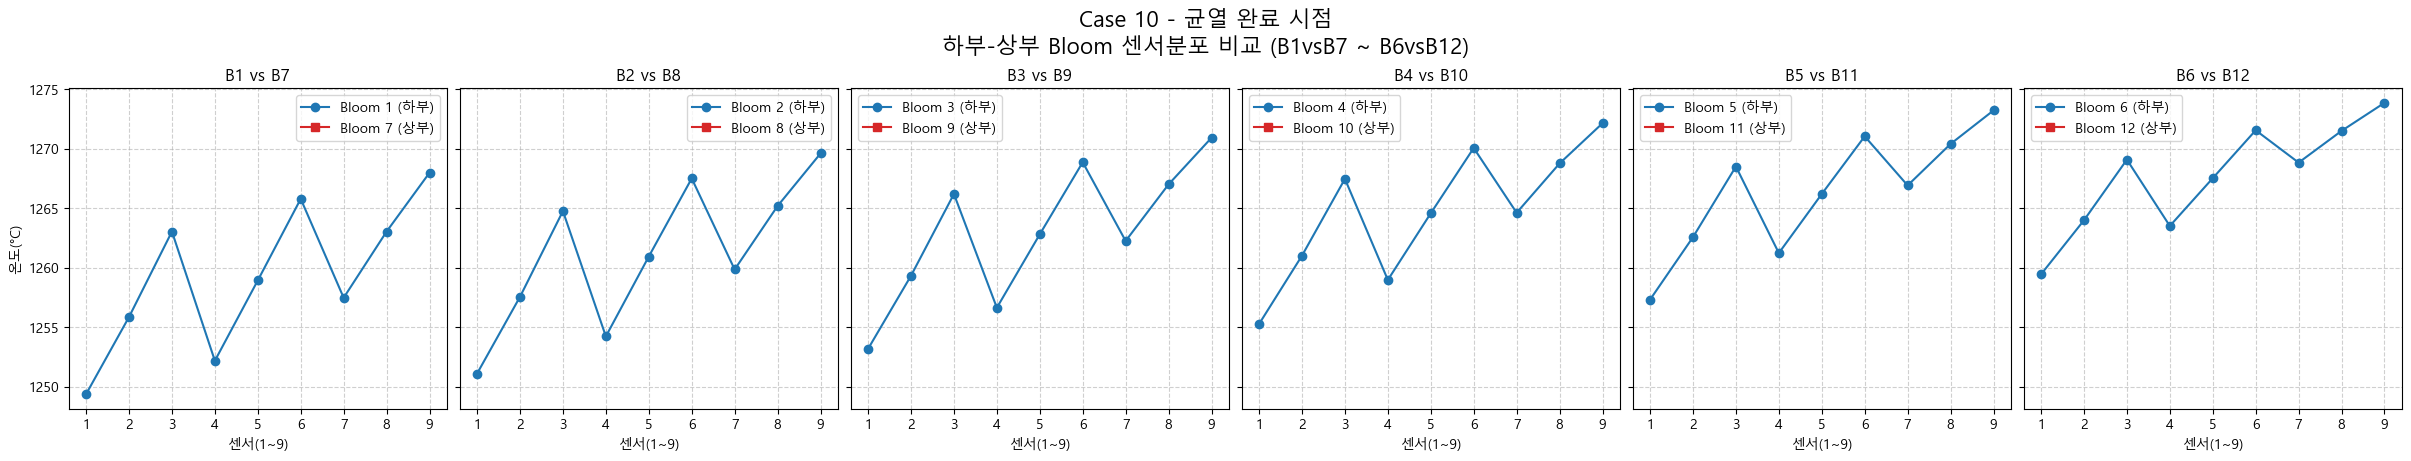

In [7]:
# ==============================================================================
# Step 0. [환경설정] - 한글 폰트/필수 패키지 임포트 (한글깨짐 방지)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Windows: Malgun Gothic, Mac: AppleGothic
try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    matplotlib.rc('font', family='AppleGothic')
matplotlib.rc('axes', unicode_minus=False)

# ==============================================================================
# Step 1. [분석 함수 정의] - 기존과 동일
# ==============================================================================
def find_header_row(file_path, sheet_name):
    """Excel 시트에서 'Time'이 포함된 헤더 행 번호를 찾습니다."""
    try:
        tmp = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl', header=None, nrows=10)
        for i, row in tmp.iterrows():
            if any('time' in str(cell).strip().lower() for cell in row):
                return i
    except Exception as e:
        print(f"'{sheet_name}' 시트에서 헤더를 찾는 중 오류 발생: {e}")
    return 0

def extract_bloom_sensor_table(file_path, sheet_name, time_point):
    """지정된 시간의 Bloom 센서 데이터를 추출하여 DataFrame으로 만듭니다."""
    try:
        header_row = find_header_row(file_path, sheet_name)
        df = pd.read_excel(file_path, sheet_name=sheet_name, engine='openpyxl', header=header_row)
        df = df.loc[:, df.columns.notnull()]
        df = df.loc[:, [str(c).strip() != "" for c in df.columns]]
        time_col = next((col for col in df.columns if 'time' in str(col).lower()), None)
        if not time_col: return None
        df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
        if df[time_col].isna().all(): return None
        time_data = df[np.isclose(df[time_col], time_point, atol=0.5)]
        if time_data.empty: return None
        rows = []
        for i in range(1, 13):
            for j in range(1, 10):
                col_name = f'Bloom {i} sensor {j}'
                if col_name in time_data.columns:
                    value = time_data.iloc[0][col_name]
                    rows.append({"Case": sheet_name, "Time": time_point, "Bloom": i, "Sensor": j, "Value": value})
        return pd.DataFrame(rows) if rows else None
    except Exception: return None

# ==============================================================================
# Step 2. [수정] 분석대상 및 '케이스별 조건(메타데이터)' 정의
# ==============================================================================
excel_file_path = "250716_가열로 시뮬레이션 results3_가공.xlsx"
case_sheets = [f"Case {i}" for i in range(1, 11)]
time_points = {
    "4hr 균열 시점": 47860.0,
    "균열 완료 시점": 57382.5,
}

# 케이스별 실험 조건 메타데이터 생성
case_meta_data = {
    "Case": [f"Case {i}" for i in range(1, 11)],
    "적치단수": ["2단", "2단", "1단", "2단", "2단", "2단", "2단", "1단", "2단", "2단"],
    "서포트높이": ["250mm", "250mm", "250mm", "250mm", "250mm", "470mm", "470mm", "470mm", "470mm", "470mm"],
    "작업방법": ["2단(2-1)", "2단(2-5hr-1)", "1단", "2단(2-1)", "2단(2-5hr-1)", "2단(2-1)", "2단(2-5hr-1)", "1단", "2단(2-1)", "2단(2-5hr-1)"],
    "제어": ["1Zone", "1Zone", "1Zone", "2Zone", "2Zone", "1Zone", "1Zone", "1Zone", "2Zone", "2Zone"]
}
case_meta_df = pd.DataFrame(case_meta_data)

# ==============================================================================
# Step 3. [수정] 데이터 적재 및 메타데이터 병합
# ==============================================================================
bloom_sensor_all = []
print("데이터 적재 시작...")
special_cases = ["Case 2", "Case 5", "Case 7", "Case 10"]
special_completion_time = 75382.5

for sheet in case_sheets:
    for time_desc, default_time_val in time_points.items():
        current_time_val = default_time_val
        if sheet in special_cases:
            if "4hr" in time_desc:
                continue
            elif "균열 완료" in time_desc:
                current_time_val = special_completion_time
        
        result = extract_bloom_sensor_table(excel_file_path, sheet, current_time_val)
        if result is not None:
            result["TimeDesc"] = time_desc
            bloom_sensor_all.append(result)
print("데이터 적재 완료.")

if not bloom_sensor_all:
    raise Exception("데이터 적재 결과가 없습니다.")
bloom_sensor_df = pd.concat(bloom_sensor_all, ignore_index=True)

# [중요] 온도 데이터와 케이스 메타데이터 병합
bloom_sensor_df = pd.merge(bloom_sensor_df, case_meta_df, on="Case")

# ==============================================================================
# Step 4. [수정] 요약 통계 생성 및 메타데이터 병합
# ==============================================================================
bloom_summary = (
    bloom_sensor_df
    .groupby(['Case', 'TimeDesc', 'Bloom', '서포트높이', '제어', '적치단수']) # 메타데이터도 그룹키에 포함
    .agg(
        평균=('Value', 'mean'),
        내부ΔT=('Value', lambda x: np.nanmax(x) - np.nanmin(x) if x.notna().any() else np.nan)
    )
    .reset_index()
)

# ==============================================================================
# Step 5, 6, 7. [수정] 모든 시각화 함수 정의
# ==============================================================================
def plot_bloom_2x6_heatmap(df, case, time_desc):
    mat = np.full((2, 6), np.nan)
    labels = np.empty((2, 6), dtype=object)
    for bloom_num in range(1, 13):
        row, col = (1, (bloom_num - 1) % 6) if bloom_num <= 6 else (0, (bloom_num - 1) % 6)
        subset = df[(df['Case'] == case) & (df['TimeDesc'] == time_desc) & (df['Bloom'] == bloom_num)]
        if not subset.empty and pd.notna(subset['평균'].values[0]):
            avg_temp = subset['평균'].values[0]
            mat[row, col] = avg_temp
            labels[row, col] = f'{avg_temp:.0f}'
        else:
            mat[row, col], labels[row, col] = np.nan, 'N/A'
    plt.figure(figsize=(16, 6))
    cmap = plt.get_cmap("YlOrRd").copy()
    cmap.set_bad(color='lightgray')
    ax = sns.heatmap(mat, fmt='', cmap=cmap, cbar_kws={"label": "평균온도(℃)"}, linewidths=1, linecolor='darkgray')
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c + 0.5, r + 0.5, labels[r, c], ha='center', va='center', fontsize=14, weight='bold', color='darkgray')
    plt.title(f"{case} - {time_desc}\nBloom별 평균온도 (2단=상, 1단=하)", fontsize=16, pad=20)
    plt.yticks([0.5, 1.5], ["2단(상부 B7~B12)", "1단(하부 B1~B6)"], rotation=0, va='center')
    plt.xticks(np.arange(6) + 0.5, [f"위치{i}" for i in range(1, 7)], rotation=0)
    plt.xlabel("Bloom 단 내 위치 (좌→우, 도어~내측 등)", fontsize=12, labelpad=15)
    plt.tight_layout()
    plt.show()

# def plot_all_bloom_sensors_2x6(df, case, time_desc):
#     fig, axs = plt.subplots(2, 6, figsize=(20, 6), sharey=True, constrained_layout=True)
#     fig.suptitle(f"{case} - {time_desc}\nBloom별 센서값 (2단=상, 1단=하)", fontsize=16)
#     for b in range(1, 13):
#         subset = df[(df['Case']==case) & (df['TimeDesc']==time_desc) & (df['Bloom']==b)].sort_values('Sensor')
#         row, col = (1, (b-1) % 6) if b <= 6 else (0, (b-1) % 6)
#         ax = axs[row, col]
#         if not subset.empty:
#             ax.plot(subset['Sensor'], subset['Value'], marker='o', linestyle='-')
#         ax.set_title(f"Bloom {b}", fontsize=11)
#         ax.set_xlabel("센서(1~9)")
#         ax.grid(True, linestyle='--', alpha=0.6)
#     for ax in axs[:, 0]:
#         ax.set_ylabel("온도(°C)")
#     axs[0,0].set_ylabel("온도(°C)\n2단(상부 B7~B12)")
#     axs[1,0].set_ylabel("온도(°C)\n1단(하부 B1~B6)")
#     plt.show()

def plot_bloom_pairs(df, case, time_desc):
    fig, axs = plt.subplots(1, 6, figsize=(24, 4.5), sharey=True, constrained_layout=True)
    fig.suptitle(f"{case} - {time_desc}\n하부-상부 Bloom 센서분포 비교 (B1vsB7 ~ B6vsB12)", fontsize=16)
    colors = ['tab:blue', 'tab:red']
    for i in range(1, 7):
        ax = axs[i-1]
        sub1 = df[(df['Case']==case) & (df['TimeDesc']==time_desc) & (df['Bloom']==i)].sort_values('Sensor')
        sub2 = df[(df['Case']==case) & (df['TimeDesc']==time_desc) & (df['Bloom']==i+6)].sort_values('Sensor')
        if not sub1.empty:
            ax.plot(sub1['Sensor'], sub1['Value'], marker='o', label=f"Bloom {i} (하부)", color=colors[0])
        if not sub2.empty:
            ax.plot(sub2['Sensor'], sub2['Value'], marker='s', label=f"Bloom {i+6} (상부)", color=colors[1])
        ax.set_title(f"B{i} vs B{i+6}", fontsize=12)
        ax.set_xlabel("센서(1~9)")
        ax.grid(True, linestyle='--', alpha=0.6)
        if ax.has_data():
            ax.legend()
    axs[0].set_ylabel("온도(°C)")
    plt.show()

# ==============================================================================
# Step 8. [신규] 인사이트 도출을 위한 비교 시각화 함수 정의
# ==============================================================================
def plot_comparison_charts(summary_df, time_description):
    """균열 완료 시점의 데이터를 사용하여 조건별 비교 차트를 그립니다."""
    df_2stack = summary_df[(summary_df['TimeDesc'] == time_description) & (summary_df['적치단수'] == '2단')]
    df_bottom = df_2stack[df_2stack['Bloom'] <= 6]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'[{time_description}] 서포트 높이별 하부(1단) Bloom 가열 특성 비교', fontsize=18, y=1.02)
    sns.boxplot(ax=axes[0], x='서포트높이', y='평균', data=df_bottom, hue='제어', palette='coolwarm', order=['250mm', '470mm'])
    axes[0].set_title('하부 Bloom 평균 온도 분포', fontsize=14)
    axes[0].set_ylabel('평균 온도 (℃)')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    sns.boxplot(ax=axes[1], x='서포트높이', y='내부ΔT', data=df_bottom, hue='제어', palette='coolwarm', order=['250mm', '470mm'])
    axes[1].set_title('하부 Bloom 내부 온도편차(ΔT) 분포', fontsize=14)
    axes[1].set_ylabel('내부 온도편차 (Max-Min, ℃)')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Case', y='평균', data=df_2stack, hue='제어', palette='viridis', dodge=False)
    plt.title(f'[{time_description}] 제어 방식별 Case별 평균 온도 분포', fontsize=16)
    plt.xlabel('Case')
    plt.ylabel('평균 온도 (℃)')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Step 9. [수정] 분석 실행 - 모든 시각화 호출
# ==============================================================================
print("\n" + "="*50 + "\n[인사이트 분석] 조건별 비교 시각화\n" + "="*50)
plot_comparison_charts(bloom_summary, "균열 완료 시점")


print("\n" + "="*50 + "\n[참고] 케이스별 상세 시각화\n" + "="*50)
# 모든 유효한 케이스에 대해 모든 상세 그래프 출력
for case_name in case_sheets:
    for time_description in time_points.keys():
        has_data = not bloom_summary[(bloom_summary['Case'] == case_name) & (bloom_summary['TimeDesc'] == time_description)].empty
        
        if has_data:
            print(f"\n--- [그래프 생성] {case_name}, {time_description} ---")
            plot_bloom_2x6_heatmap(bloom_summary, case_name, time_description)
            #plot_all_bloom_sensors_2x6(bloom_sensor_df, case_name, time_description)
            plot_bloom_pairs(bloom_sensor_df, case_name, time_description)
        else:
            pass



[Boxplot 데이터 확인]

--- [Boxplot 1 & 2 데이터] 서포트 높이별 하부 Bloom 가열 특성 비교 ---
        Case  서포트높이     제어  Bloom           평균   내부ΔT
12    Case 1  250mm  1Zone      1  1241.740000  36.01
13    Case 1  250mm  1Zone      2  1238.862222  41.84
14    Case 1  250mm  1Zone      3  1236.273333  56.78
15    Case 1  250mm  1Zone      4  1238.123333  56.75
16    Case 1  250mm  1Zone      5  1244.291111  41.84
17    Case 1  250mm  1Zone      6  1250.447778  37.40
24   Case 10  470mm  2Zone      1  1259.293333  18.63
25   Case 10  470mm  2Zone      2  1261.191111  18.52
26   Case 10  470mm  2Zone      3  1263.021111  17.76
27   Case 10  470mm  2Zone      4  1264.766667  16.89
28   Case 10  470mm  2Zone      5  1266.381111  15.92
29   Case 10  470mm  2Zone      6  1267.704444  14.43
36    Case 2  250mm  1Zone      1  1243.284444  36.65
37    Case 2  250mm  1Zone      2  1241.646667  41.51
38    Case 2  250mm  1Zone      3  1239.996667  56.31
39    Case 2  250mm  1Zone      4  1241.943333  55.86
40    Cas

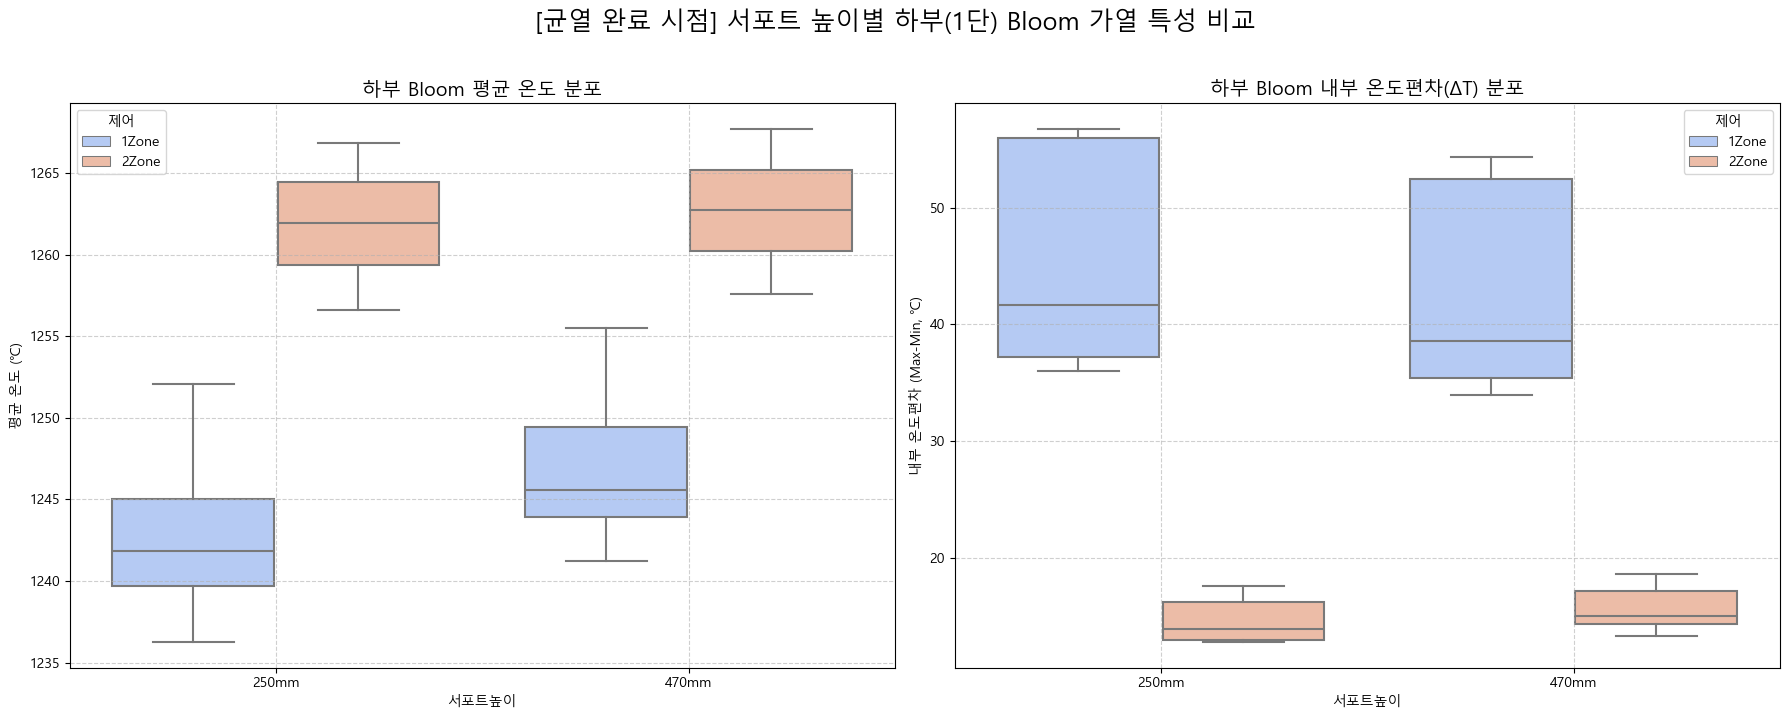

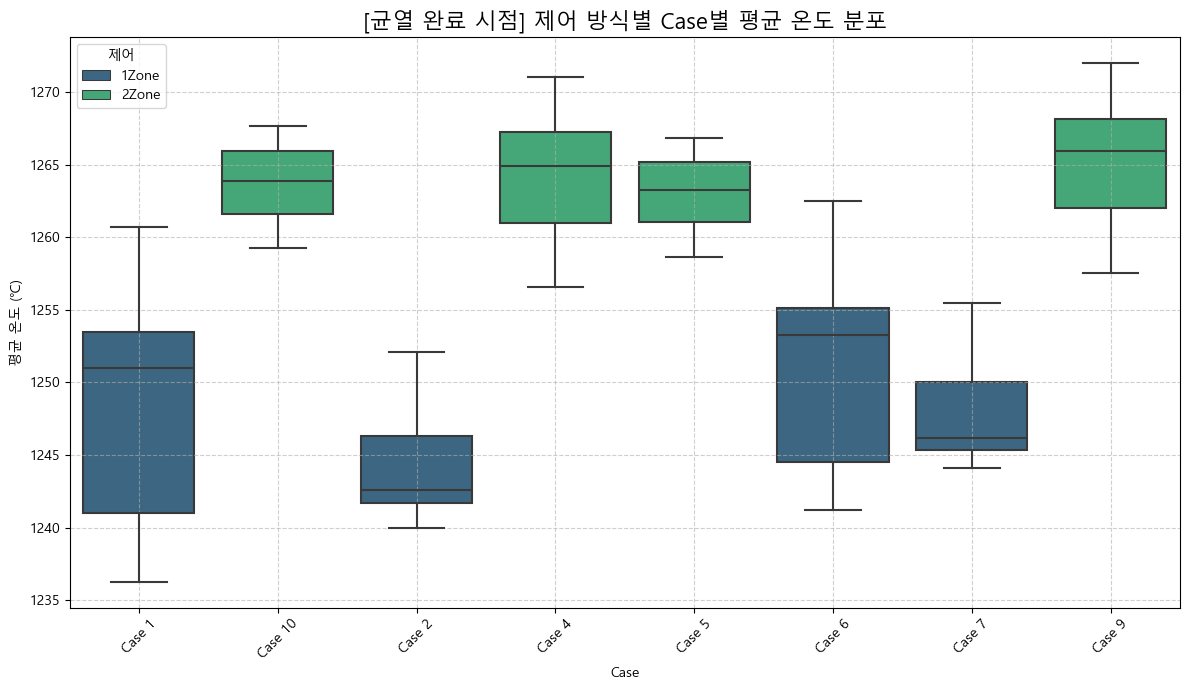

In [8]:
# ==============================================================================
# Step 9. [수정] 분석 실행 - 모든 시각화 호출
# ==============================================================================

# Boxplot에 사용된 데이터 확인을 위한 코드
print("\n" + "="*50 + "\n[Boxplot 데이터 확인]\n" + "="*50)

# 분석에 사용할 데이터 필터링
time_description_for_boxplot = "균열 완료 시점"
df_for_boxplot = bloom_summary[(bloom_summary['TimeDesc'] == time_description_for_boxplot) & (bloom_summary['적치단수'] == '2단')]
df_bottom_for_boxplot = df_for_boxplot[df_for_boxplot['Bloom'] <= 6]

print("\n--- [Boxplot 1 & 2 데이터] 서포트 높이별 하부 Bloom 가열 특성 비교 ---")
print(df_bottom_for_boxplot[['Case', '서포트높이', '제어', 'Bloom', '평균', '내부ΔT']])

print("\n--- [Boxplot 3 데이터] 제어 방식별 Case별 평균 온도 분포 ---")
print(df_for_boxplot[['Case', '서포트높이', '제어', 'Bloom', '평균', '내부ΔT']])


# 기존 분석 코드
print("\n" + "="*50 + "\n[인사이트 분석] 조건별 비교 시각화\n" + "="*50)
plot_comparison_charts(bloom_summary, "균열 완료 시점")

# 이하 생략...